## Preprocess

In [1]:
# Preprocessing for XOR Dataset - Pulse Detection and Metadata Extraction
import numpy as np, pandas as pd, h5py
from collections import Counter

# Paths
GROUND_TRUTH  = "/content/drive/MyDrive/InDomainData/DataGeneration/Data/InDomainXOR_balanced_400trials_100ms.hdf5"
SUBMISSION    = "/content/drive/MyDrive/InDomainData/DataGeneration/Data/InDomainXOR_SUB_balanced_400trials_100ms.hdf5"
VERBOSE       = True

# Timing parameters
TRIAL_LEN           = 100      # ms per trial
START_GUARD_MS      = 5        # earliest stim time
END_GUARD_MS        = 39       # buffer from end
STIM_LO             = int(START_GUARD_MS)
STIM_HI             = int(TRIAL_LEN - 1 - END_GUARD_MS)  # 60ms
RESP_WINDOW_LO      = 3        # ms after earliest input
RESP_WINDOW_HI      = 40       # ms after earliest input
STIM_EPS            = 1e-12    # threshold for detecting non-zero values

# Data schema
CANON_COLS = [
    "time",
    "A_stim", "B_stim",
    "A_spike_train", "A_membrane_potential",
    "B_spike_train", "B_membrane_potential",
    "C_spike_train", "C_membrane_potential",
    "D_spike_train", "D_membrane_potential",
    "E_spike_train", "E_membrane_potential",
]
SPIKE_COLS = ["A_spike_train","B_spike_train","C_spike_train","D_spike_train","E_spike_train"]
VM_COLS    = ["A_membrane_potential","B_membrane_potential","C_membrane_potential","D_membrane_potential","E_membrane_potential"]
INPUTS_MAP  = {"A":"A_stim","B":"B_stim"}
OUTPUTS_MAP = {"C":"C_spike_train","D":"D_spike_train","E":"E_spike_train"}
VM_MAP      = {"C":"C_membrane_potential","D":"D_membrane_potential","E":"E_membrane_potential"}

def _infer_fs_hz(time_col):
    """Infer sampling frequency from time column."""
    t = np.asarray(time_col).ravel()
    if t.size < 2:
        return 1000.0

    diffs = np.diff(t)
    dt = float(np.median(diffs))

    if dt <= 0:
        return 1000.0

    # Assume ms if dt in [0.2, 5.0], otherwise seconds
    fs = 1000.0 / dt if 0.2 <= dt <= 5.0 else 1.0 / dt
    if not (100.0 <= fs <= 20000.0):
        print(f"[warn] Unusual sampling rate: {fs:.2f} Hz")
    return float(fs)

def _read_trials_new(h5file):
    """Load trials from HDF5 file."""
    trials = []
    with h5py.File(h5file, "r") as f:
        keys = sorted([k for k in f.keys() if k.startswith("trial_")],
                     key=lambda x: int(x.split("_")[1]))
        if not keys:
            raise ValueError(f"No trial groups in {h5file}")

        for k in keys:
            data = f[k]["data"][()]
            df = pd.DataFrame(data)
            if df.shape[1] != len(CANON_COLS):
                raise ValueError(f"{h5file}:{k} expected {len(CANON_COLS)} columns, found {df.shape[1]}")
            if len(df) != TRIAL_LEN:
                raise ValueError(f"{h5file}:{k} expected {TRIAL_LEN} rows, found {len(df)}")
            df.columns = CANON_COLS
            trials.append(df)
    return trials

def _runs_from_mask(mask_bool):
    """Find contiguous True runs in boolean mask."""
    m = np.asarray(mask_bool, dtype=bool)
    if m.size == 0 or not m.any():
        return []
    diff = np.diff(m.astype(int))
    starts = np.where(np.r_[m[0], diff == 1])[0]
    ends   = np.where(np.r_[diff == -1, m[-1]])[0]
    return list(zip(starts, ends))

def _detect_pulse(vec, lo, hi, eps=STIM_EPS):
    """
    Detect stimulus pulse within window [lo, hi].
    Returns (start_index, extra_runs_count) or (None, 0).
    """
    v = np.asarray(vec)
    on = np.isfinite(v) & (np.abs(v) > eps)

    # Mask to window
    win = np.zeros_like(on, dtype=bool)
    lo = max(0, int(lo))
    hi = min(len(on)-1, int(hi))
    if lo <= hi:
        win[lo:hi+1] = on[lo:hi+1]

    runs = _runs_from_mask(win)
    if not runs:
        return None, 0

    # Choose longest run (earliest if tie)
    lengths = [(e - s + 1) for s, e in runs]
    best_i = int(np.argmax(lengths))
    s, e = runs[best_i]
    extra = max(0, len(runs) - 1)
    return int(s), extra

def _detect_anywhere(vec, eps=STIM_EPS):
    """Detect pulse anywhere in vector (for diagnostics)."""
    v = np.asarray(vec)
    on = np.isfinite(v) & (np.abs(v) > eps)
    runs = _runs_from_mask(on)
    if not runs:
        return None, 0

    lengths = [(e - s + 1) for s, e in runs]
    best_i = int(np.argmax(lengths))
    s, e = runs[best_i]
    return int(s), max(0, len(runs) - 1)

def _derive_meta(trials, fs_hz, label):
    """Extract metadata and detect stimulus patterns."""
    metas = []
    diag = dict(
        A_none_in_window=[], B_none_in_window=[],
        A_found_outside=[],  B_found_outside=[],
        A_multi_runs=0, B_multi_runs=0,
        A_min=[], A_max=[], B_min=[], B_max=[]
    )

    for tid, df in enumerate(trials):
        a = df["A_stim"].values
        b = df["B_stim"].values

        # Track value ranges for diagnostic
        diag["A_min"].append(np.nanmin(a))
        diag["A_max"].append(np.nanmax(a))
        diag["B_min"].append(np.nanmin(b))
        diag["B_max"].append(np.nanmax(b))

        # Detect pulses in guard window
        a_time, a_extra = _detect_pulse(a, STIM_LO, STIM_HI)
        b_time, b_extra = _detect_pulse(b, STIM_LO, STIM_HI)
        diag["A_multi_runs"] += a_extra
        diag["B_multi_runs"] += b_extra

        # Check for pulses outside window (diagnostic)
        if a_time is None:
            a_any, _ = _detect_anywhere(a)
            if a_any is None:
                diag["A_none_in_window"].append(tid)
            else:
                diag["A_found_outside"].append((tid, a_any))
        if b_time is None:
            b_any, _ = _detect_anywhere(b)
            if b_any is None:
                diag["B_none_in_window"].append(tid)
            else:
                diag["B_found_outside"].append((tid, b_any))

        # Determine pattern and response window
        a_bit = 1 if a_time is not None else 0
        b_bit = 1 if b_time is not None else 0
        pattern = f"{a_bit}{b_bit}"

        if a_time is not None or b_time is not None:
            anchor = min([t for t in (a_time, b_time) if t is not None])
            lo = max(0, int(anchor + RESP_WINDOW_LO))
            hi = min(TRIAL_LEN - 1, int(anchor + RESP_WINDOW_HI))
            resp = (lo, hi)
        else:
            resp = None

        metas.append(dict(
            trial_id=tid, fs_hz=float(fs_hz),
            pattern=pattern, a_time=a_time, b_time=b_time,
            response_window=resp
        ))

    # Print diagnostics
    if VERBOSE:
        print(f"[{label}] multi-runs: A={diag['A_multi_runs']}, B={diag['B_multi_runs']}")
        print(f"[{label}] Value ranges: A=[{np.nanmin(diag['A_min']):.3g}, {np.nanmax(diag['A_max']):.3g}], "
              f"B=[{np.nanmin(diag['B_min']):.3g}, {np.nanmax(diag['B_max']):.3g}]")

        if diag["A_found_outside"]:
            ex = ", ".join([f"{tid}@{idx}" for tid, idx in diag["A_found_outside"][:8]])
            print(f"[{label}] WARNING: A stim outside window [{STIM_LO},{STIM_HI}]: {len(diag['A_found_outside'])} trials (e.g., {ex})")
        if diag["B_found_outside"]:
            ex = ", ".join([f"{tid}@{idx}" for tid, idx in diag["B_found_outside"][:8]])
            print(f"[{label}] WARNING: B stim outside window [{STIM_LO},{STIM_HI}]: {len(diag['B_found_outside'])} trials (e.g., {ex})")

    return metas

def _concat_with_context(trials, metas):
    """Concatenate trials with metadata context."""
    frames = []
    for df, m in zip(trials, metas):
        g = df.copy()
        g["trial_id"]   = m["trial_id"]
        g["t_in_trial"] = np.arange(len(g), dtype=int)
        g["pattern"]    = m["pattern"]
        g["a_time"]     = -1 if m["a_time"] is None else m["a_time"]
        g["b_time"]     = -1 if m["b_time"] is None else m["b_time"]
        if m["response_window"] is None:
            g["resp_lo"] = -1
            g["resp_hi"] = -1
        else:
            g["resp_lo"], g["resp_hi"] = m["response_window"]
        frames.append(g)
    return pd.concat(frames, ignore_index=True)

def _pattern_counts(metas):
    """Count pattern occurrences."""
    pats = pd.Series([m["pattern"] for m in metas], dtype="string")
    return pats.value_counts().sort_index()

def _pattern_confusion(gt_meta, sb_meta):
    """Create confusion matrix of detected patterns."""
    pairs = Counter((gm["pattern"], sm["pattern"]) for gm, sm in zip(gt_meta, sb_meta))
    labels = sorted({p for p,_ in pairs} | {q for _,q in pairs})
    table = pd.DataFrame(0, index=labels, columns=labels)
    for (g,s), c in pairs.items():
        table.loc[g, s] = c
    table.index.name = "GT"
    table.columns.name = "SUB"
    return table

# Load and process data
if VERBOSE:
    print("Loading trials...")

gt_trials = _read_trials_new(GROUND_TRUTH)
sb_trials = _read_trials_new(SUBMISSION)

fs_hz = _infer_fs_hz(gt_trials[0]["time"].values)

# Extract metadata
gt_meta = _derive_meta(gt_trials, fs_hz, label="GT")
sb_meta = _derive_meta(sb_trials, fs_hz, label="SUB")

# Pattern analysis
gt_counts = _pattern_counts(gt_meta)
sb_counts = _pattern_counts(sb_meta)

print("\nPattern counts (GT):")
print(gt_counts.to_string())
print("\nPattern counts (SUB):")
print(sb_counts.to_string())

conf = _pattern_confusion(gt_meta, sb_meta)
print("\nPattern confusion (GT→SUB):\n", conf.to_string())

# Build concatenated dataframes
gt_concat = _concat_with_context(gt_trials, gt_meta)
sb_concat = _concat_with_context(sb_trials, sb_meta)

# Validation
assert len(gt_concat) == len(sb_concat), "GT and SUB lengths differ"
assert len(gt_trials) == len(sb_trials), "GT and SUB trial counts differ"

if VERBOSE:
    print(f"\nTotal trials: GT={len(gt_trials)}, SUB={len(sb_trials)}")
    print(f"Stim window: [{STIM_LO}, {STIM_HI}]")
    print(f"Response window: +[{RESP_WINDOW_LO}, {RESP_WINDOW_HI}] ms from anchor")

# Bundle results
METRIC_VARS_NEW = dict(
    inputs_map  = INPUTS_MAP,
    outputs_map = OUTPUTS_MAP,
    vm_map      = VM_MAP,
    spike_cols  = SPIKE_COLS,
    vm_cols     = VM_COLS,
    fs_hz       = fs_hz,
    stim_window = (STIM_LO, STIM_HI),
    behavior_params = dict(
        RESP_WINDOW_LO_MS=RESP_WINDOW_LO,
        RESP_WINDOW_HI_MS=RESP_WINDOW_HI,
        START_GUARD_MS=START_GUARD_MS,
        END_GUARD_MS=END_GUARD_MS,
        STIM_EPS=STIM_EPS
    ),
    gt = dict(trials=gt_trials, meta=gt_meta, concat=gt_concat, pattern_counts=gt_counts),
    sub= dict(trials=sb_trials, meta=sb_meta, concat=sb_concat, pattern_counts=sb_counts, pattern_confusion=conf),
)

print("\n[preprocessing] METRIC_VARS_NEW ready")

Loading trials...
[GT] multi-runs: A=0, B=0
[GT] Value ranges: A=[0, 1], B=[0, 1]
[SUB] multi-runs: A=0, B=0
[SUB] Value ranges: A=[0, 1], B=[0, 1]

Pattern counts (GT):
00    100
01    100
10    100
11    100

Pattern counts (SUB):
00    100
01    100
10    100
11    100

Pattern confusion (GT→SUB):
 SUB   00   01   10   11
GT                     
00   100    0    0    0
01     0  100    0    0
10     0    0  100    0
11     0    0    0  100

Total trials: GT=400, SUB=400
Stim window: [5, 60]
Response window: +[3, 40] ms from anchor

[preprocessing] METRIC_VARS_NEW ready


## Raster

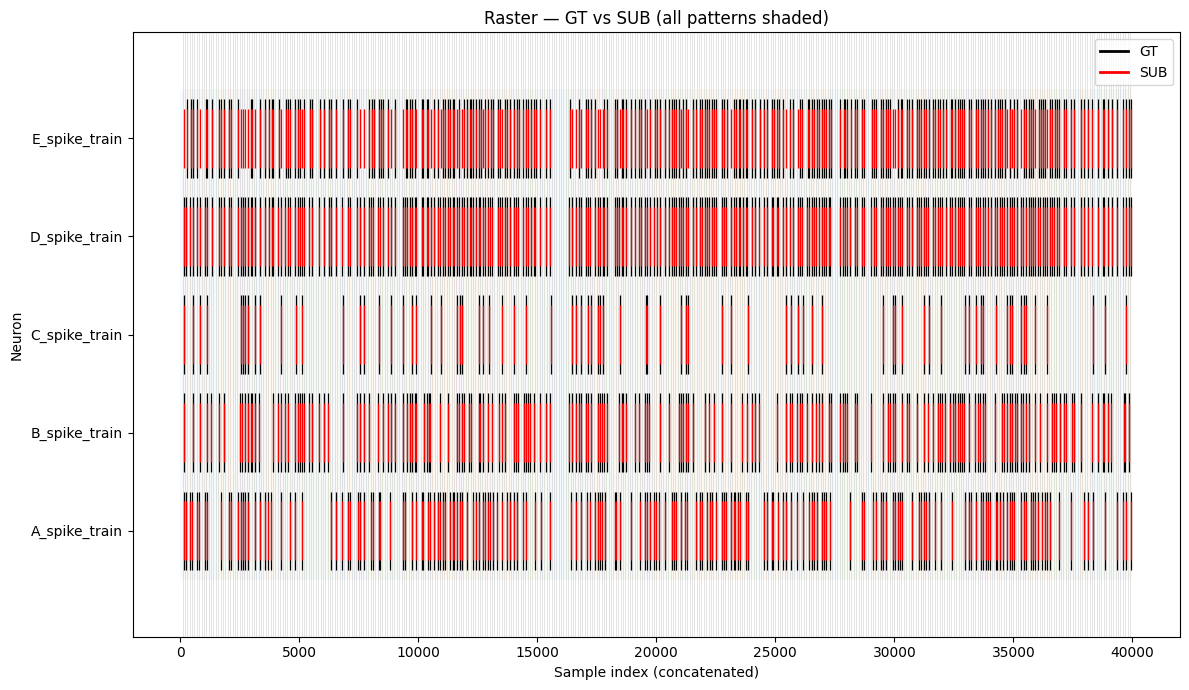

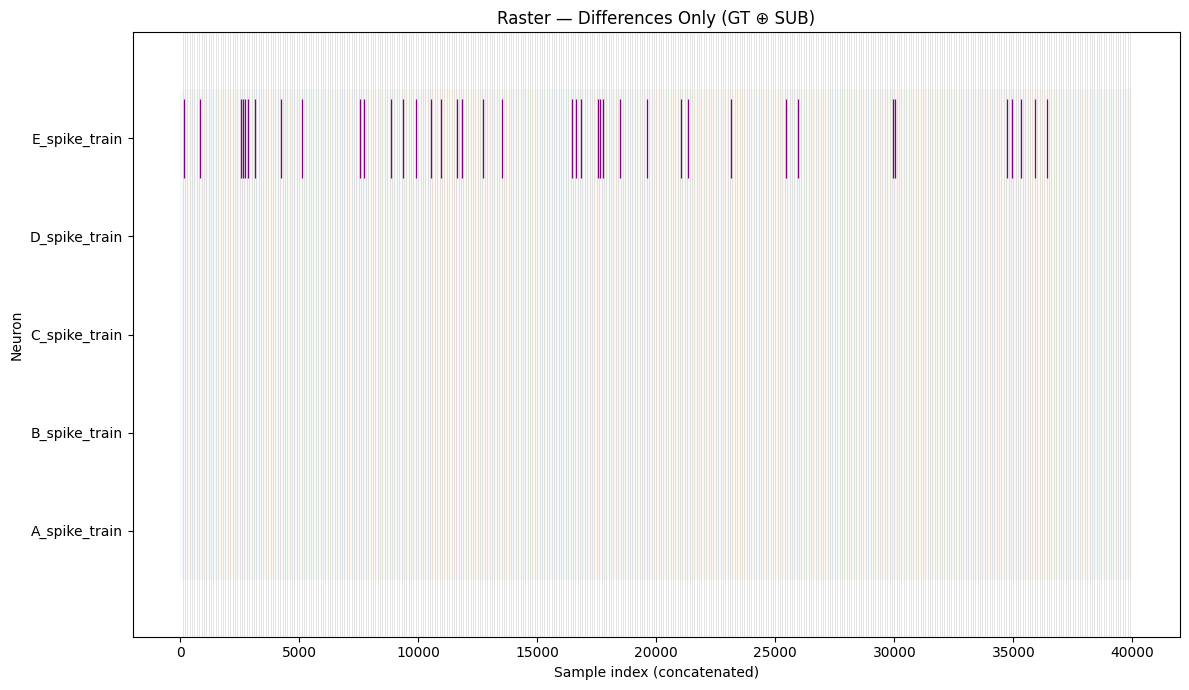


Jaccard similarity per neuron:
  A_spike_train      1.000
  B_spike_train      1.000
  C_spike_train      1.000
  D_spike_train      1.000
  E_spike_train      0.867
Mean Jaccard: 0.973

Difference counts (GT⊕SUB) per neuron:
  A_spike_train      0
  B_spike_train      0
  C_spike_train      0
  D_spike_train      0
  E_spike_train      40

Mean Jaccard by pattern:
  pattern 00: 1.000
  pattern 01: 1.000
  pattern 10: 1.000
  pattern 11: 0.920


In [2]:
# Raster Plot Visualization - Compare GT vs SUB spike patterns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

vars_new   = METRIC_VARS_NEW
gt         = vars_new["gt"]["concat"].copy()
sub        = vars_new["sub"]["concat"].copy()
spike_cols = vars_new["spike_cols"]
TRIAL_LEN  = 100

# Optional: filter by single pattern (e.g., "01") or None for all
FILTER_PATTERN = None

if FILTER_PATTERN is not None:
    gt = gt[gt["pattern"] == FILTER_PATTERN].reset_index(drop=True)
    sub = sub[sub["pattern"] == FILTER_PATTERN].reset_index(drop=True)

# Align lengths
n_rows = min(len(gt), len(sub))
gt = gt.iloc[:n_rows].reset_index(drop=True)
sub = sub.iloc[:n_rows].reset_index(drop=True)

# Extract spike times
gt_times = [np.where(gt[c].to_numpy(dtype=int) == 1)[0] for c in spike_cols]
sb_times = [np.where(sub[c].to_numpy(dtype=int) == 1)[0] for c in spike_cols]
diff_times = [np.setxor1d(g, s) for g, s in zip(gt_times, sb_times)]

def add_pattern_bands(ax, df, trial_len=100, alpha=0.10):
    """Add colored background bands to indicate input patterns."""
    colors = {"00":"#a6cee3", "01":"#b2df8a", "10":"#fdbf6f", "11":"#cab2d6"}
    last_tid = int(df["trial_id"].iloc[-1])
    for tid in range(last_tid + 1):
        block = df[df["trial_id"] == tid]
        if block.empty:
            continue
        start = int(block.index.min())
        pat = str(block["pattern"].iloc[0])
        rect = Rectangle((start, -0.5), trial_len, len(spike_cols),
                        color=colors.get(pat, "#dddddd"), alpha=alpha, lw=0)
        ax.add_patch(rect)

# Figure 1: Overlay raster (GT and SUB)
fig, ax = plt.subplots(figsize=(12, 7))

if FILTER_PATTERN is None:
    add_pattern_bands(ax, gt, trial_len=TRIAL_LEN, alpha=0.10)

ax.eventplot(gt_times, orientation="horizontal", linelengths=0.8, linewidths=0.9, colors="black")
ax.eventplot(sb_times, orientation="horizontal", linelengths=0.6, linewidths=0.9, colors="red")

ax.set_yticks(np.arange(len(spike_cols)))
ax.set_yticklabels(spike_cols)
ax.set_xlabel("Sample index (concatenated)")
ax.set_ylabel("Neuron")
ttl = "Raster — GT vs SUB" + (f" (pattern {FILTER_PATTERN})" if FILTER_PATTERN else " (all patterns shaded)")
ax.set_title(ttl)

# Legend
handles = [Line2D([0],[0], color="black", lw=2, label="GT"),
           Line2D([0],[0], color="red", lw=2, label="SUB")]
ax.legend(handles=handles, loc="upper right")

# Trial separators
total_trials = int(np.ceil(n_rows / TRIAL_LEN))
for k in range(1, total_trials):
    ax.axvline(k * TRIAL_LEN, color="0.85", lw=0.5, zorder=0)

plt.tight_layout()
plt.show()

# Figure 2: Differences-only raster
fig, ax = plt.subplots(figsize=(12, 7))

if FILTER_PATTERN is None:
    add_pattern_bands(ax, gt, trial_len=TRIAL_LEN, alpha=0.10)

ax.eventplot(diff_times, orientation="horizontal", linelengths=0.8, linewidths=0.9, colors="purple")
ax.set_yticks(np.arange(len(spike_cols)))
ax.set_yticklabels(spike_cols)
ax.set_xlabel("Sample index (concatenated)")
ax.set_ylabel("Neuron")
ax.set_title("Raster — Differences Only (GT ⊕ SUB)" + (f" (pattern {FILTER_PATTERN})" if FILTER_PATTERN else ""))

for k in range(1, total_trials):
    ax.axvline(k * TRIAL_LEN, color="0.85", lw=0.5, zorder=0)

plt.tight_layout()
plt.show()

# Numeric insights
def jaccard(a_idx, b_idx):
    """Compute Jaccard similarity between two spike index arrays."""
    if len(a_idx) == 0 and len(b_idx) == 0:
        return 1.0
    if len(a_idx) == 0 or len(b_idx) == 0:
        return 0.0
    inter = len(np.intersect1d(a_idx, b_idx))
    uni = len(np.union1d(a_idx, b_idx))
    return inter / uni if uni > 0 else 0.0

# Per-neuron Jaccard similarity
J = np.array([jaccard(g, s) for g, s in zip(gt_times, sb_times)], float)
mismatch_counts = {name: int(len(d)) for name, d in zip(spike_cols, diff_times)}
meanJ = float(np.nanmean(J)) if np.isfinite(J).any() else float("nan")

print("\nJaccard similarity per neuron:")
for name, val in zip(spike_cols, J):
    print(f"  {name:<18} {('%.3f'%val) if np.isfinite(val) else 'NA'}")
print(f"Mean Jaccard: {meanJ:.3f}" if np.isfinite(meanJ) else "Mean Jaccard: NA")

print("\nDifference counts (GT⊕SUB) per neuron:")
for k, v in mismatch_counts.items():
    print(f"  {k:<18} {v}")

# Per-pattern Jaccard (when showing all patterns)
if FILTER_PATTERN is None:
    pats = ["00","01","10","11"]
    per_pat = {}
    for p in pats:
        gtp = gt[gt["pattern"]==p]
        subp = sub[sub["pattern"]==p]
        n = min(len(gtp), len(subp))
        gtp = gtp.iloc[:n]
        subp = subp.iloc[:n]
        gts = [np.where(gtp[c].to_numpy(int)==1)[0] for c in spike_cols]
        sbs = [np.where(subp[c].to_numpy(int)==1)[0] for c in spike_cols]
        Jp = np.array([jaccard(a,b) for a,b in zip(gts,sbs)], float)
        per_pat[p] = float(np.nanmean(Jp))

    print("\nMean Jaccard by pattern:")
    for p in pats:
        print(f"  pattern {p}: {per_pat[p]:.3f}")

## PSTH

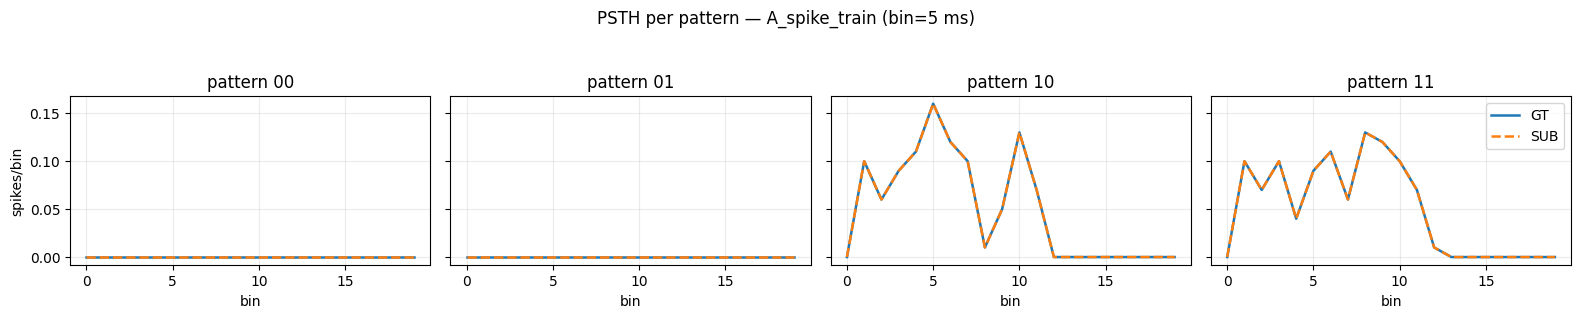

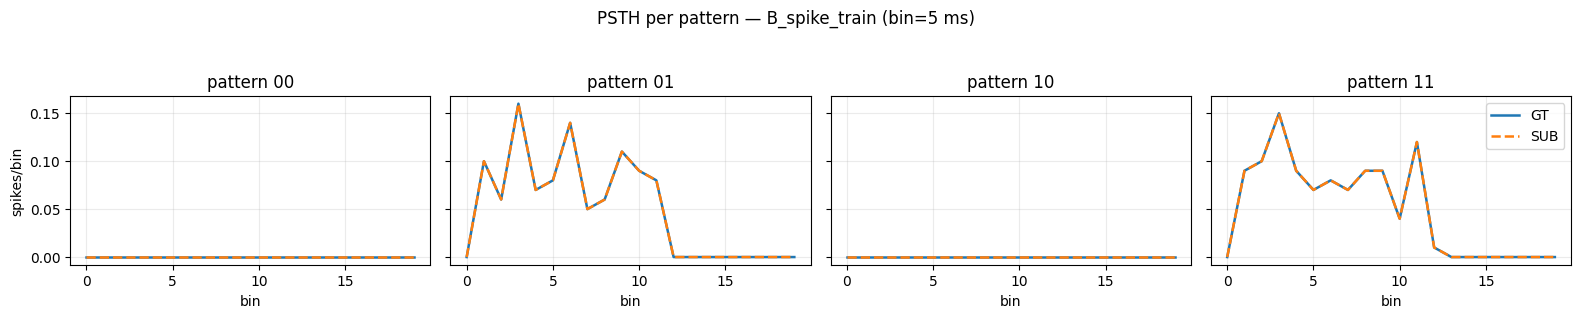

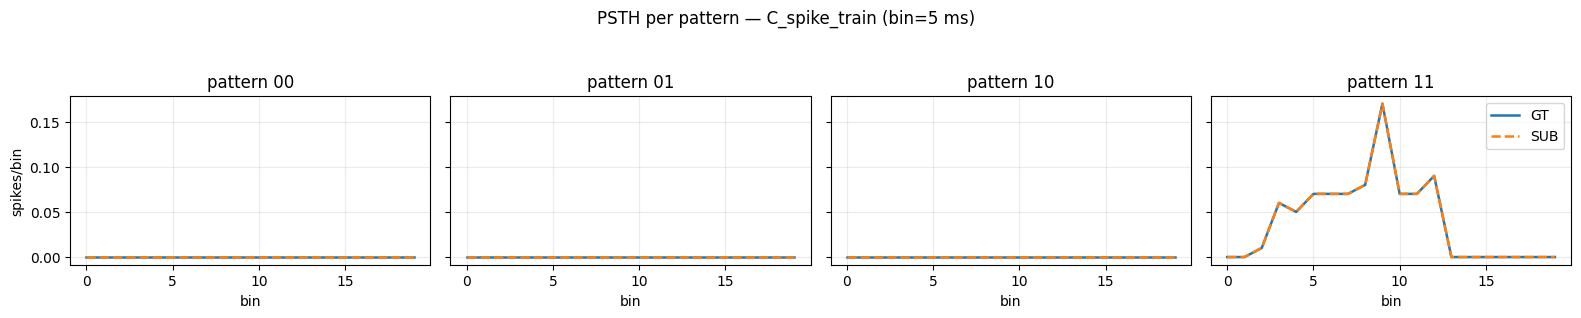

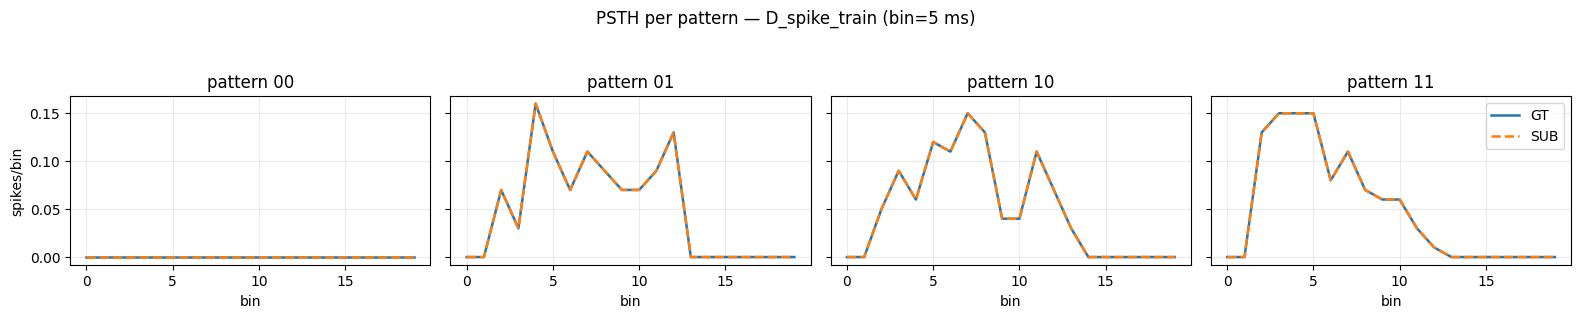

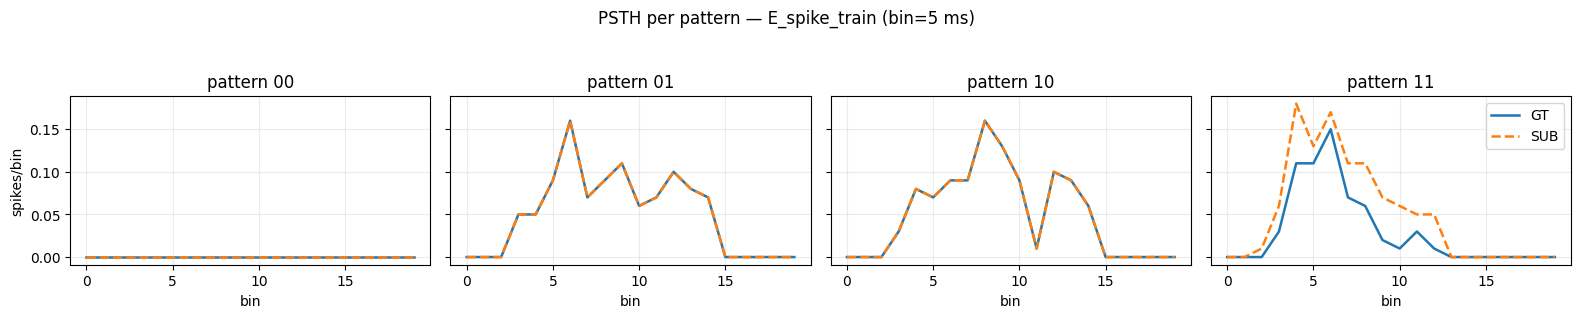

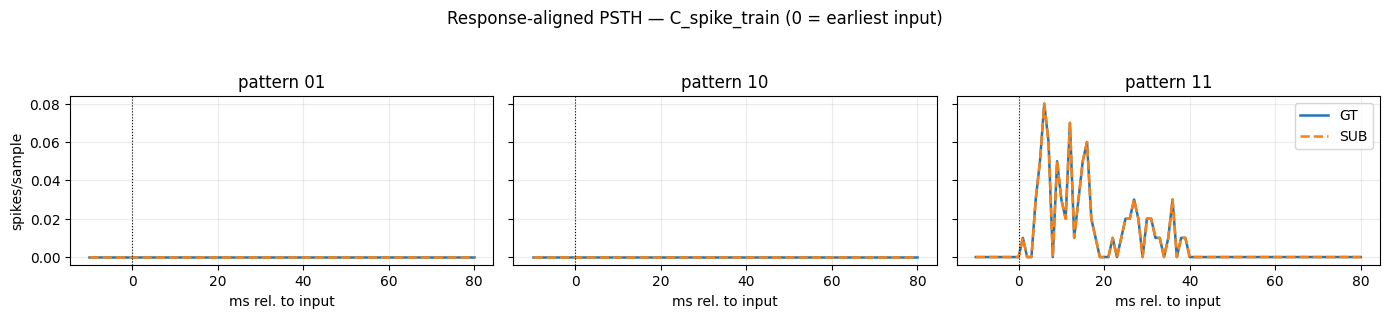

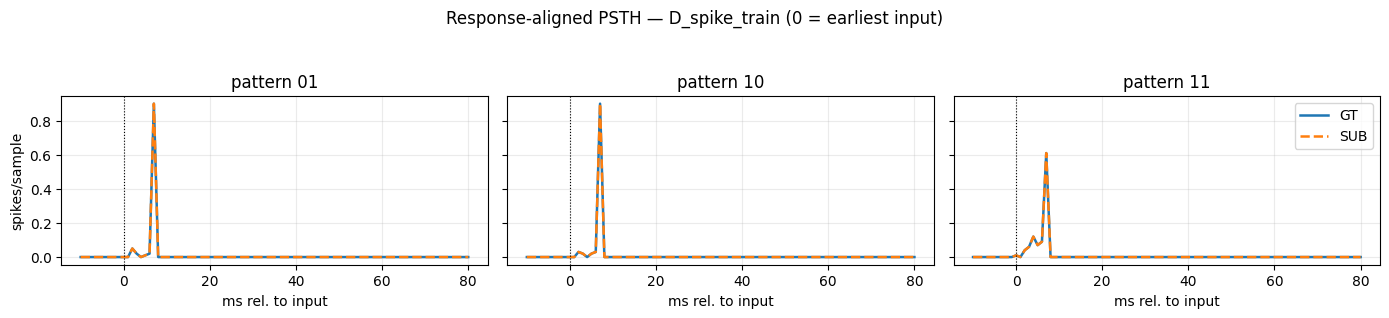

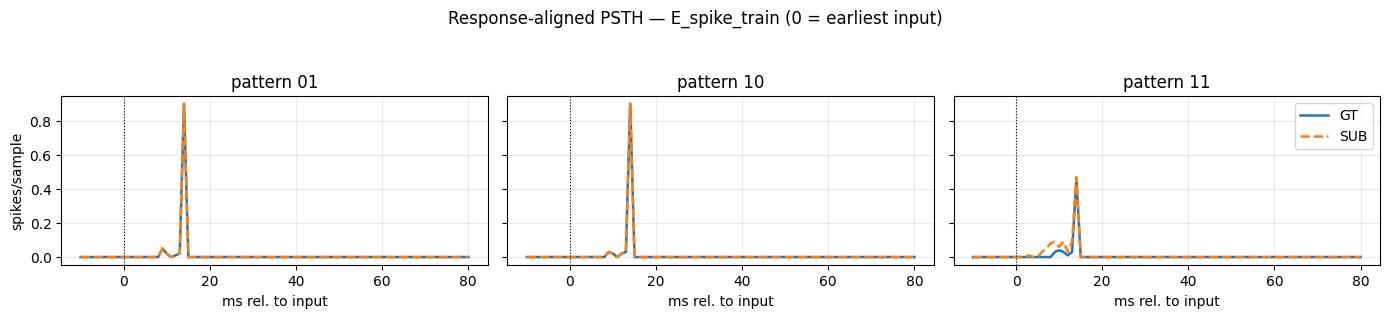


[PSTH metrics] (r, RMSE, bias) per neuron:
       Neuron  Overall_r  Overall_RMSE  Overall_bias(GT-SUB)  r_00  r_01  r_10   r_11  RMSE_00  RMSE_01  RMSE_10  RMSE_11  bias_00  bias_01  bias_10  bias_11
A_spike_train     1.0000        0.0000                 0.000   NaN   NaN   1.0 1.0000      0.0      0.0      0.0   0.0000      0.0      0.0      0.0     0.00
B_spike_train     1.0000        0.0000                 0.000   NaN   1.0   NaN 1.0000      0.0      0.0      0.0   0.0000      0.0      0.0      0.0     0.00
C_spike_train     1.0000        0.0000                 0.000   NaN   NaN   NaN 1.0000      0.0      0.0      0.0   0.0000      0.0      0.0      0.0     0.00
D_spike_train     1.0000        0.0000                 0.000   NaN   1.0   1.0 1.0000      0.0      0.0      0.0   0.0000      0.0      0.0      0.0     0.00
E_spike_train     0.9613        0.0149                -0.005   NaN   1.0   1.0 0.9467      0.0      0.0      0.0   0.0298      0.0      0.0      0.0    -0.02

=== PST

In [3]:
# PSTH Metric - Peristimulus Time Histogram Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

# Configuration
BIN_MS          = 5          # Bin size for PSTH
SMOOTH_FOR_PLOT = False      # Smooth for visualization only
SMOOTH_SIGMA    = 2.0        # Gaussian smoothing sigma (bins)

# Response-aligned window (ms relative to earliest input)
ALIGN_PRE_MS    = 10
ALIGN_POST_MS   = 80

# Thresholds for narrative
SMALL_RMSE      = 0.01
MODERATE_RMSE   = 0.03
HIGH_R_FLOOR    = 0.98
OK_R_FLOOR      = 0.90
LAT_MS_TOL      = 2.0

# Analysis settings
PATTERNS             = ("00", "01", "10", "11")
RESP_ALIGN_PATTERNS  = ("01", "10", "11")
FOCUS_NEURONS        = ("C_spike_train","D_spike_train","E_spike_train")
SHOW_RATE           = False                      # Show rate vs count in plots
RATE_SCALE          = 1000.0 / BIN_MS           # Convert to spikes/s
LATENCY_METHOD      = "com"                     # "com" or "peak"
COM_FRAC            = 0.30                      # Fraction of peak for COM

# Load preprocessed data
V           = METRIC_VARS_NEW
GT_trials   = V["gt"]["trials"]
SB_trials   = V["sub"]["trials"]
GT_meta     = V["gt"]["meta"]
SB_meta     = V["sub"]["meta"]
SPIKE_COLS  = V["spike_cols"]
fs_hz       = float(V["fs_hz"])
TRIAL_LEN   = 100

def _safe_pearson(a, b):
    """Compute Pearson correlation, handling edge cases."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.size != b.size or a.size == 0:
        return np.nan
    va = np.nanvar(a)
    vb = np.nanvar(b)
    if va <= 0 or vb <= 0:
        return np.nan
    am = np.nanmean(a)
    bm = np.nanmean(b)
    num = np.nansum((a - am) * (b - bm))
    den = sqrt(np.nansum((a - am)**2) * np.nansum((b - bm)**2))
    return float(num / den) if den > 0 else np.nan

def _rmse(a, b):
    """Compute RMSE between two arrays."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.size != b.size or a.size == 0:
        return np.nan
    d = a - b
    return float(np.sqrt(np.nanmean(d*d)))

def _gauss1d(sigma_bins, radius=3):
    """Create 1D Gaussian kernel for smoothing."""
    sig = float(max(1e-9, sigma_bins))
    rad = int(max(1, int(radius * sig)))
    x = np.arange(-rad, rad+1, 1.0)
    k = np.exp(-(x*x)/(2*sig*sig))
    k /= k.sum()
    return k

def _bin_counts(vec, bin_ms, fs):
    """Bin spike vector into counts."""
    x = np.asarray(vec, int)
    bin_size = int(max(1, round((bin_ms/1000.0) * fs)))
    nb = len(x) // bin_size
    if nb == 0:
        return np.zeros(0, float)
    xx = x[: nb*bin_size].reshape(nb, bin_size).sum(axis=1).astype(float)
    return xx

def _trial_ids_by_pattern(meta, pattern):
    """Get trial indices for a specific pattern."""
    return [i for i, m in enumerate(meta) if m["pattern"] == pattern]

def _psth_per_pattern(trials, patterns, col, bin_ms, fs, meta_ref, meta_other=None):
    """
    Compute trial-paired mean PSTH per pattern.
    If meta_other provided, intersect trial indices for paired comparison.
    """
    out = {}
    for p in patterns:
        idx_ref = _trial_ids_by_pattern(meta_ref, p)
        if meta_other is not None:
            idx_other = _trial_ids_by_pattern(meta_other, p)
            use = sorted(set(idx_ref).intersection(idx_other))
        else:
            use = idx_ref

        mats = []
        for i in use:
            if i >= len(trials):
                continue
            v = trials[i][col].to_numpy(int)
            mats.append(_bin_counts(v, bin_ms, fs))

        if mats:
            L = min(map(len, mats))
            mats = [m[:L] for m in mats]
            out[p] = np.nanmean(np.stack(mats, axis=0), axis=0)
        else:
            out[p] = None
    return out

def _resp_aligned(trials, meta, col, pre_ms, post_ms):
    """Create response-aligned PSTH relative to earliest input."""
    pre = int(pre_ms)
    post = int(post_ms)
    winL = pre + post + 1
    out = {}

    for p in RESP_ALIGN_PATTERNS:
        rows = []
        for i, m in enumerate(meta):
            if m["pattern"] != p:
                continue
            if m["a_time"] is None and m["b_time"] is None:
                continue

            anchor = min([t for t in (m["a_time"], m["b_time"]) if t is not None])
            s = max(0, anchor - pre)
            e = min(TRIAL_LEN - 1, anchor + post)
            vec = trials[i][col].to_numpy(int)
            w = vec[s:e+1].astype(float)

            # Pad to fixed length with NaNs
            pad_pre = (anchor - pre) - s
            pad_post = (anchor + post) - e
            w = np.r_[[np.nan]*pad_pre, w, [np.nan]*pad_post]
            if w.size < winL:
                w = np.r_[w, [np.nan]*(winL - w.size)]
            elif w.size > winL:
                w = w[:winL]
            rows.append(w)

        if rows:
            mean_curve = np.nanmean(np.stack(rows, axis=0), axis=0)
            t_axis = np.arange(-pre, post+1, 1)
            out[p] = (t_axis, mean_curve)
        else:
            out[p] = None
    return out

def _latency_peak(t, y):
    """Peak latency (argmax)."""
    if y is None or t is None:
        return None
    y = np.asarray(y, float)
    t = np.asarray(t, float)
    if not np.isfinite(y).any():
        return None
    i = int(np.nanargmax(y))
    return float(t[i])

def _latency_com(t, y, frac=0.30):
    """Center-of-mass latency above fraction of peak."""
    if y is None or t is None:
        return None
    y = np.asarray(y, float)
    t = np.asarray(t, float)
    y = np.where(np.isfinite(y), y, 0.0)
    if y.size == 0 or not np.isfinite(y).any():
        return None
    peak = float(np.nanmax(y))
    thr = frac * peak
    y2 = np.where(y >= thr, y, 0.0)
    s = y2.sum()
    if s <= 0:
        return None
    return float((t * y2).sum() / s)

def _latency(t, y, method="com", frac=0.30):
    """Compute latency using specified method."""
    if method == "com":
        val = _latency_com(t, y, frac=frac)
        return val if val is not None else _latency_peak(t, y)
    else:
        return _latency_peak(t, y)

# Compute PSTHs (trial-paired)
GT_psths = {c: _psth_per_pattern(GT_trials, PATTERNS, c, BIN_MS, fs_hz, GT_meta, SB_meta) for c in SPIKE_COLS}
SB_psths = {c: _psth_per_pattern(SB_trials, PATTERNS, c, BIN_MS, fs_hz, GT_meta, SB_meta) for c in SPIKE_COLS}

# Setup smoothing for plots
if SMOOTH_FOR_PLOT:
    K = _gauss1d(SMOOTH_SIGMA)
    _smooth = lambda y: y if y is None or len(y) == 0 else np.convolve(y, K, mode="same")
else:
    _smooth = lambda y: y

_scale_for_plot = (lambda y: None if y is None else y * RATE_SCALE) if SHOW_RATE else (lambda y: y)
_ylabel = "spikes/s" if SHOW_RATE else "spikes/bin"

# Plot per-pattern PSTHs
for col in SPIKE_COLS:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
    fig.suptitle(f"PSTH per pattern — {col} (bin={BIN_MS} ms)")
    for j, p in enumerate(PATTERNS):
        g = GT_psths[col][p]
        s = SB_psths[col][p]
        ax = axes[j]
        if g is not None:
            ax.plot(_scale_for_plot(_smooth(g)), label="GT", linewidth=1.8)
        if s is not None:
            ax.plot(_scale_for_plot(_smooth(s)), label="SUB", linewidth=1.8, linestyle="--")
        ax.set_title(f"pattern {p}")
        ax.set_xlabel("bin")
        if j == 0:
            ax.set_ylabel(_ylabel)
        ax.grid(alpha=0.25)
    axes[-1].legend(loc="upper right")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Plot response-aligned PSTHs
for col in FOCUS_NEURONS:
    GT_resp = _resp_aligned(GT_trials, GT_meta, col, ALIGN_PRE_MS, ALIGN_POST_MS)
    SB_resp = _resp_aligned(SB_trials, SB_meta, col, ALIGN_PRE_MS, ALIGN_POST_MS)
    fig, axes = plt.subplots(1, len(RESP_ALIGN_PATTERNS), figsize=(14, 3.2), sharey=True)
    fig.suptitle(f"Response-aligned PSTH — {col} (0 = earliest input)")

    for j, p in enumerate(RESP_ALIGN_PATTERNS):
        ax = axes[j]
        g = GT_resp[p]
        s = SB_resp[p]
        if g is not None:
            tg, yg = g
            ax.plot(tg, _scale_for_plot(_smooth(yg)), label="GT", linewidth=1.8)
        if s is not None:
            ts, ys = s
            ax.plot(ts, _scale_for_plot(_smooth(ys)), label="SUB", linewidth=1.8, linestyle="--")
        ax.set_title(f"pattern {p}")
        ax.set_xlabel("ms rel. to input")
        if j == 0:
            ax.set_ylabel(_ylabel.replace("/bin","/sample") if not SHOW_RATE else _ylabel)
        ax.axvline(0, color="k", lw=0.8, ls=":")
        ax.grid(alpha=0.25)
    axes[-1].legend(loc="upper right")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Compute numeric metrics
rows = []
perpat = {}
for col in SPIKE_COLS:
    # Overall metrics (concatenate all patterns)
    gt_vecs, sb_vecs = [], []
    for p in PATTERNS:
        g = GT_psths[col][p]
        s = SB_psths[col][p]
        if g is None or s is None:
            continue
        L = min(len(g), len(s))
        gt_vecs.append(g[:L])
        sb_vecs.append(s[:L])

    if gt_vecs and sb_vecs:
        G_all = np.concatenate(gt_vecs)
        S_all = np.concatenate(sb_vecs)
        r_all = _safe_pearson(G_all, S_all)
        rmse_all = _rmse(G_all, S_all)
        bias_all = float(np.nanmean(G_all - S_all))
    else:
        r_all = rmse_all = bias_all = np.nan

    # Per-pattern metrics
    pp = {}
    for p in PATTERNS:
        g = GT_psths[col][p]
        s = SB_psths[col][p]
        if (g is None) or (s is None) or (len(g)==0) or (len(s)==0):
            pp[p] = {"r": np.nan, "rmse": np.nan, "bias": np.nan}
        else:
            L = min(len(g), len(s))
            gg, ss = g[:L], s[:L]
            pp[p] = {
                "r": _safe_pearson(gg, ss),
                "rmse": _rmse(gg, ss),
                "bias": float(np.nanmean(gg - ss))
            }
    perpat[col] = pp

    rows.append({
        "Neuron": col,
        "Overall_r": r_all, "Overall_RMSE": rmse_all, "Overall_bias(GT-SUB)": bias_all,
        "r_00": pp["00"]["r"], "r_01": pp["01"]["r"], "r_10": pp["10"]["r"], "r_11": pp["11"]["r"],
        "RMSE_00": pp["00"]["rmse"], "RMSE_01": pp["01"]["rmse"],
        "RMSE_10": pp["10"]["rmse"], "RMSE_11": pp["11"]["rmse"],
        "bias_00": pp["00"]["bias"], "bias_01": pp["01"]["bias"],
        "bias_10": pp["10"]["bias"], "bias_11": pp["11"]["bias"],
    })

psth_metrics = pd.DataFrame(rows)
with pd.option_context("display.max_columns", None):
    print("\n[PSTH metrics] (r, RMSE, bias) per neuron:")
    print(psth_metrics.round(4).to_string(index=False))

# Compute latencies for aligned curves
latency = {}
for col in FOCUS_NEURONS:
    GTa = _resp_aligned(GT_trials, GT_meta, col, ALIGN_PRE_MS, ALIGN_POST_MS)
    SBa = _resp_aligned(SB_trials, SB_meta, col, ALIGN_PRE_MS, ALIGN_POST_MS)
    lat = {}
    for p in RESP_ALIGN_PATTERNS:
        g = GTa[p]
        s = SBa[p]
        if (g is None) or (s is None):
            lat[p] = np.nan
        else:
            tg, yg = g
            ts, ys = s
            lg = _latency(tg, yg, method=LATENCY_METHOD, frac=COM_FRAC)
            ls = _latency(ts, ys, method=LATENCY_METHOD, frac=COM_FRAC)
            lat[p] = np.nan if (lg is None or ls is None) else float(ls - lg)  # SUB - GT
    latency[col] = lat

# Generate narrative
def f3(x):
    """Format to 3 decimal places."""
    return "n/a" if not np.isfinite(x) else f"{x:.3f}"

def f3_signed(x):
    """Format with sign."""
    return "" if not np.isfinite(x) else f" ({x:+.3f})"

def bias_word(b):
    """Describe bias direction."""
    if not np.isfinite(b) or abs(b) < 1e-6:
        return "no bias"
    return "GT higher" if b > 0 else "SUB higher"

bullets = []

# Overall health per neuron
for _, row in psth_metrics.iterrows():
    n = row["Neuron"]
    r = row["Overall_r"]
    rm = row["Overall_RMSE"]
    b = row["Overall_bias(GT-SUB)"]
    grade = ("excellent" if (np.isfinite(r) and r >= HIGH_R_FLOOR)
             else "good" if (np.isfinite(r) and r >= OK_R_FLOOR)
             else "weak" if np.isfinite(r) else "n/a")
    bullets.append(
        f"{n}: shape {grade} (r={f3(r)}), "
        f"level mismatch RMSE={f3(rm)} spikes/bin, "
        f"bias={bias_word(b)}{f3_signed(b)}."
    )

# Worst pattern per neuron
for col in SPIKE_COLS:
    stats = perpat[col]
    rmse_vals = {p: (stats[p]['rmse'] if np.isfinite(stats[p]['rmse']) else -1) for p in PATTERNS}
    worst = max(rmse_vals, key=rmse_vals.get)
    wv = stats[worst]
    if np.isfinite(wv["rmse"]) and wv["rmse"] > SMALL_RMSE:
        bias_txt = f3_signed(wv['bias']).strip() or '0.000'
        bullets.append(
            f"{col}: largest difference in pattern {worst} "
            f"(r={f3(wv['r'])}, RMSE={f3(wv['rmse'])}, bias={bias_txt})."
        )

# Latency differences
for col in FOCUS_NEURONS:
    for p in RESP_ALIGN_PATTERNS:
        dlat = latency[col][p]
        if np.isfinite(dlat) and abs(dlat) > LAT_MS_TOL:
            direction = "SUB earlier" if dlat < 0 else "SUB later"
            bullets.append(f"{col}@{p}: {direction} by ~{dlat:.1f} ms (latency).")

# Summary
e11 = perpat["E_spike_train"]["11"]
if np.isfinite(e11["rmse"]) and e11["rmse"] > MODERATE_RMSE:
    bottom_line = (
        f"E (XOR) deviates on 11 (r={f3(e11['r'])}, RMSE={f3(e11['rmse'])}, "
        f"bias={f3_signed(e11['bias']).strip() or '0.000'}); "
        f"consider ↑C→E inhibition or ↓D→E drive to tighten suppression."
    )
else:
    bottom_line = "All neurons align closely; minor differences only."

print("\n=== PSTH Auto-Narrative ===")
for b in bullets:
    print("•", b)
print("—", bottom_line)

# Bundle results
PSTH_RESULTS = dict(
    bin_ms=BIN_MS,
    fs_hz=fs_hz,
    patterns=PATTERNS,
    gt_psths=GT_psths,
    sub_psths=SB_psths,
    metrics=psth_metrics,
    latency=latency,
    config=dict(
        SMOOTH_FOR_PLOT=SMOOTH_FOR_PLOT, SMOOTH_SIGMA=SMOOTH_SIGMA,
        SHOW_RATE=SHOW_RATE, LATENCY_METHOD=LATENCY_METHOD, COM_FRAC=COM_FRAC
    )
)
AUTO_PSTH_REPORT = dict(
    psth_summary=psth_metrics,
    per_pattern=perpat,
    latency=latency,
    bullets=bullets,
    bottom_line=bottom_line,
    config=dict(BIN_MS=BIN_MS, ALIGN_PRE_MS=ALIGN_PRE_MS, ALIGN_POST_MS=ALIGN_POST_MS)
)
print("[PSTH] Results bundled: PSTH_RESULTS, AUTO_PSTH_REPORT")

## KS

In [4]:
# KS Metric - Kolmogorov-Smirnov Test for Spike Time Distributions
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, wasserstein_distance

# Load preprocessed data
V            = METRIC_VARS_NEW
GT_trials    = V["gt"]["trials"]
SB_trials    = V["sub"]["trials"]
GT_meta      = V["gt"]["meta"]
SB_meta      = V["sub"]["meta"]
SPIKE_COLS   = V["spike_cols"]
TRIAL_LEN    = 100
RESP_LO_MS   = int(V["behavior_params"]["RESP_WINDOW_LO_MS"])
RESP_HI_MS   = int(V["behavior_params"]["RESP_WINDOW_HI_MS"])

# Configuration
KS_WINDOW_MODE       = "full"           # Options: "aligned", "full", "guarded_full"
RESP_ALIGN_PATTERNS  = ("01","10","11")
ALL_PATTERNS         = ("00","01","10","11")
INCLUDE_00_IN_OVERALL= False            # For aligned mode only
USE_WASSERSTEIN      = True

# Guard bounds for guarded_full mode
FULL_GUARD_LO = 5
FULL_GUARD_HI = 95

# Statistical thresholds
ALPHA             = 0.05
KS_TOL            = 0.05
COUNT_ABS_TOL     = 5
COUNT_FRAC_TOL    = 0.10
MIN_POOLED_SPIKES = 40

def _trial_anchor(meta_row):
    """Get earliest stimulus time in trial."""
    a = meta_row["a_time"]
    b = meta_row["b_time"]
    if (a is None) and (b is None):
        return None
    return min([t for t in (a, b) if t is not None])

def _response_window(meta_row):
    """Get response window from metadata."""
    return meta_row["response_window"]

def _safe_wasserstein(gt_times, sb_times):
    """Compute Wasserstein distance, handling empty distributions."""
    if USE_WASSERSTEIN and gt_times.size > 0 and sb_times.size > 0:
        return float(wasserstein_distance(gt_times, sb_times))
    return np.nan

def _window_bounds_for_mode(meta_row):
    """
    Get analysis window based on mode.
    Returns: (lo, hi, align_to_anchor, where_lo, where_hi)
    """
    if KS_WINDOW_MODE == "aligned":
        rw = _response_window(meta_row)
        if rw is None:
            return None, None, True, None, None
        lo, hi = rw
        return lo, hi, True, RESP_LO_MS, RESP_HI_MS
    elif KS_WINDOW_MODE == "guarded_full":
        return FULL_GUARD_LO, FULL_GUARD_HI, False, FULL_GUARD_LO, FULL_GUARD_HI
    elif KS_WINDOW_MODE == "full":
        return 0, TRIAL_LEN - 1, False, 0, TRIAL_LEN - 1
    else:
        raise ValueError(f"Unknown KS_WINDOW_MODE: {KS_WINDOW_MODE}")

def _pool_times(trials, meta, col, patterns):
    """
    Pool spike times across trials for specified patterns.
    Returns: (times, where_lo, where_hi)
    """
    pooled = []
    where_lo, where_hi = None, None

    for i, m in enumerate(meta):
        if m["pattern"] not in patterns:
            continue

        lo, hi, align_to_anchor, wlo, whi = _window_bounds_for_mode(m)
        if lo is None or hi is None or hi < lo:
            continue
        if where_lo is None:
            where_lo, where_hi = wlo, whi

        vec = trials[i][col].to_numpy(int)
        idx_rel = np.where(vec[lo:hi+1] == 1)[0]
        if idx_rel.size == 0:
            continue
        abs_idx = idx_rel + lo

        if align_to_anchor:
            anc = _trial_anchor(m)
            if anc is None:
                aligned = abs_idx.astype(float)
            else:
                aligned = abs_idx.astype(float) - float(anc)
        else:
            aligned = abs_idx.astype(float)

        pooled.append(aligned)

    if not pooled:
        return np.array([], dtype=float), where_lo, where_hi
    return np.concatenate(pooled).astype(float), where_lo, where_hi

def _ecdf_at_max_gap(x, y):
    """Find point of maximum ECDF divergence."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    if x.size == 0 and y.size == 0:
        return 0.0, 0.0
    if x.size == 0 or y.size == 0:
        base = x if y.size == 0 else y
        t_star = float(np.median(base))
        sign = 1.0 if y.size > x.size else -1.0
        return t_star, float(sign)

    xs = np.sort(x)
    ys = np.sort(y)
    grid = np.unique(np.r_[xs, ys])
    Fx = np.searchsorted(xs, grid, side="right") / xs.size
    Fy = np.searchsorted(ys, grid, side="right") / ys.size
    diff = Fy - Fx
    i = int(np.argmax(np.abs(diff)))
    return float(grid[i]), float(diff[i])

def _where_from_percentile(t_star, lo, hi):
    """Classify time point as early/mid/late in window."""
    if lo is None or hi is None or hi <= lo:
        return "n/a"
    frac = (t_star - lo) / (hi - lo)
    if frac < 1/3: return "early"
    if frac < 2/3: return "mid"
    return "late"

def _count_issue(gt, sub):
    """Check if spike counts differ significantly."""
    gt = float(gt)
    sub = float(sub)
    delta = sub - gt
    tol = max(COUNT_ABS_TOL, COUNT_FRAC_TOL * max(1.0, gt))
    return abs(delta) >= tol, delta, tol

def _timing_issue(ks_stat, p, gt_spk, sub_spk):
    """Check if timing distributions differ significantly."""
    if (gt_spk < MIN_POOLED_SPIKES) or (sub_spk < MIN_POOLED_SPIKES):
        return False, "low-power"
    if not np.isfinite(ks_stat) or not np.isfinite(p):
        return False, "n/a"
    if (ks_stat >= KS_TOL) and (p < ALPHA):
        return True, "shift"
    return False, "match"

def _dir_word(where_txt, sign_val):
    """Describe direction of timing difference."""
    base = ("no directional skew" if abs(float(sign_val)) < 1e-12
            else "SUB earlier vs GT" if float(sign_val) > 0
            else "SUB later vs GT")
    wt = where_txt if isinstance(where_txt, str) else "n/a"
    return f"{base} (peak divergence {wt})"

# Compute overall KS statistics (per neuron)
overall_rows = []
if KS_WINDOW_MODE == "aligned":
    overall_patterns = RESP_ALIGN_PATTERNS if not INCLUDE_00_IN_OVERALL else ALL_PATTERNS
else:
    overall_patterns = ALL_PATTERNS

for col in SPIKE_COLS:
    gt_times, wlo, whi = _pool_times(GT_trials, GT_meta, col, overall_patterns)
    sb_times, _, _ = _pool_times(SB_trials, SB_meta, col, overall_patterns)

    GT_spikes = int(gt_times.size)
    SUB_spikes = int(sb_times.size)
    rate_ratio = float(SUB_spikes / GT_spikes) if GT_spikes > 0 else (np.inf if SUB_spikes > 0 else 1.0)

    if GT_spikes == 0 and SUB_spikes == 0:
        ks_stat, p_val = 0.0, 1.0
        t_star, sign_val = 0.0, 0.0
        wdist = 0.0
    else:
        if GT_spikes == 0 or SUB_spikes == 0:
            ks_stat, p_val = 1.0, 0.0
        else:
            ks = ks_2samp(gt_times, sb_times, alternative="two-sided", mode="auto")
            ks_stat, p_val = float(ks.statistic), float(ks.pvalue)
        t_star, sign_val = _ecdf_at_max_gap(gt_times, sb_times)
        wdist = _safe_wasserstein(gt_times, sb_times)

    where = _where_from_percentile(t_star, wlo, whi)
    effect = ("tiny" if ks_stat < 0.05 else
              "small" if ks_stat < 0.1 else
              "medium" if ks_stat < 0.2 else "large")

    overall_rows.append(dict(
        Neuron_spike=col,
        KS_statistic=ks_stat,
        p_value=p_val,
        effect=effect,
        GT_spikes=GT_spikes,
        SUB_spikes=SUB_spikes,
        rate_ratio_SUB_over_GT=rate_ratio,
        wasserstein=wdist,
        t_at_max_abs_dECDF=t_star,
        where=where,
        sign_SUB_minus_GT=sign_val
    ))

ks_df = pd.DataFrame(overall_rows)

# Display overall results
with pd.option_context("display.max_columns", None):
    label = {
        "aligned": "aligned, pooled across 01/10/11",
        "full": "FULL 0–99 ms (all patterns pooled)",
        "guarded_full": f"GUARDED {FULL_GUARD_LO}–{FULL_GUARD_HI} ms (all patterns pooled)"
    }[KS_WINDOW_MODE]
    print(f"\n[KS — {label}] GT vs SUB")
    print(ks_df.round(6).to_string(index=False))

# Compute per-pattern KS statistics
pp_rows = []
for col in SPIKE_COLS:
    for p in ALL_PATTERNS:
        gt_times, wlo, whi = _pool_times(GT_trials, GT_meta, col, (p,))
        sb_times, _, _ = _pool_times(SB_trials, SB_meta, col, (p,))

        GT_spikes = int(gt_times.size)
        SUB_spikes = int(sb_times.size)

        if GT_spikes == 0 and SUB_spikes == 0:
            ks_stat, p_val = 0.0, 1.0
            t_star, sign_val = 0.0, 0.0
            wdist = 0.0
        else:
            if GT_spikes == 0 or SUB_spikes == 0:
                ks_stat, p_val = 1.0, 0.0
            else:
                ks = ks_2samp(gt_times, sb_times, alternative="two-sided", mode="auto")
                ks_stat, p_val = float(ks.statistic), float(ks.pvalue)
            t_star, sign_val = _ecdf_at_max_gap(gt_times, sb_times)
            wdist = _safe_wasserstein(gt_times, sb_times)

        where = _where_from_percentile(t_star, wlo, whi)
        pp_rows.append(dict(
            Neuron_spike=col,
            pattern=p,
            KS_statistic=ks_stat,
            p_value=p_val,
            GT_spikes=GT_spikes,
            SUB_spikes=SUB_spikes,
            wasserstein=wdist,
            t_at_max_abs_dECDF=t_star,
            where=where,
            sign_SUB_minus_GT=sign_val
        ))

ks_pp_df = pd.DataFrame(pp_rows)

# Generate narrative for issues
def _severity_row(r):
    """Calculate severity score for prioritization."""
    ks = float(r["KS_statistic"])
    pv = float(r["p_value"])
    gt = float(r["GT_spikes"])
    sub = float(r["SUB_spikes"])
    t_sev = ks if (ks >= KS_TOL and pv < ALPHA and gt >= MIN_POOLED_SPIKES and sub >= MIN_POOLED_SPIKES) else 0.0
    ok, delta, tol = _count_issue(gt, sub)
    c_sev = abs(delta) / max(1e-9, tol) if ok else 0.0
    return max(t_sev, c_sev)

overall_bullets = []
for _, row in ks_df.iterrows():
    n = row["Neuron_spike"]
    ks = float(row["KS_statistic"])
    pv = float(row["p_value"])
    gt = float(row["GT_spikes"])
    sub = float(row["SUB_spikes"])
    rr = float(row["rate_ratio_SUB_over_GT"])
    where = row["where"]
    sgn = float(row["sign_SUB_minus_GT"])
    wdist = float(row["wasserstein"]) if (USE_WASSERSTEIN and not pd.isna(row["wasserstein"])) else np.nan

    timing_bad, timing_flag = _timing_issue(ks, pv, gt, sub)
    count_bad, delta, tol = _count_issue(gt, sub)

    if not timing_bad and not count_bad:
        continue

    parts = [f"{n}:"]
    if timing_bad:
        if USE_WASSERSTEIN and np.isfinite(wdist):
            parts.append(f"timing shift (KS={ks:.3f}, p={pv:.3g}, W={wdist:.3f}, {_dir_word(where, sgn)})")
        else:
            parts.append(f"timing shift (KS={ks:.3f}, p={pv:.3g}, {_dir_word(where, sgn)})")
    if count_bad:
        parts.append(f"count {'surplus' if delta>0 else 'deficit'} Δ={delta:.0f} "
                    f"(SUB {sub:.0f} vs GT {gt:.0f}, tol≈±{tol:.0f}, rate≈{rr:.3f})")

    # Add hints for correction
    hint = None
    if "E_spike_train" in n:
        if count_bad and delta > 0:
            hint = "tighten E suppression (↑inhibition or ↓excitatory gain)"
        elif timing_bad:
            hint = "adjust upstream latencies"
    elif "C_spike_train" in n or "D_spike_train" in n:
        if count_bad:
            hint = "re-tune drive levels"
        elif timing_bad:
            hint = "adjust synaptic delays"
    else:
        if count_bad:
            hint = "match tonic level"
        elif timing_bad:
            hint = "align onset latency"

    if hint:
        parts.append(hint)
    overall_bullets.append(" • " + " ; ".join(parts))

if overall_bullets:
    print("\n=== KS Auto-Notes (issues only) ===")
    for b in overall_bullets:
        print(b)
else:
    print("\n=== KS Auto-Notes ===")
    print("All neurons align within tolerances; no issues detected.")

# Flag problematic patterns
ks_pp_df["severity"] = ks_pp_df.apply(_severity_row, axis=1)
pp_bad = ks_pp_df[ks_pp_df["severity"] > 0].copy()

if pp_bad.empty:
    print("\n[KS per-pattern] No patterns flagged")
else:
    idx = pp_bad.groupby("Neuron_spike")["severity"].idxmax()
    worst = pp_bad.loc[idx, ["Neuron_spike","pattern","KS_statistic","p_value",
                             "GT_spikes","SUB_spikes","wasserstein","severity"]]
    worst = worst.sort_values(["severity","Neuron_spike"], ascending=[False, True])
    print("\n[KS per-pattern] Highest severity issues:")
    with pd.option_context("display.max_columns", None):
        print(worst.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

# Bundle results
KS_RESULTS = dict(
    window_mode=KS_WINDOW_MODE,
    overall_table=ks_df,
    per_pattern_table=ks_pp_df,
    issue_bullets=overall_bullets
)
print("\n[KS] Results bundled: KS_RESULTS")


[KS — FULL 0–99 ms (all patterns pooled)] GT vs SUB
 Neuron_spike  KS_statistic  p_value effect  GT_spikes  SUB_spikes  rate_ratio_SUB_over_GT  wasserstein  t_at_max_abs_dECDF where  sign_SUB_minus_GT
A_spike_train      0.000000      1.0   tiny        200         200                1.000000      0.00000                 5.0 early           0.000000
B_spike_train      0.000000      1.0   tiny        200         200                1.000000      0.00000                 5.0 early           0.000000
C_spike_train      0.000000      1.0   tiny         81          81                1.000000      0.00000                11.0 early           0.000000
D_spike_train      0.000000      1.0   tiny        300         300                1.000000      0.00000                10.0 early           0.000000
E_spike_train      0.018718      1.0   tiny        260         300                1.153846      0.48641                24.0 early           0.018718

=== KS Auto-Notes (issues only) ===
 • E_spike_train

## ISI

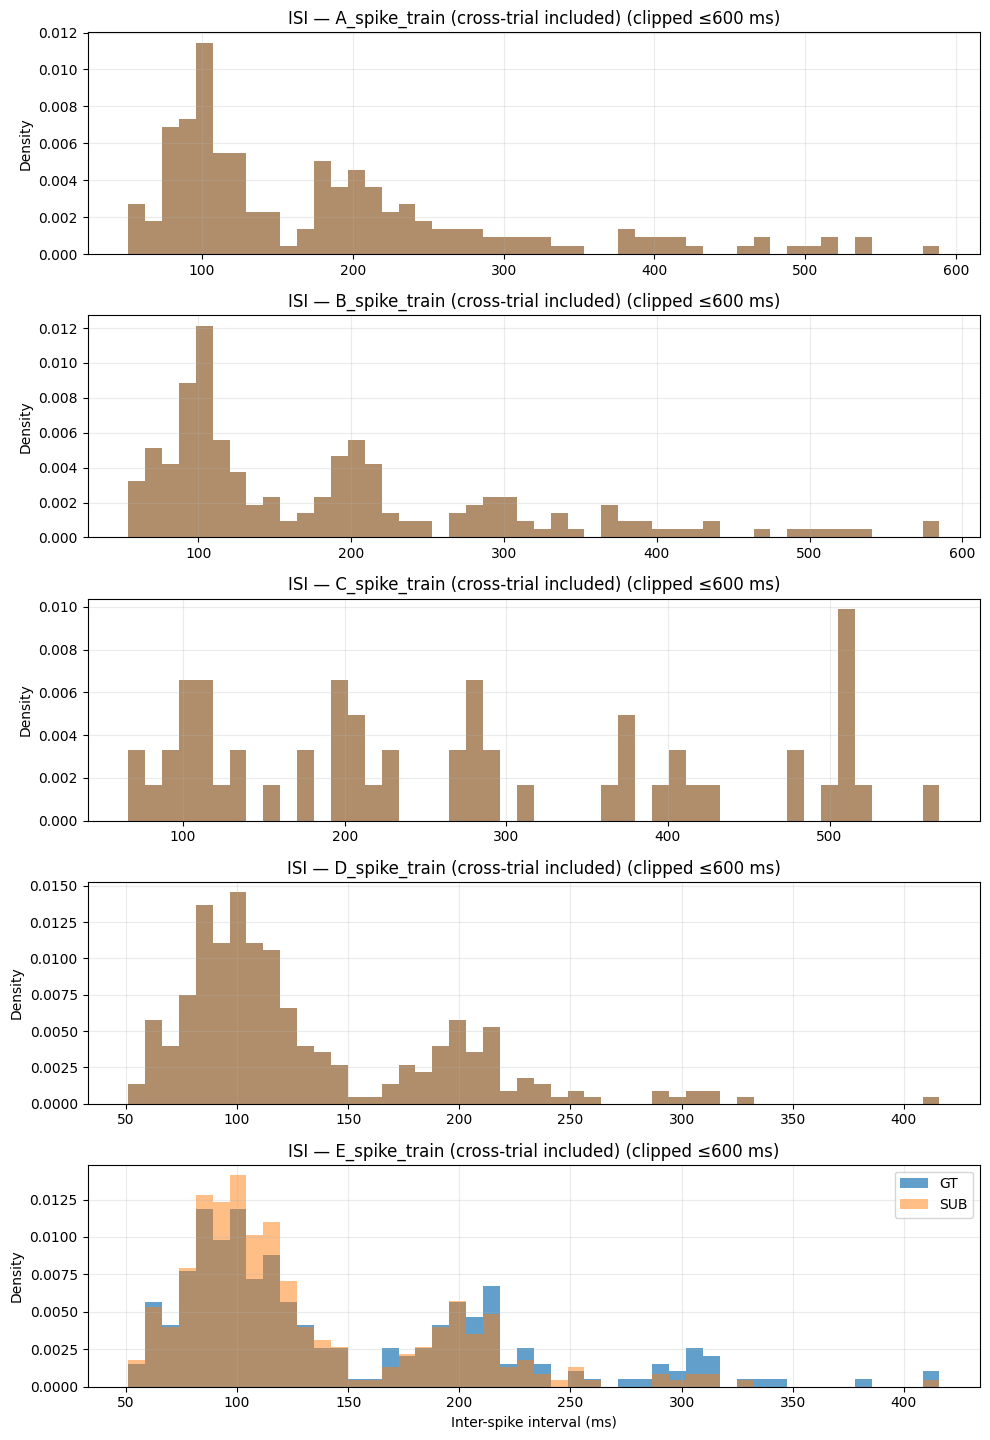

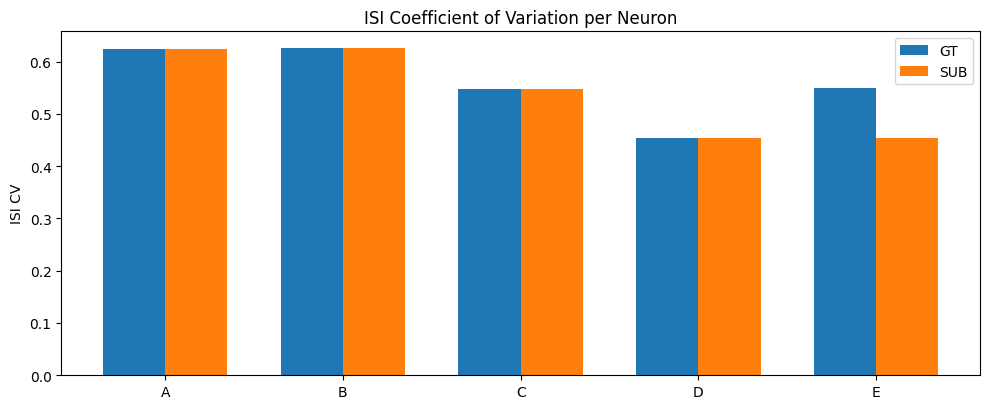


=== ISI Auto-Insights ===
• E_spike_train: Δmean≈-13% — E faster → verify D→E vs C→E balance

[ISI] Results bundled: ISI_RESULTS, ISI_INSIGHTS


In [5]:
# ISI Analysis - Inter-Spike Interval Histograms and Coefficient of Variation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import wasserstein_distance
except Exception:
    wasserstein_distance = None

# Load preprocessed data
V = METRIC_VARS_NEW
GTc = V["gt"]["concat"].copy()
SBc = V["sub"]["concat"].copy()
SPIKE_COLS = V["spike_cols"]

# Configuration
KEEP_CROSS_TRIAL = True     # Include across-trial gaps
MAX_KEEP_MS = 600           # Clip long ISIs for plotting (None = no clip)
HIST_BINS = 48
CV_BAR_WIDTH = 0.35

# Thresholds for insights
W_SMALL, W_MED, W_LARGE = 15, 35, 60   # Wasserstein distance (ms)
CV_FLAG = 0.10                          # |ΔCV| threshold
MEAN_PCT_FLAG = 0.10                    # |Δmean|/GT_mean threshold
ARTIFACT_DROP = 0.50                    # Cross-trial artifact threshold

def _isi_concatenated(df, col, keep_cross_trial=True, clip_hi=None):
    """Extract ISIs from concatenated spike train."""
    idx = np.where(df[col].to_numpy(int) == 1)[0]
    if idx.size < 2:
        return np.array([], float)

    isis = np.diff(idx).astype(float)

    if not keep_cross_trial:
        tid = df["trial_id"].to_numpy(int)
        same = tid[idx[1:]] == tid[idx[:-1]]
        isis = isis[same]

    if clip_hi is not None and isis.size:
        isis = isis[isis <= float(clip_hi)]
    return isis

def _robust_bins(a, b, nbins=48):
    """Create histogram bins spanning both distributions."""
    if a.size == 0 and b.size == 0:
        return np.linspace(0, 1, nbins+1)
    lo = np.nanmin(a) if a.size else np.nanmin(b)
    hi = np.nanmax(b) if b.size else np.nanmax(a)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        hi = lo + 1.0
    return np.linspace(lo, hi, nbins+1)

def _cv(x):
    """Compute coefficient of variation."""
    x = np.asarray(x, float)
    if x.size < 2:
        return np.nan
    m = float(np.nanmean(x))
    return np.nan if m <= 0 else float(np.nanstd(x)/m)

def _neuron_hint(name, mean_shift, cv_shift):
    """Generate tuning hints based on ISI changes."""
    base = name.split("_")[0]
    if base == "C":
        if (mean_shift is not None and mean_shift < 0) or (cv_shift is not None and cv_shift < 0):
            return "C overactive → reduce A→C/B→C or raise threshold"
        return "C underactive → increase A→C/B→C or lower threshold"
    if base == "D":
        return "Maintain OR gate consistency"
    if base == "E":
        if mean_shift is not None and mean_shift < 0:
            return "E faster → verify D→E vs C→E balance"
        return "E slower → check inhibition timing"
    if base in ("A", "B"):
        return "Input timing differs from GT"
    return None

# Compute ISIs
isis_gt = {}
isis_sb = {}
isis_gt_local = {}
isis_sb_local = {}

for col in SPIKE_COLS:
    isis_gt[col] = _isi_concatenated(GTc, col, KEEP_CROSS_TRIAL, MAX_KEEP_MS)
    isis_sb[col] = _isi_concatenated(SBc, col, KEEP_CROSS_TRIAL, MAX_KEEP_MS)
    # Local (within-trial) for artifact detection
    isis_gt_local[col] = _isi_concatenated(GTc, col, False, None)
    isis_sb_local[col] = _isi_concatenated(SBc, col, False, None)

# Figure 1: ISI Histograms
fig, axs = plt.subplots(len(SPIKE_COLS), 1, figsize=(10, 2.9*len(SPIKE_COLS)), sharex=False)
if len(SPIKE_COLS) == 1:
    axs = [axs]

for ax, col in zip(axs, SPIKE_COLS):
    g = isis_gt[col]
    s = isis_sb[col]
    bins = _robust_bins(g, s, HIST_BINS)

    if g.size:
        ax.hist(g, bins=bins, alpha=0.70, density=True, label="GT")
    if s.size:
        ax.hist(s, bins=bins, alpha=0.50, density=True, label="SUB")

    title = f"ISI — {col}"
    if KEEP_CROSS_TRIAL:
        title += " (cross-trial included)"
    if MAX_KEEP_MS is not None:
        title += f" (clipped ≤{MAX_KEEP_MS} ms)"

    ax.set_title(title)
    ax.set_ylabel("Density")
    ax.grid(alpha=0.25)

axs[-1].set_xlabel("Inter-spike interval (ms)")
axs[-1].legend(loc="upper right")
plt.tight_layout()
plt.show()

# Figure 2: ISI CV Comparison
gt_cv = [_cv(isis_gt[col]) for col in SPIKE_COLS]
sb_cv = [_cv(isis_sb[col]) for col in SPIKE_COLS]
labels = [c.replace("_spike_train", "") for c in SPIKE_COLS]
x = np.arange(len(SPIKE_COLS))

fig = plt.figure(figsize=(10, 4.2))
plt.bar(x - CV_BAR_WIDTH/2, gt_cv, CV_BAR_WIDTH, label="GT")
plt.bar(x + CV_BAR_WIDTH/2, sb_cv, CV_BAR_WIDTH, label="SUB")
plt.xticks(x, labels)
plt.ylabel("ISI CV")
plt.title("ISI Coefficient of Variation per Neuron")
plt.legend()
plt.tight_layout()
plt.show()

# Compute statistics and insights
rows = []
for col in SPIKE_COLS:
    g_all = _isi_concatenated(GTc, col, True, None)
    s_all = _isi_concatenated(SBc, col, True, None)
    g_loc = isis_gt_local[col]
    s_loc = isis_sb_local[col]

    mean_gt = np.nanmean(g_all) if g_all.size else np.nan
    mean_sb = np.nanmean(s_all) if s_all.size else np.nan
    d_mean = (mean_sb - mean_gt) if (np.isfinite(mean_sb) and np.isfinite(mean_gt)) else np.nan
    rel_mean = (d_mean / mean_gt) if (np.isfinite(d_mean) and mean_gt != 0) else np.nan

    cv_gt = _cv(g_all)
    cv_sb = _cv(s_all)
    d_cv = (cv_sb - cv_gt) if (np.isfinite(cv_sb) and np.isfinite(cv_gt)) else np.nan

    # Wasserstein distance and artifact detection
    if wasserstein_distance and g_all.size and s_all.size:
        W = float(wasserstein_distance(g_all, s_all))
        if g_loc.size and s_loc.size:
            W_local = float(wasserstein_distance(g_loc, s_loc))
            artifact_share = 0.0 if W <= 0 else max(0.0, (W - W_local) / W)
        else:
            W_local = artifact_share = np.nan
    else:
        W = W_local = artifact_share = np.nan

    rows.append(dict(
        Neuron=col, nGT=int(g_all.size), nSUB=int(s_all.size),
        meanGT=mean_gt, meanSUB=mean_sb, dMean=d_mean, relMean=rel_mean,
        cvGT=cv_gt, cvSUB=cv_sb, dCV=d_cv,
        W=W, W_local=W_local, artifact_share=artifact_share
    ))

stats_df = pd.DataFrame(rows)

# Generate insights
bullets = []
for _, r in stats_df.iterrows():
    name = r["Neuron"]
    W = r["W"]
    dcv = r["dCV"]
    rmean = r["relMean"]
    art = r["artifact_share"]
    n_ok = (r["nGT"] >= 20 and r["nSUB"] >= 20)

    # Severity assessment
    if np.isfinite(W):
        if W >= W_LARGE:
            sev = "large"
        elif W >= W_MED:
            sev = "moderate"
        elif W >= W_SMALL:
            sev = "small"
        else:
            sev = "tiny"
    else:
        sev = "n/a"

    art_tag = " (mostly cross-trial)" if (np.isfinite(art) and art >= ARTIFACT_DROP) else ""

    calls = []
    if n_ok and np.isfinite(W) and W >= W_MED:
        calls.append(f"W={W:.1f} ms {sev}{art_tag}")
    if n_ok and np.isfinite(dcv) and abs(dcv) >= CV_FLAG:
        calls.append(f"ΔCV={dcv:+.2f}")
    if n_ok and np.isfinite(rmean) and abs(rmean) >= MEAN_PCT_FLAG:
        calls.append(f"Δmean≈{rmean*100:+.0f}%")

    if calls:
        hint = _neuron_hint(name, r["dMean"] if np.isfinite(r["dMean"]) else None,
                           r["dCV"] if np.isfinite(r["dCV"]) else None)
        bullets.append(f"{name}: " + "; ".join(calls) + (f" — {hint}" if hint else ""))

if not bullets:
    bullets = ["ISI: GT and SUB closely match across all neurons"]

print("\n=== ISI Auto-Insights ===")
for b in bullets:
    print("•", b)

# Bundle results
ISI_RESULTS = dict(
    hist_config=dict(keep_cross_trial=KEEP_CROSS_TRIAL, max_keep_ms=MAX_KEEP_MS, bins=HIST_BINS),
    cv_gt=np.array(gt_cv, float),
    cv_sub=np.array(sb_cv, float),
    neurons=SPIKE_COLS
)
ISI_INSIGHTS = dict(bullets=bullets, table=stats_df)
print("\n[ISI] Results bundled: ISI_RESULTS, ISI_INSIGHTS")

## Fano

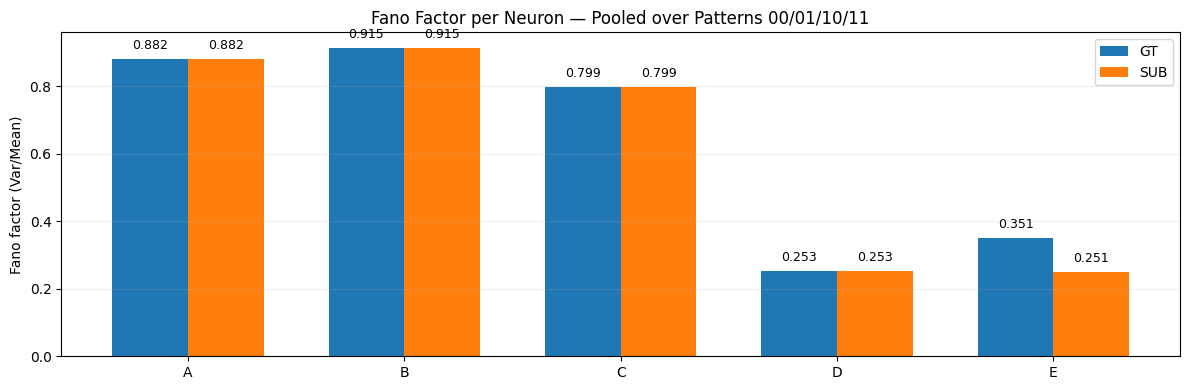

A: FF_GT=0.882  FF_SUB=0.882  (Mean_GT=0.12, Mean_SUB=0.12, Trials=400)
B: FF_GT=0.915  FF_SUB=0.915  (Mean_GT=0.09, Mean_SUB=0.09, Trials=400)
C: FF_GT=0.799  FF_SUB=0.799  (Mean_GT=0.20, Mean_SUB=0.20, Trials=400)
D: FF_GT=0.253  FF_SUB=0.253  (Mean_GT=0.75, Mean_SUB=0.75, Trials=400)
E: FF_GT=0.351  FF_SUB=0.251  (Mean_GT=0.65, Mean_SUB=0.75, Trials=400)

[Fano Factor Issues]
• E: ΔFano=-0.10


In [6]:
# Fano Factor Analysis - Variance-to-Mean Ratio per Neuron
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load preprocessed data
V = METRIC_VARS_NEW
GT_trials = V["gt"]["trials"]
SB_trials = V["sub"]["trials"]
GT_meta = V["gt"]["meta"]
SB_meta = V["sub"]["meta"]
SPIKE_COLS = V["spike_cols"]

# Configuration
PATS = ("00", "01", "10", "11")
TRIAL_LEN = len(GT_trials[0]) if GT_trials else 100
DEFAULT_00_WINDOW = (max(0, 5), min(TRIAL_LEN - 1, 95))

# Issue thresholds
DELTA_FANO_FLAG = 0.10  # |ΔFF| threshold
DELTA_MEAN_FLAG = 0.10  # |ΔMean| threshold in spikes

def _trial_ids(meta, p):
    """Get indices of trials with specified pattern."""
    return [i for i, m in enumerate(meta) if m.get("pattern") == p]

def _counts_in_window(trials, meta, col, ids):
    """Extract spike counts within response window for each trial."""
    out = []
    for i in ids:
        pat = meta[i].get("pattern")
        rw = meta[i].get("response_window")

        # Use default window for pattern 00 if no response window
        if (rw is None) and (pat == "00"):
            lo, hi = DEFAULT_00_WINDOW
        elif (rw is None) or (rw[1] < rw[0]):
            out.append(np.nan)
            continue
        else:
            lo, hi = int(rw[0]), int(rw[1])

        vec = trials[i][col].to_numpy(int)
        lo = max(0, int(lo))
        hi = min(len(vec) - 1, int(hi))
        out.append(float(vec[lo:hi+1].sum()) if hi >= lo else np.nan)

    a = np.array(out, float)
    return a[np.isfinite(a)]

def _pooled_counts(trials, meta, col, patterns):
    """Pool spike counts across patterns using trial-paired approach."""
    bags = []
    for p in patterns:
        ids = sorted(set(_trial_ids(GT_meta, p)).intersection(_trial_ids(SB_meta, p)))
        if ids:
            bags.append(_counts_in_window(trials, meta, col, ids))
    return np.concatenate(bags) if bags else np.array([], float)

def _fano(arr):
    """Calculate mean, variance, and Fano factor."""
    arr = np.asarray(arr, float)
    n = arr.size
    if n < 2:
        return np.nan, np.nan, np.nan, 0
    mu = float(np.mean(arr))
    var = float(np.var(arr, ddof=1))  # Sample variance
    ff = (var / mu) if mu > 0 else np.nan
    return mu, var, ff, n

# Compute Fano factors
rows = []
for col in SPIKE_COLS:
    gt_c = _pooled_counts(GT_trials, GT_meta, col, PATS)
    sb_c = _pooled_counts(SB_trials, SB_meta, col, PATS)

    mu_g, var_g, ff_g, n_g = _fano(gt_c)
    mu_s, var_s, ff_s, n_s = _fano(sb_c)

    rows.append(dict(
        neuron = col.replace("_spike_train", ""),
        ff_gt = ff_g,
        ff_sub = ff_s,
        mean_gt = mu_g,
        mean_sub = mu_s,
        trials = int(min(n_g, n_s)),
        d_ff = (ff_s - ff_g) if (np.isfinite(ff_s) and np.isfinite(ff_g)) else np.nan,
        d_mean = (mu_s - mu_g) if (np.isfinite(mu_s) and np.isfinite(mu_g)) else np.nan
    ))

df = pd.DataFrame(rows)

# Plot Fano factors
labels = df["neuron"].tolist()
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
bars1 = ax.bar(x - w/2, df["ff_gt"].to_numpy(), width=w, label="GT")
bars2 = ax.bar(x + w/2, df["ff_sub"].to_numpy(), width=w, label="SUB")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Fano factor (Var/Mean)")
ax.set_title("Fano Factor per Neuron — Pooled over Patterns 00/01/10/11")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.2)

# Annotate bars with values
def _annotate(ax, bars, vals):
    for b, v in zip(bars, vals):
        txt = "n/a" if not np.isfinite(v) else f"{v:.3f}"
        y = 0.0 if not np.isfinite(v) else float(v)
        ax.text(b.get_x() + b.get_width()/2, y + 0.02, txt,
                ha="center", va="bottom", fontsize=9)

_annotate(ax, bars1, df["ff_gt"].to_numpy())
_annotate(ax, bars2, df["ff_sub"].to_numpy())

plt.tight_layout()
plt.show()

# Print summary
for _, r in df.iterrows():
    ff_gt = "n/a" if not np.isfinite(r["ff_gt"]) else f"{r['ff_gt']:.3f}"
    ff_sb = "n/a" if not np.isfinite(r["ff_sub"]) else f"{r['ff_sub']:.3f}"
    print(f"{r['neuron']}: FF_GT={ff_gt}  FF_SUB={ff_sb}  "
          f"(Mean_GT={r['mean_gt']:.2f}, Mean_SUB={r['mean_sub']:.2f}, Trials={int(r['trials'])})")

# Generate issue notes
notes = []
for _, r in df.iterrows():
    if (np.isfinite(r["d_ff"]) and abs(r["d_ff"]) > DELTA_FANO_FLAG) or \
       (np.isfinite(r["d_mean"]) and abs(r["d_mean"]) > DELTA_MEAN_FLAG):
        tag = []
        if np.isfinite(r["d_ff"]) and abs(r["d_ff"]) > DELTA_FANO_FLAG:
            tag.append(f"ΔFano={r['d_ff']:+.2f}")
        if np.isfinite(r["d_mean"]) and abs(r["d_mean"]) > DELTA_MEAN_FLAG:
            tag.append(f"ΔMean={r['d_mean']:+.2f}")
        notes.append(f"• {r['neuron']}: " + ", ".join(tag))

if notes:
    print("\n[Fano Factor Issues]")
    for line in notes:
        print(line)

## Membrane Potentials

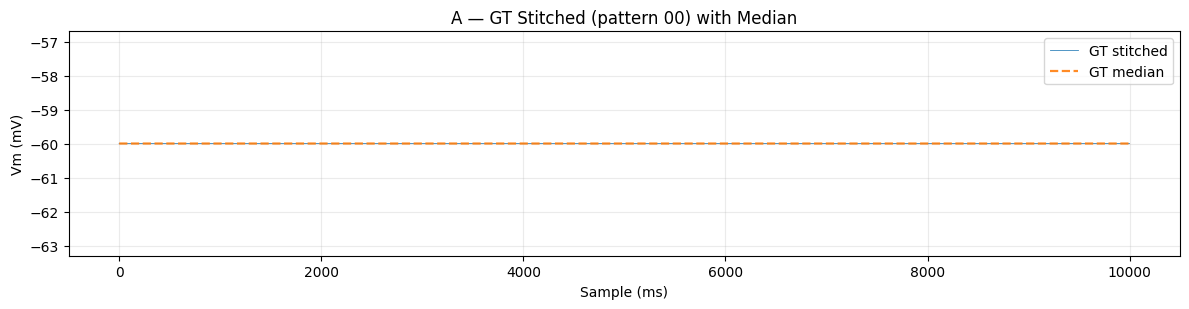

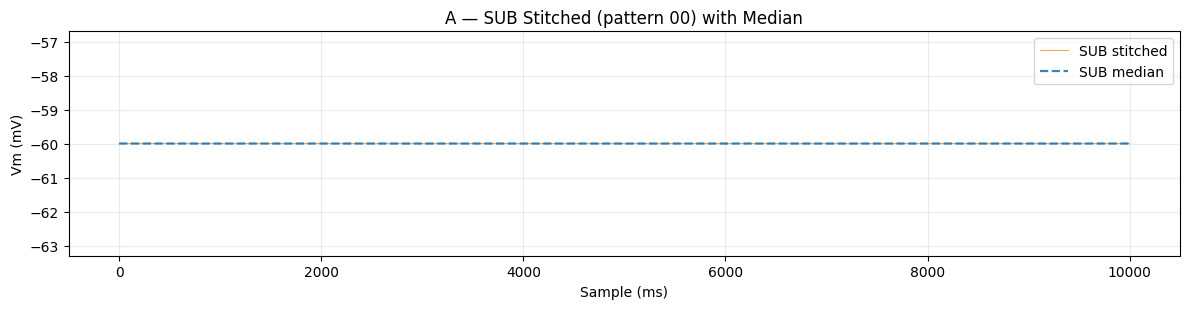

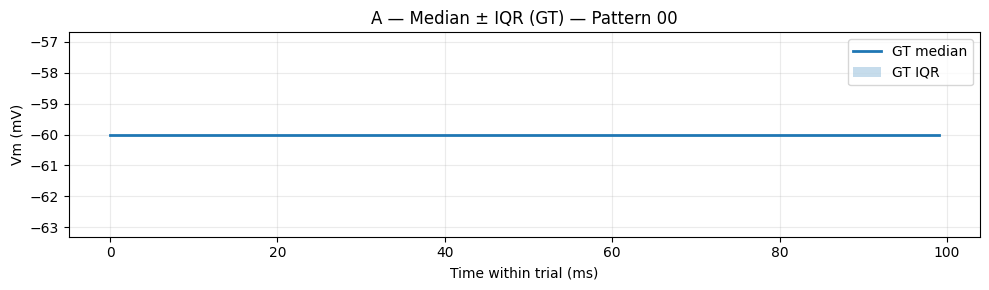

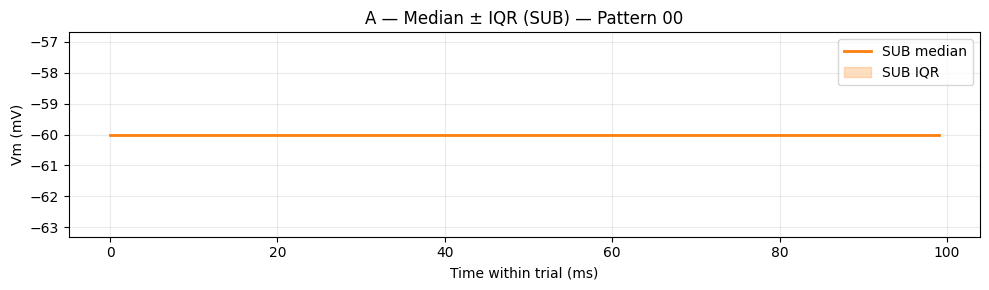

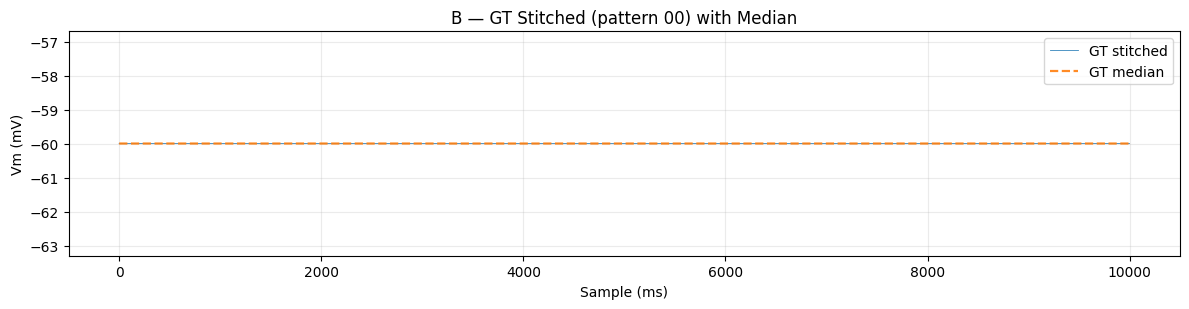

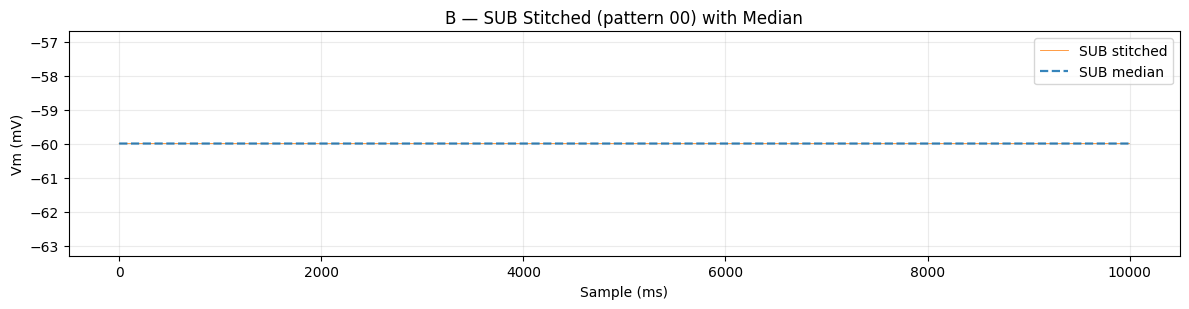

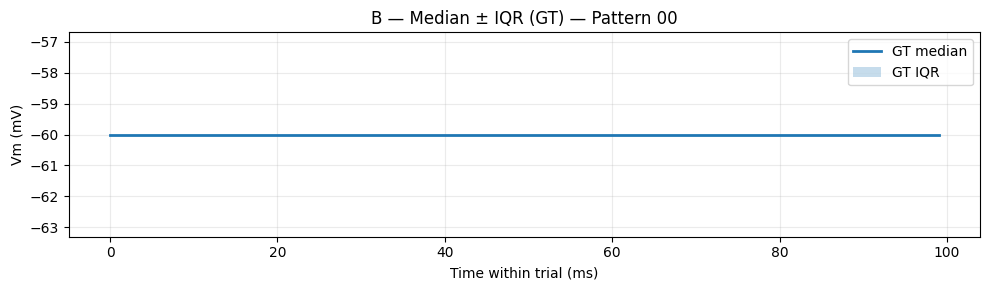

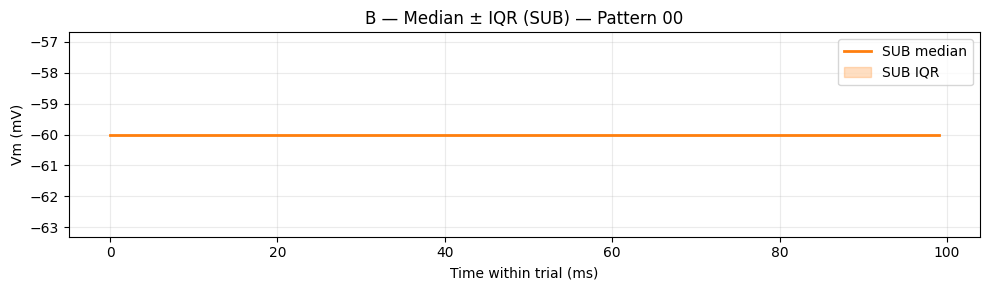

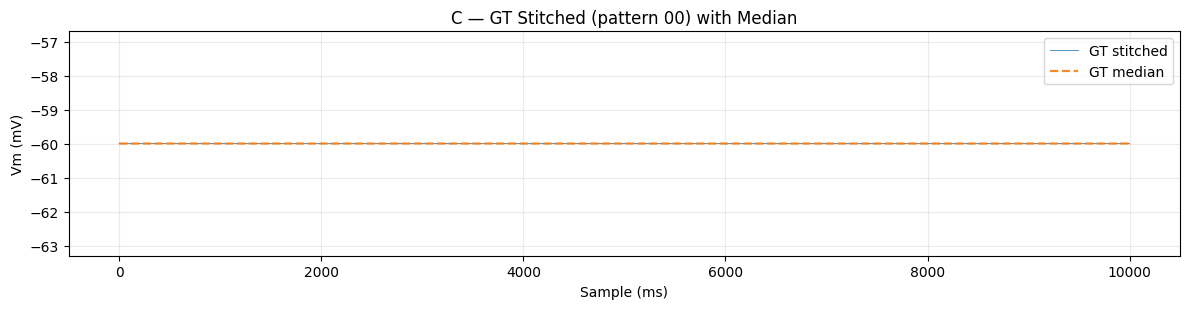

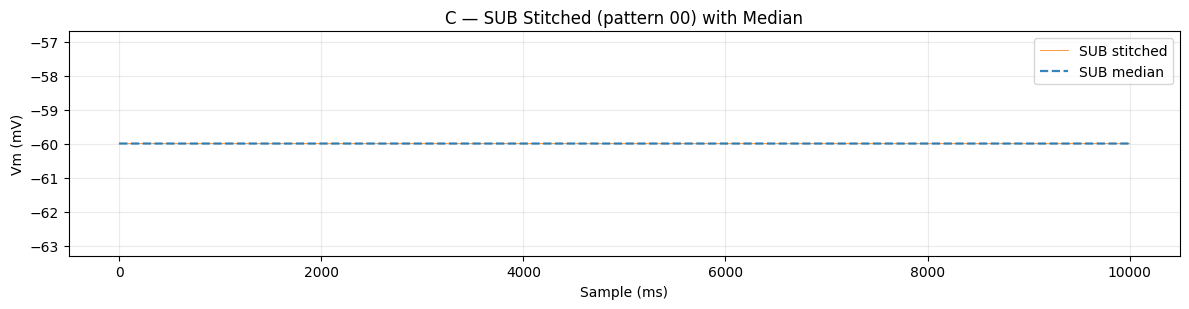

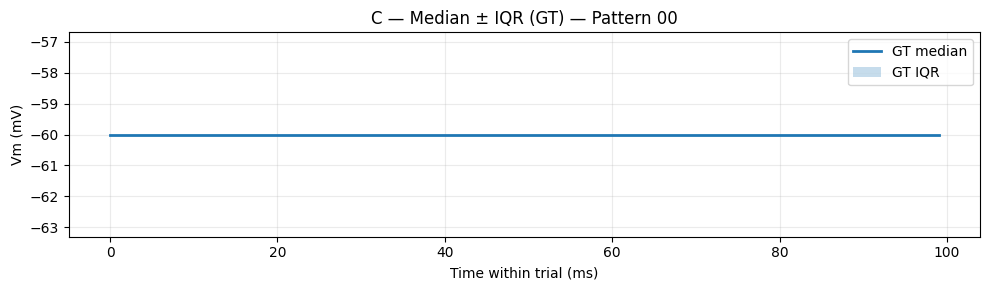

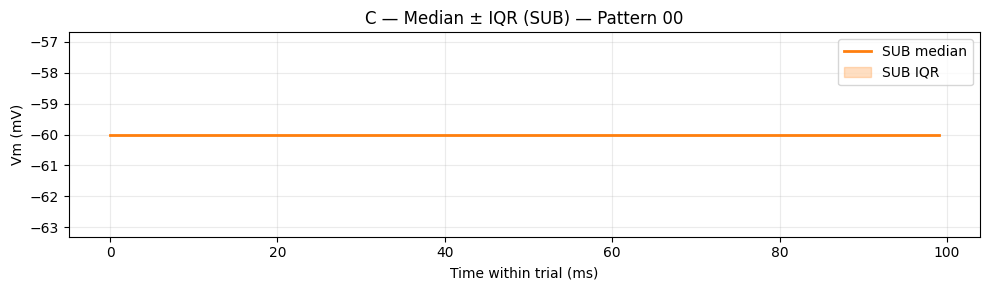

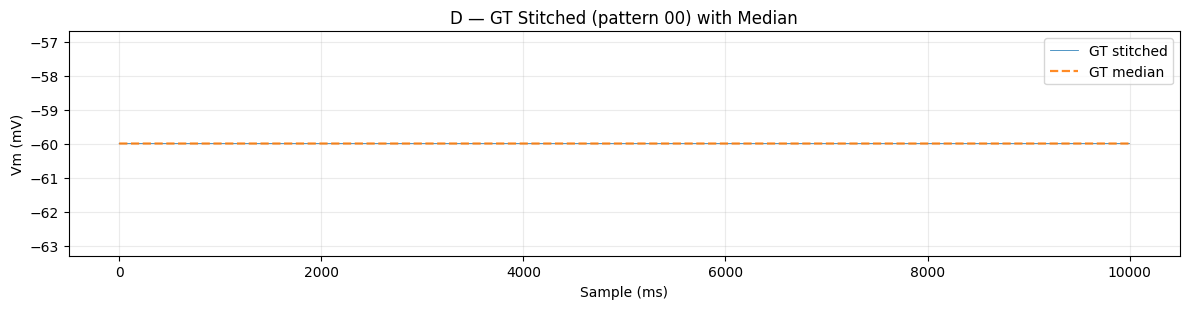

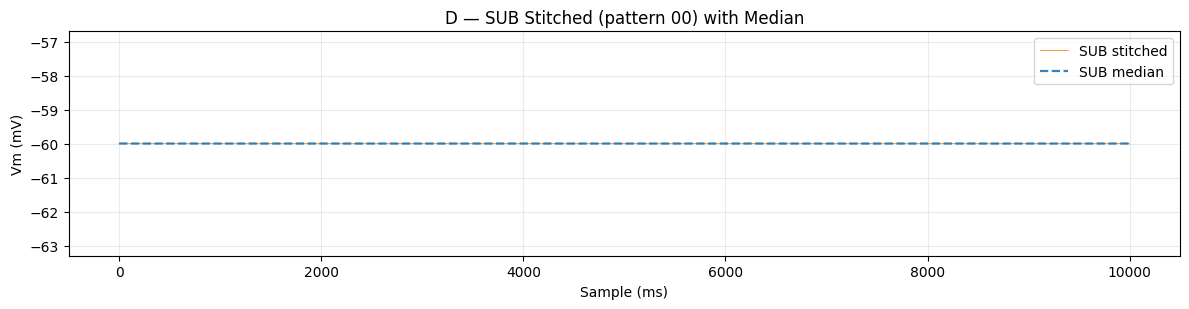

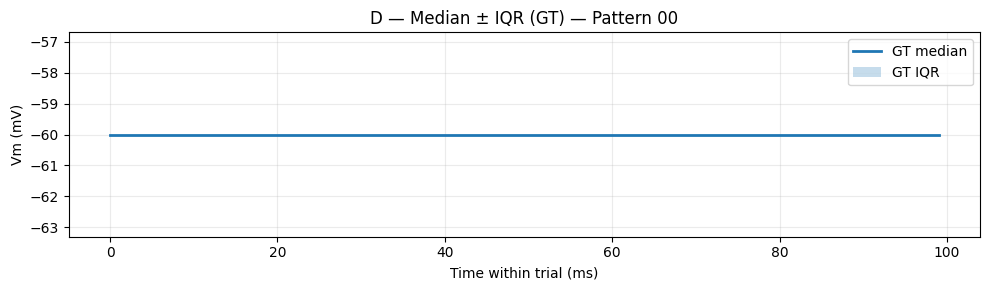

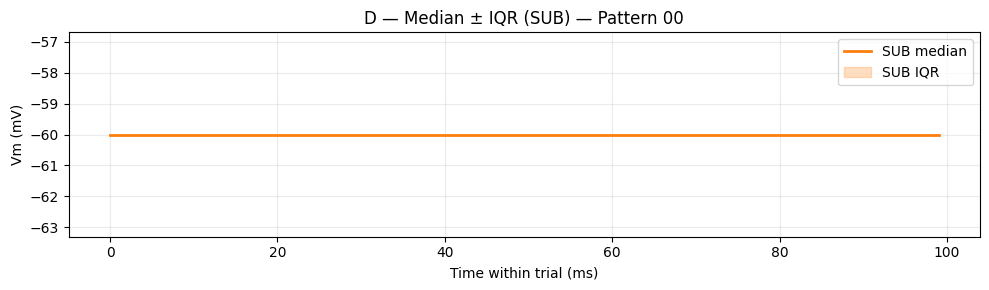

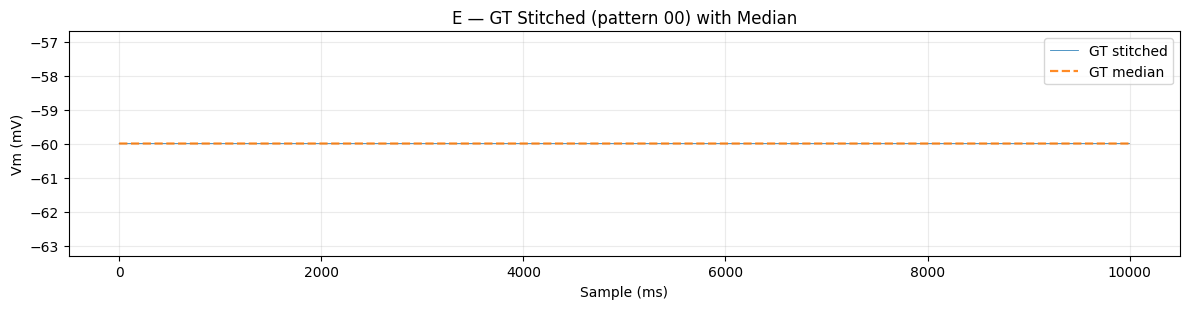

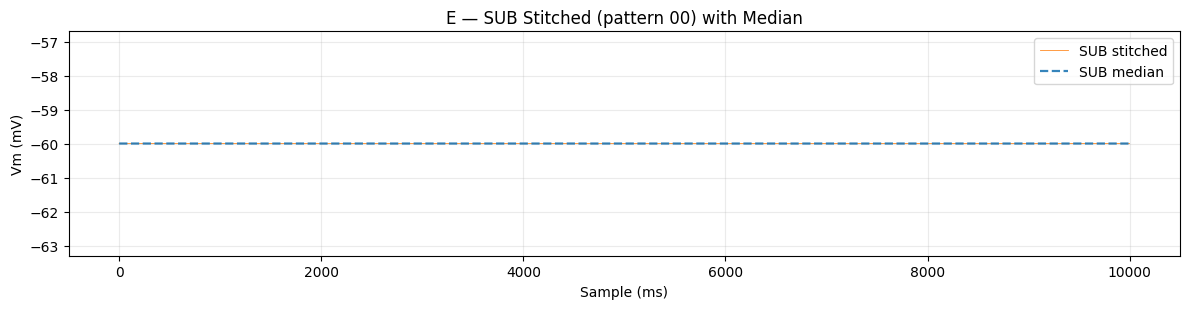

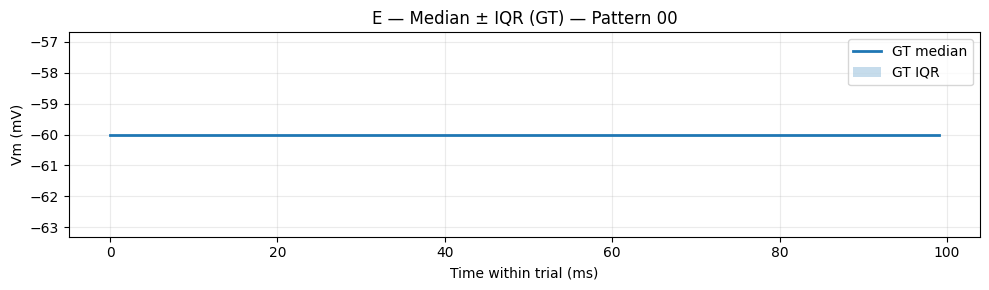

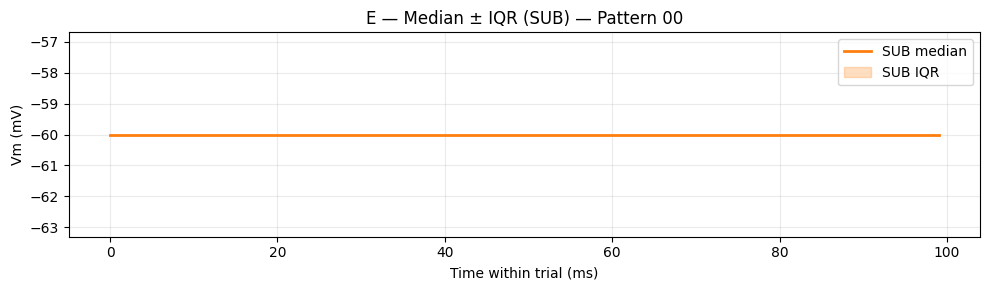

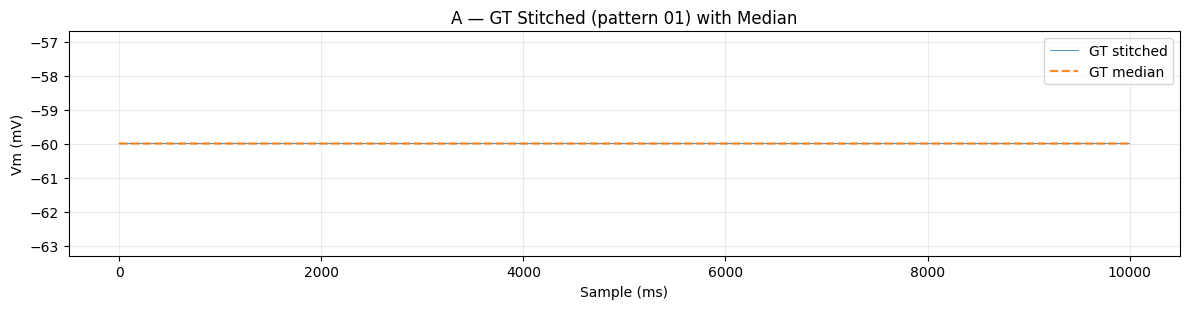

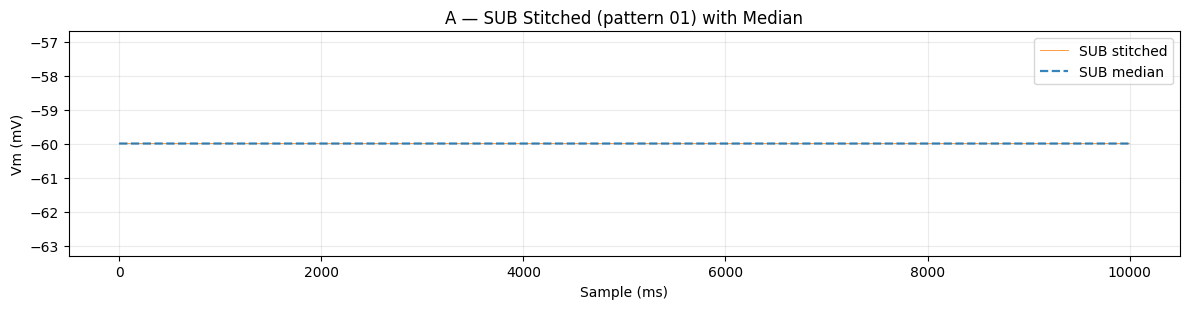

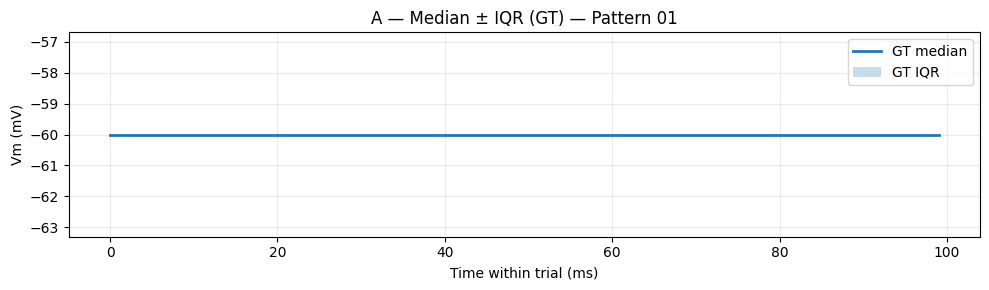

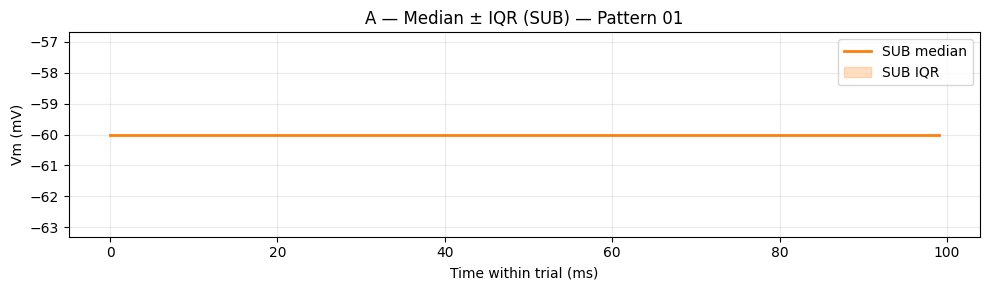

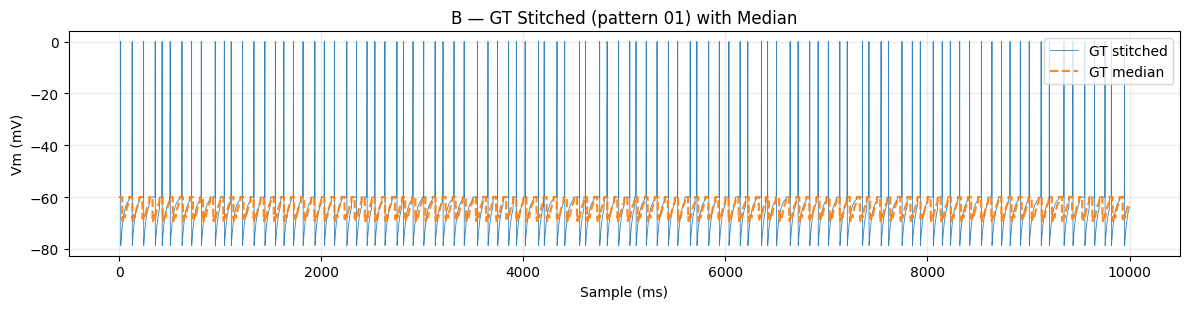

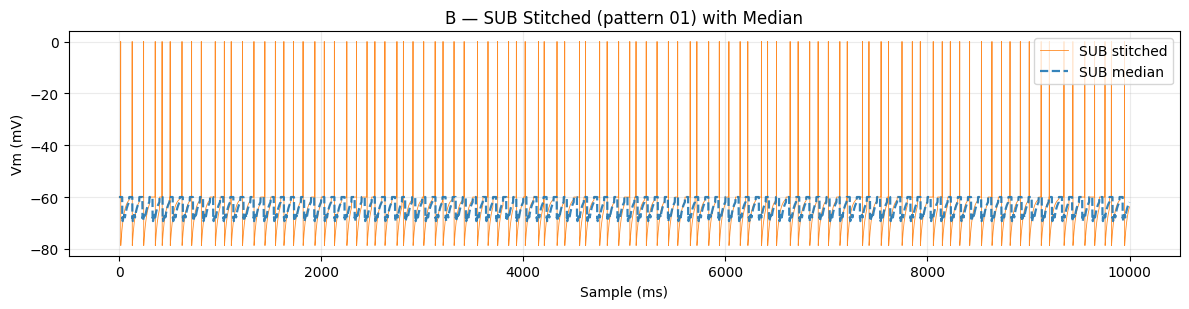

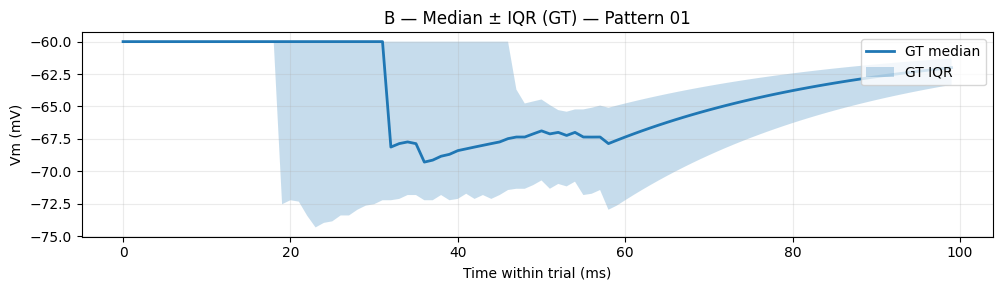

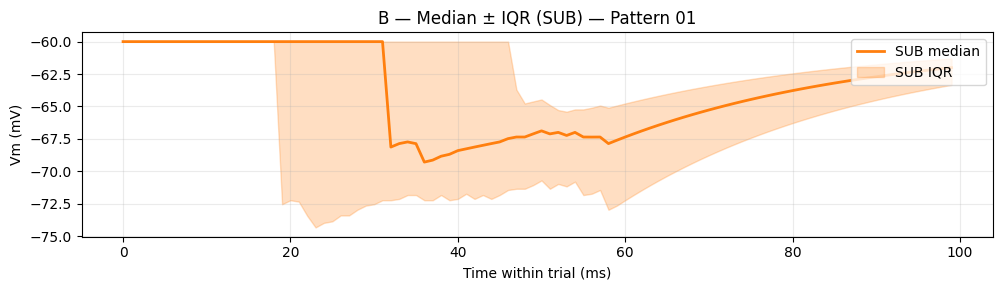

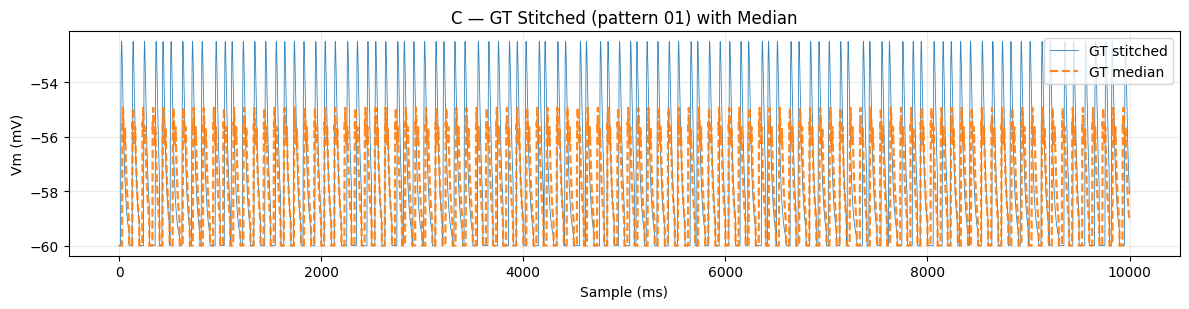

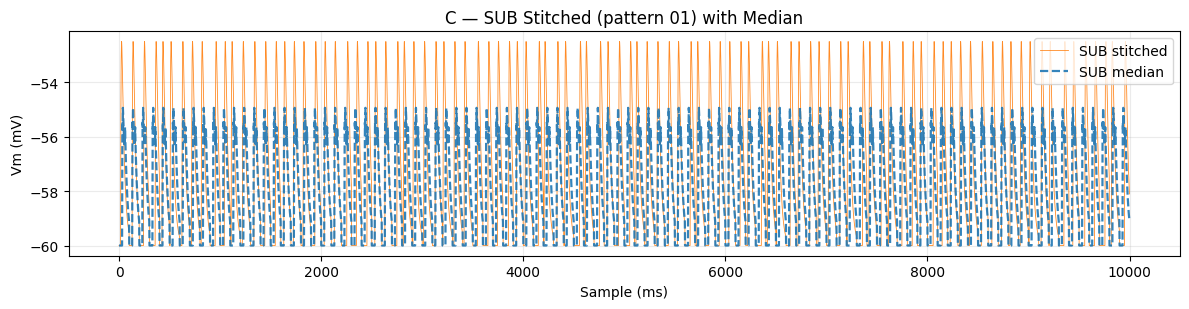

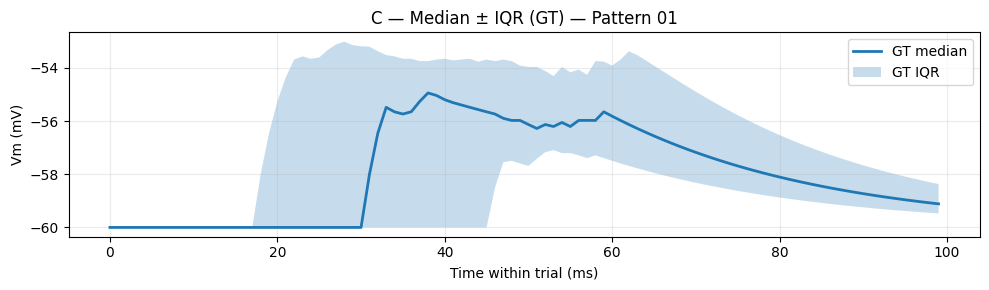

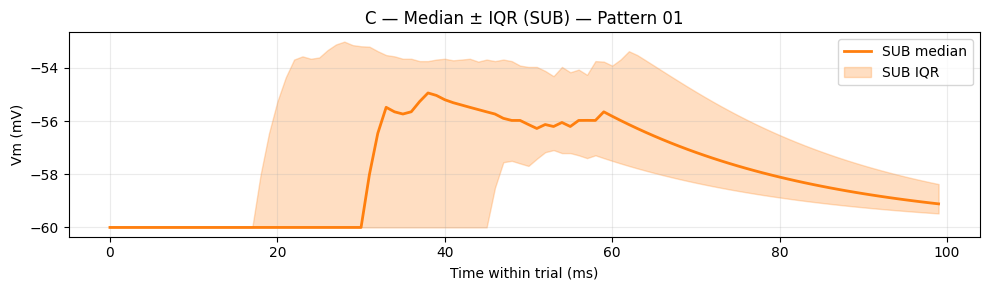

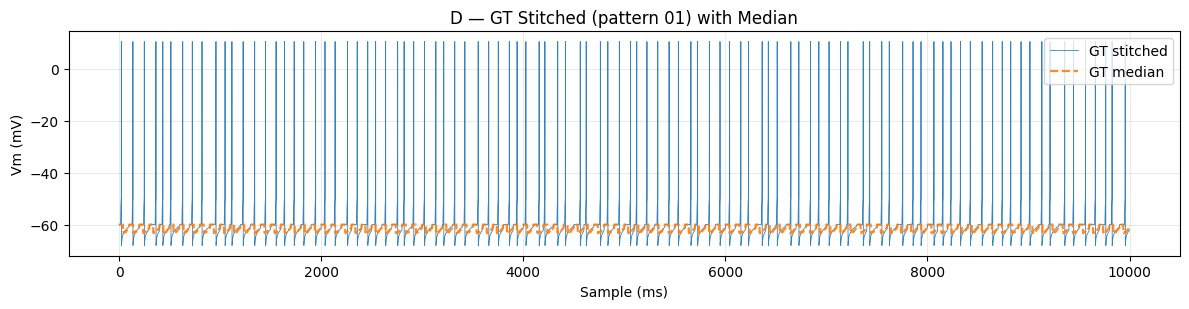

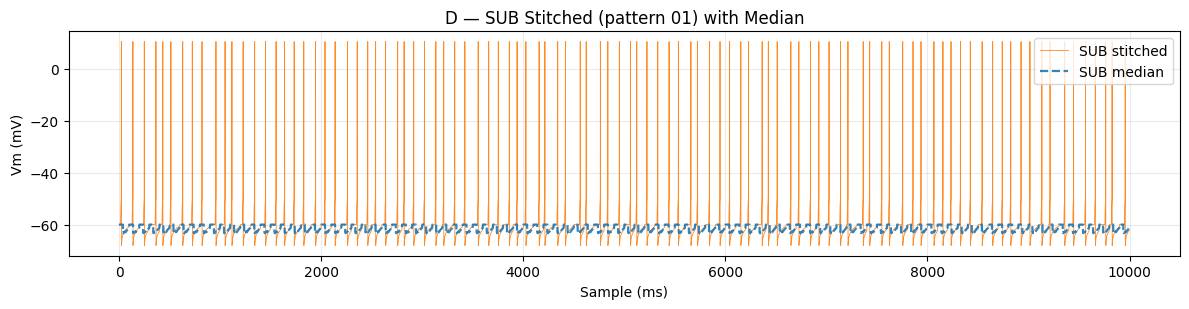

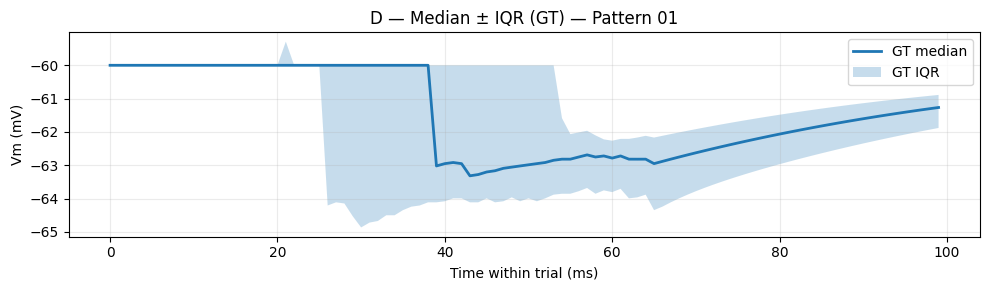

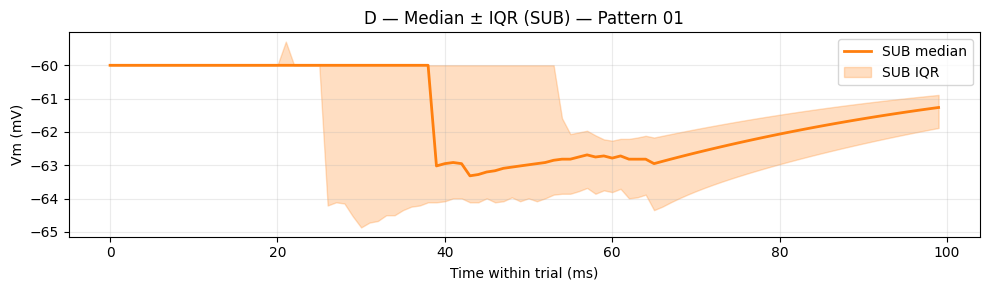

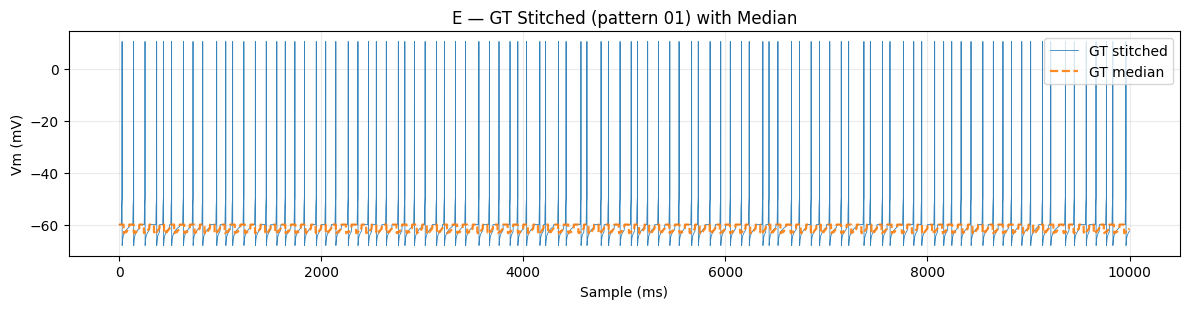

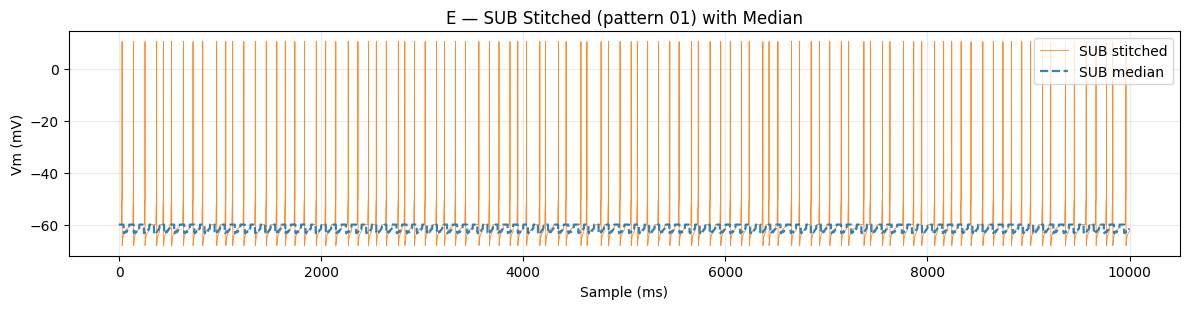

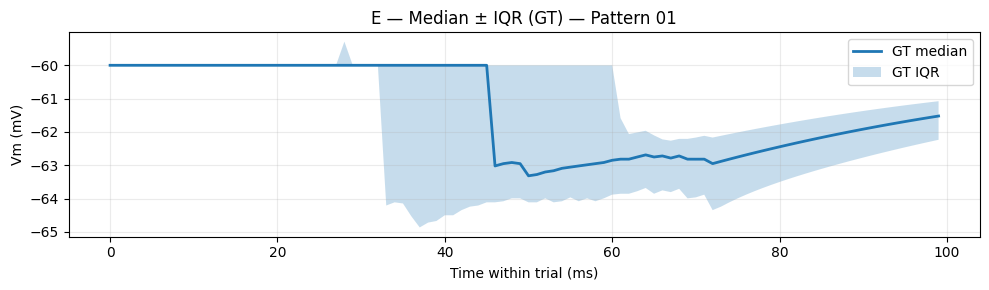

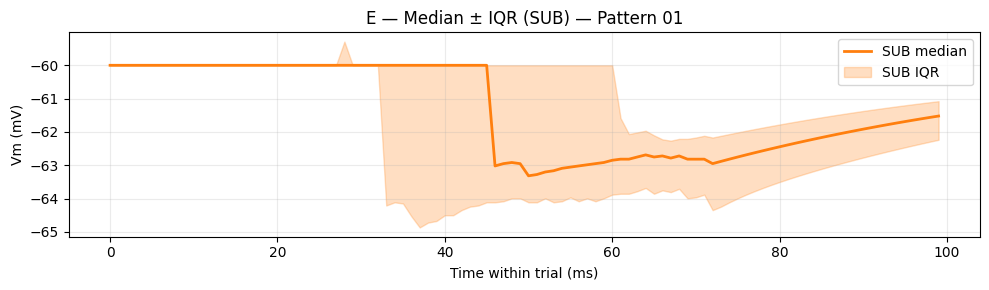

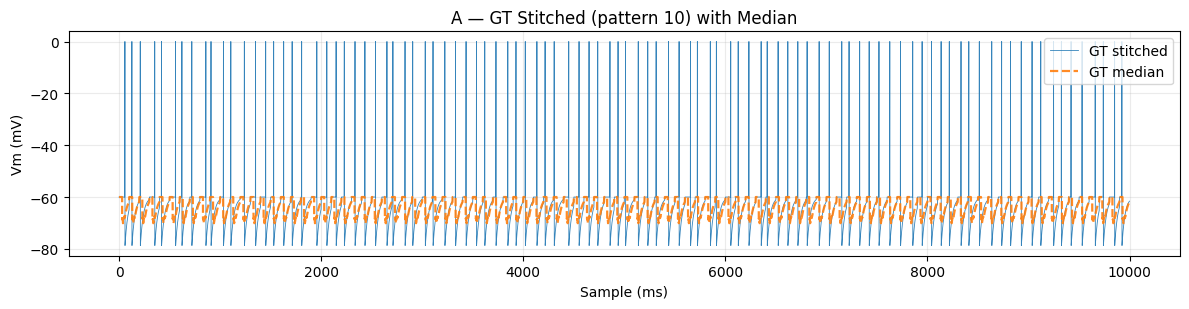

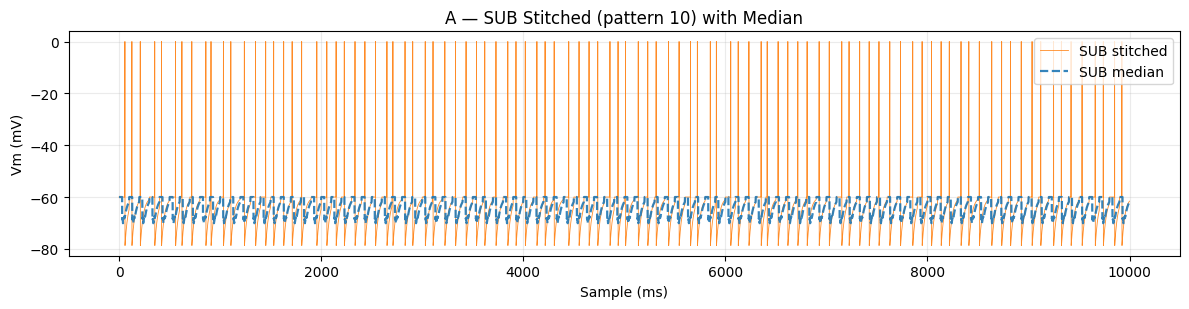

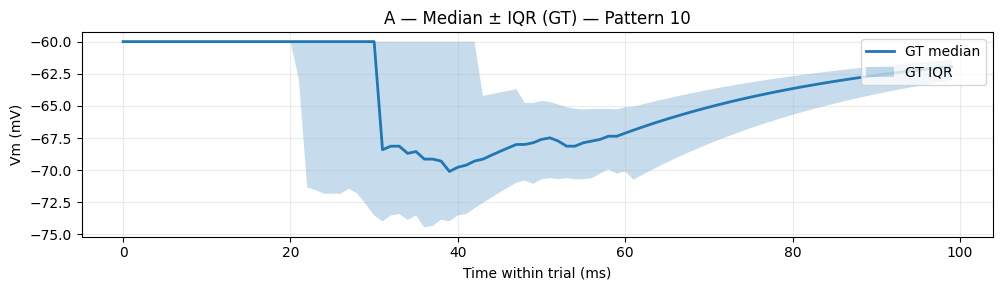

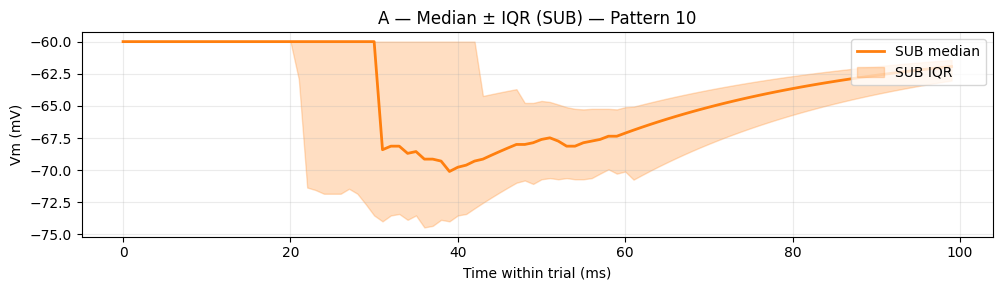

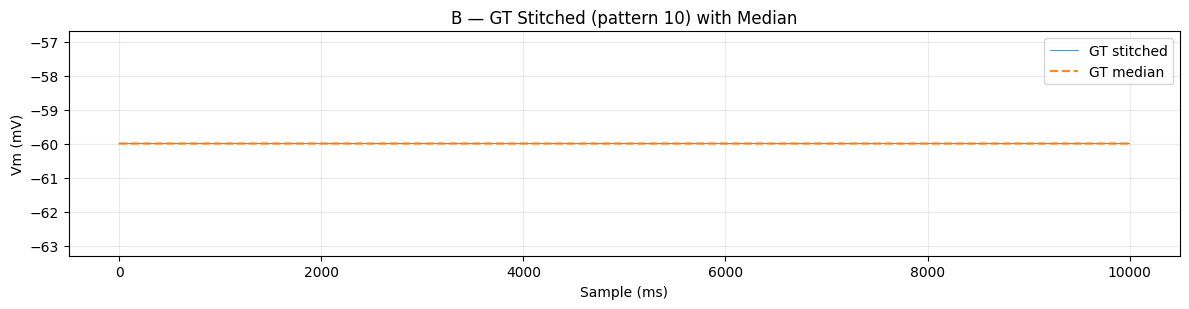

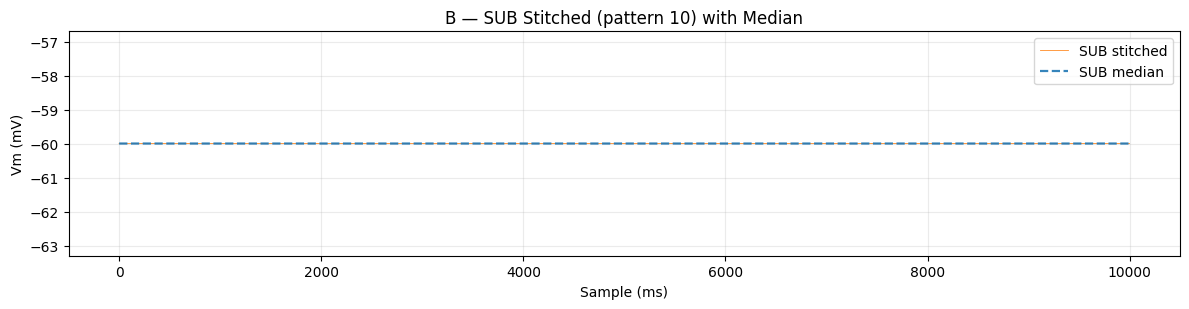

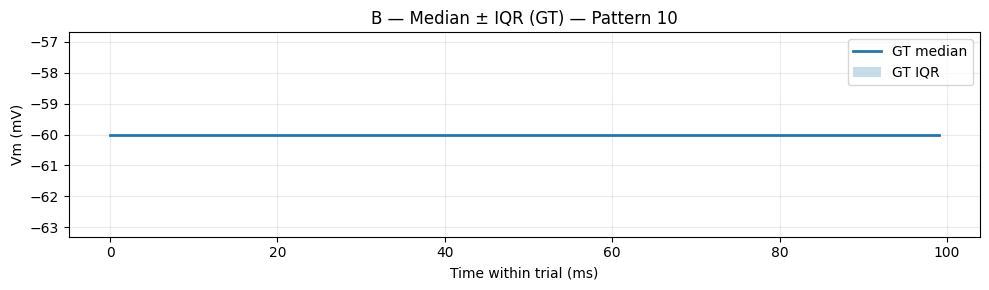

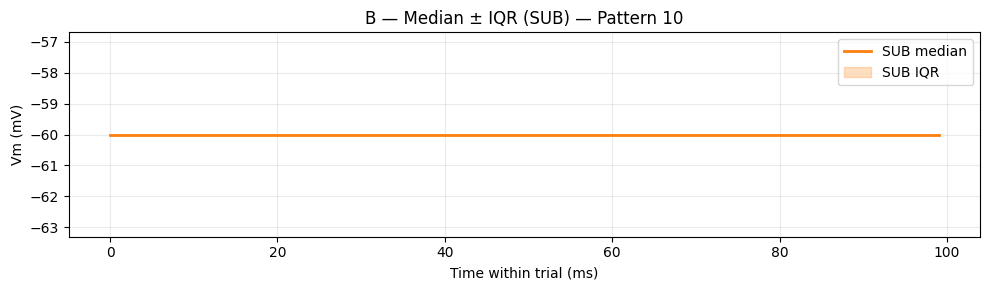

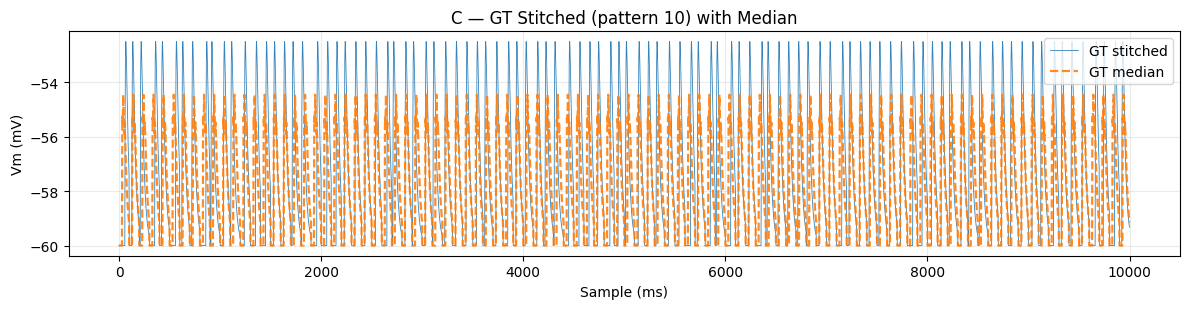

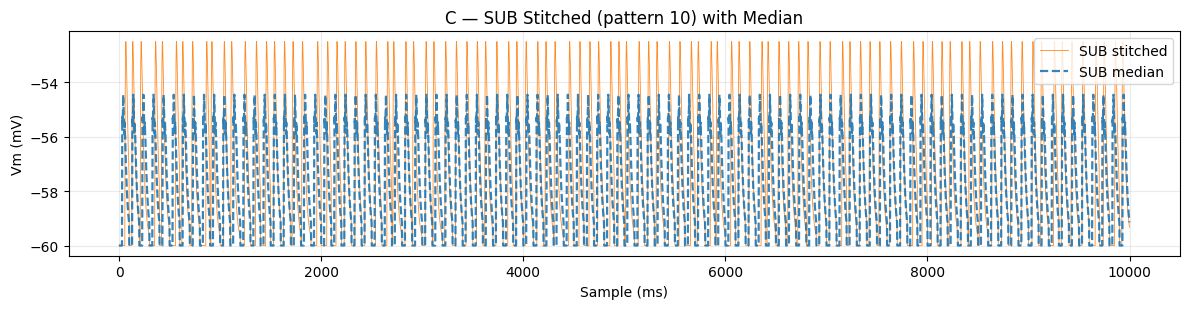

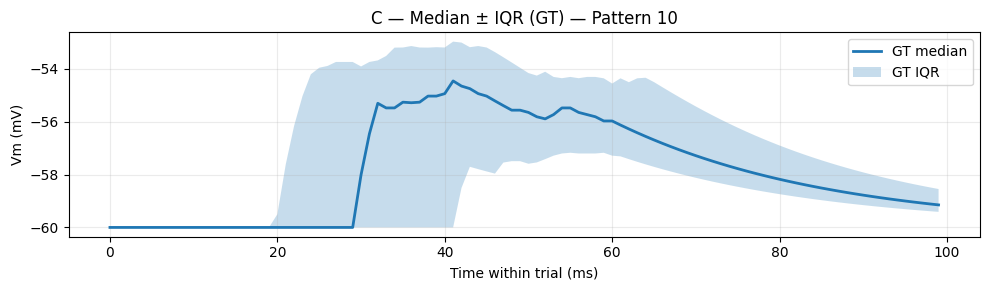

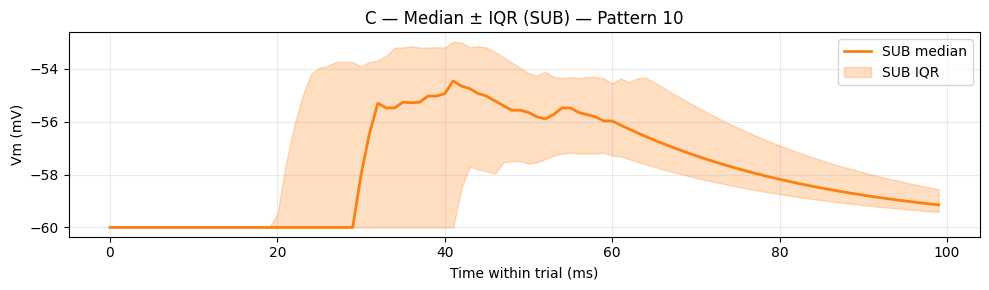

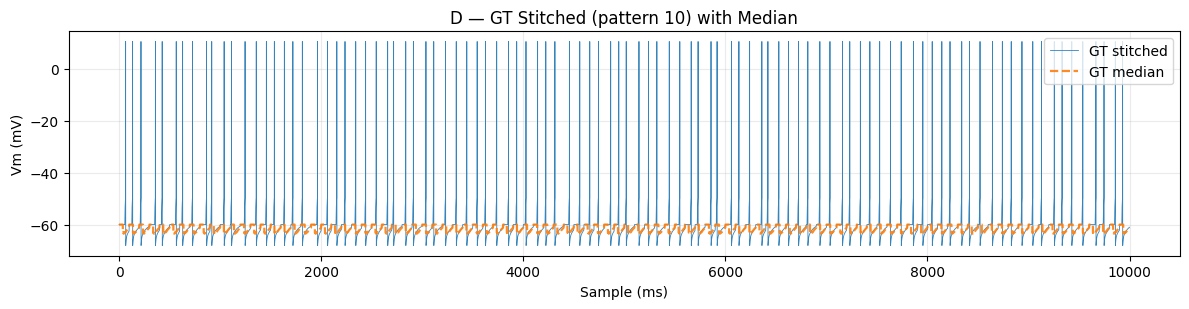

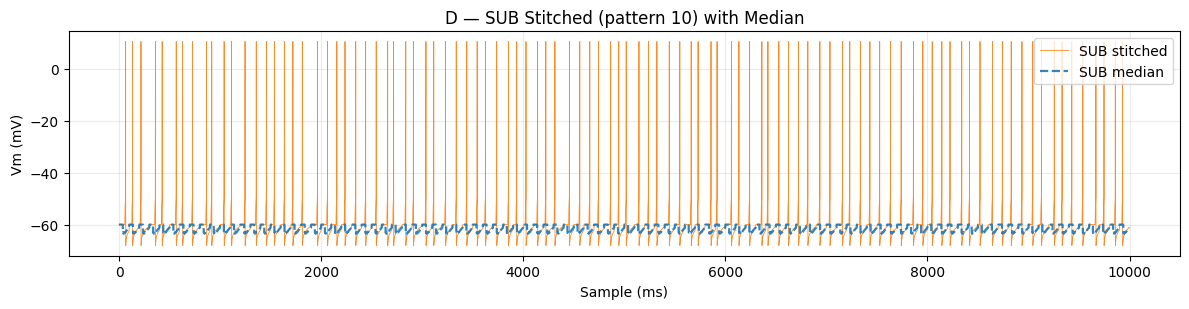

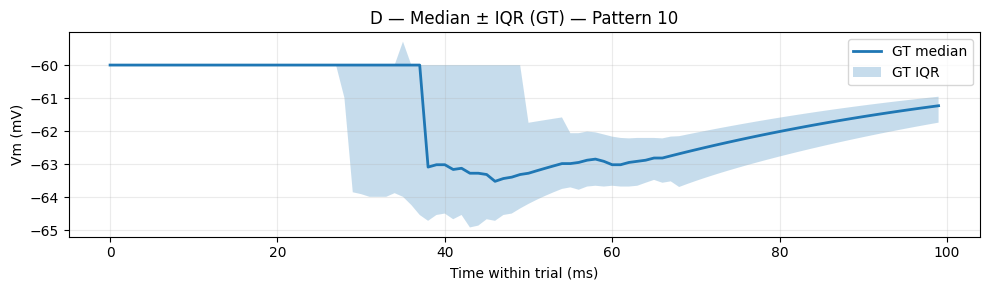

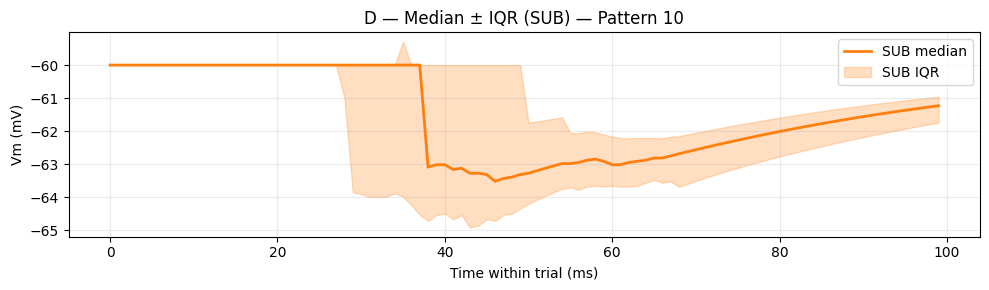

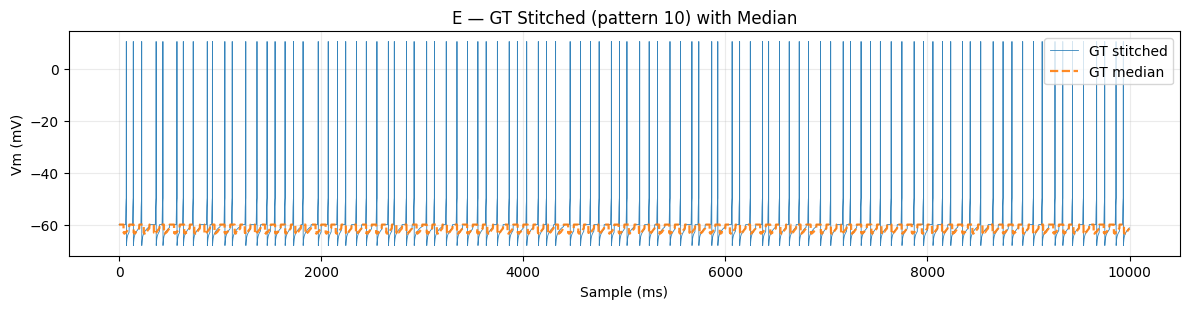

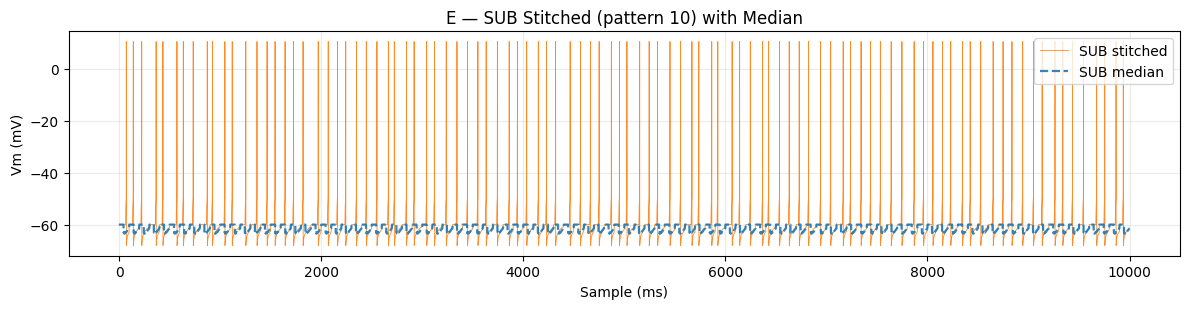

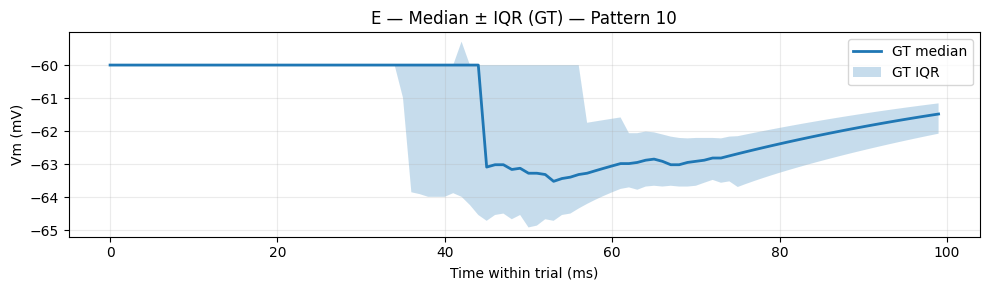

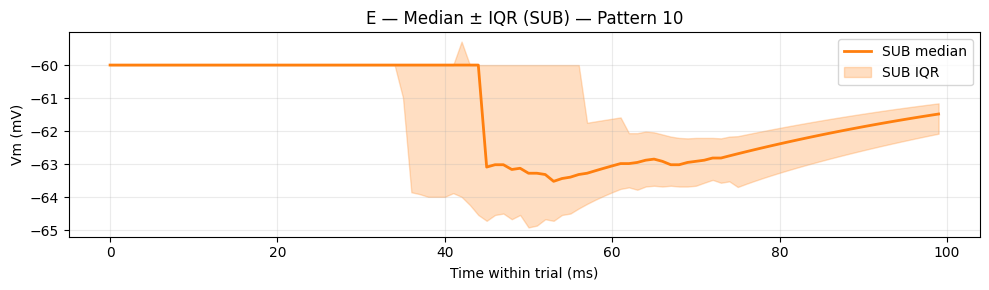

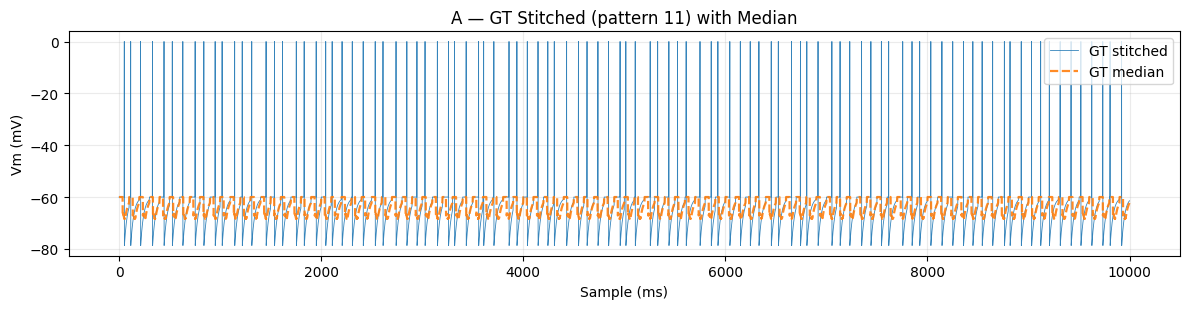

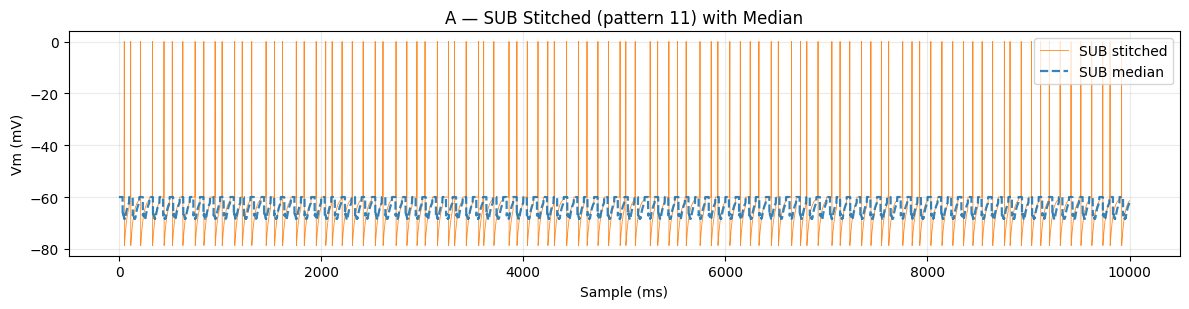

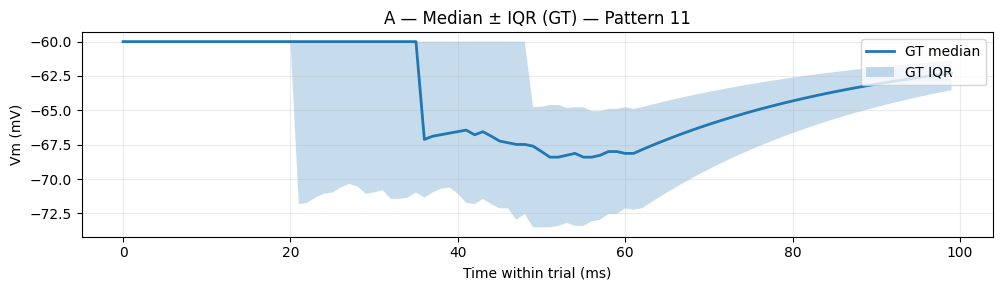

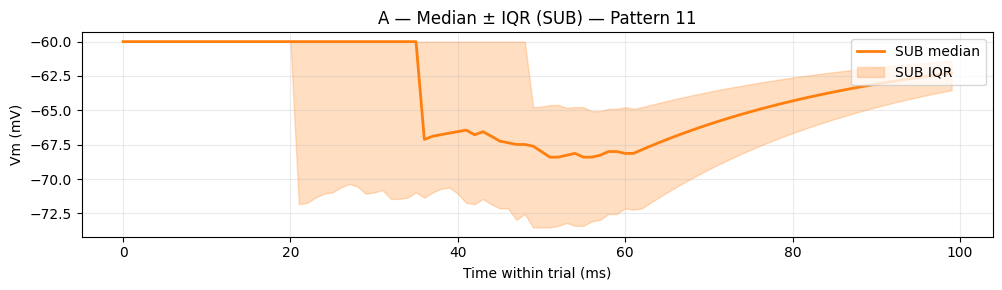

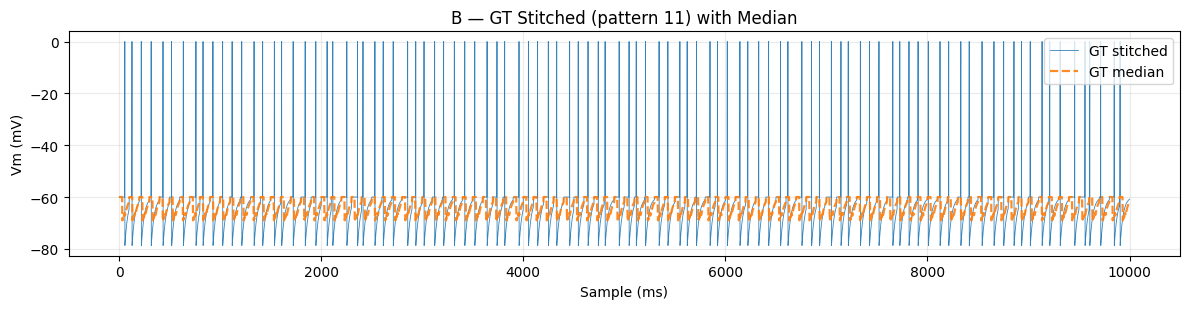

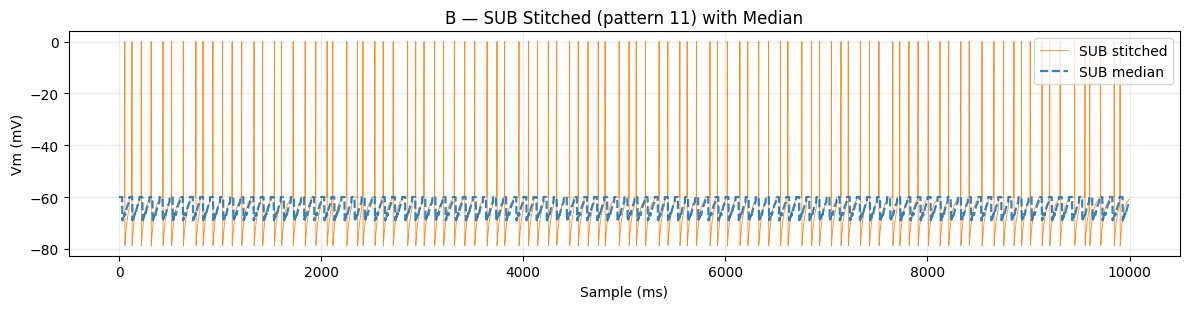

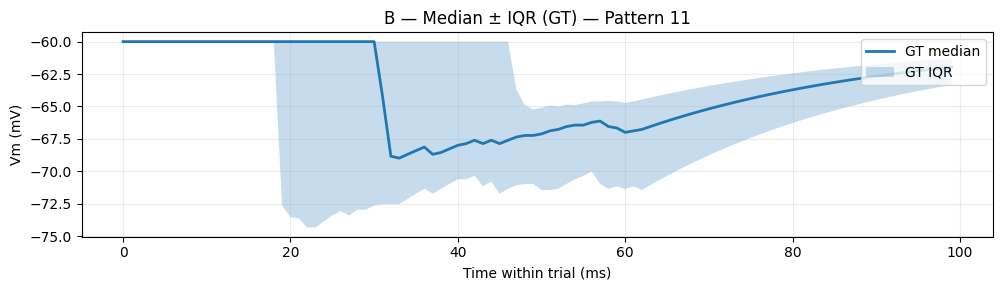

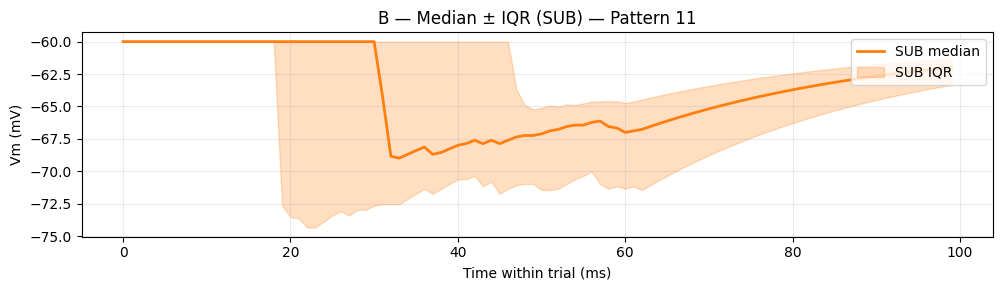

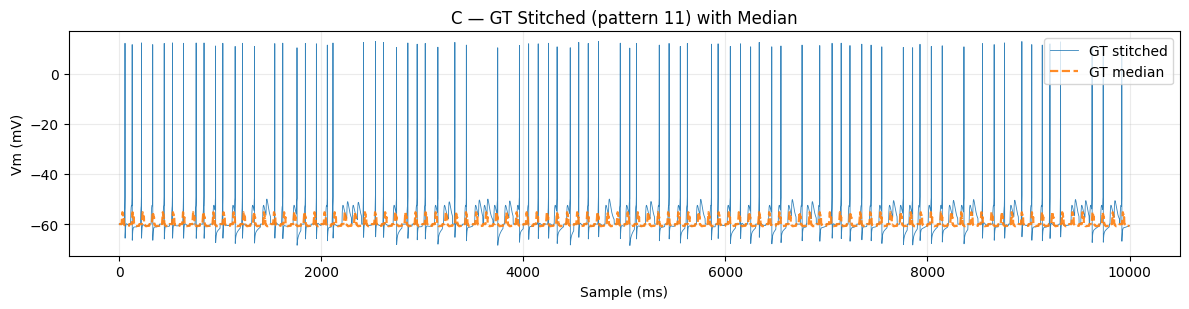

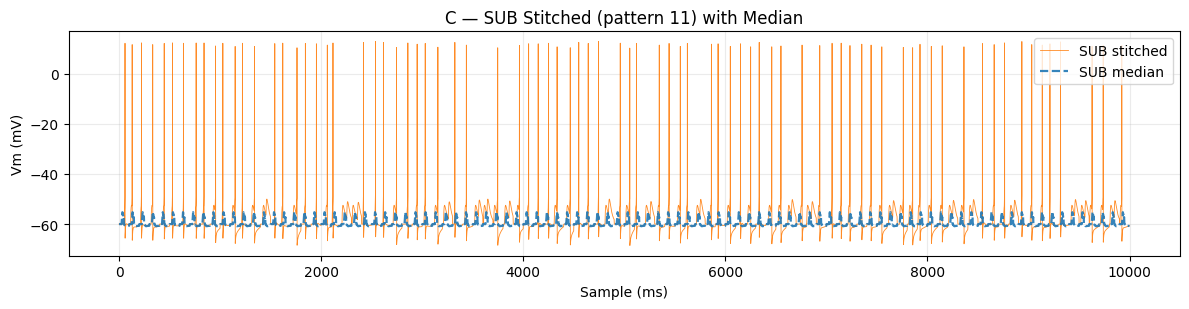

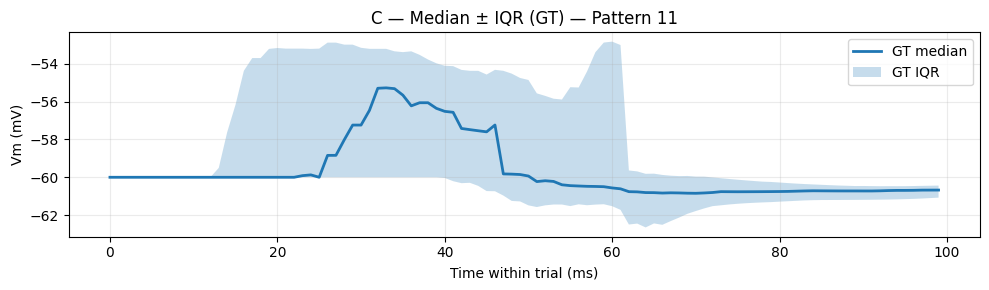

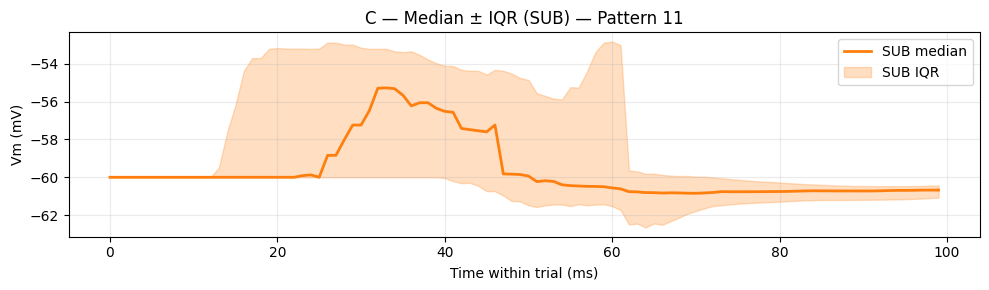

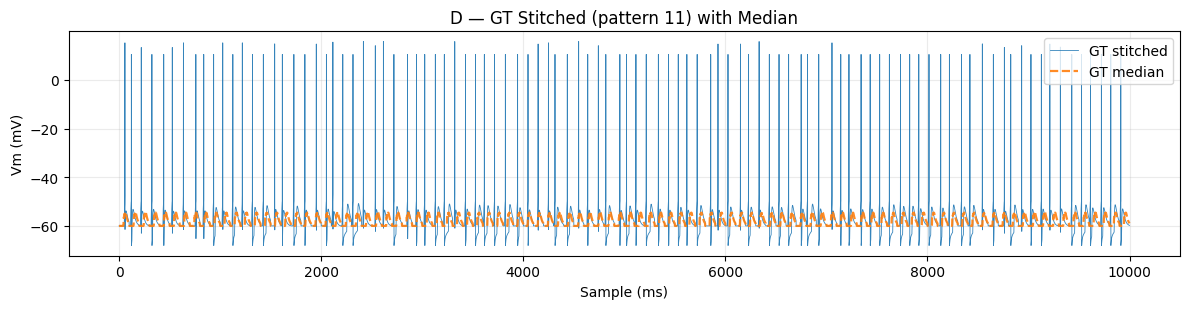

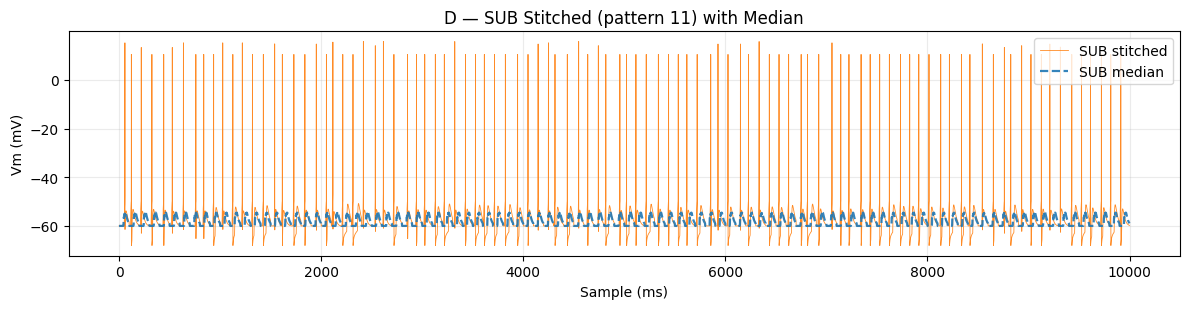

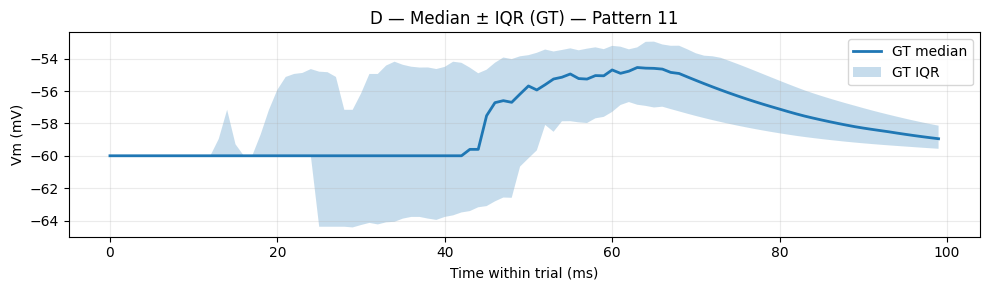

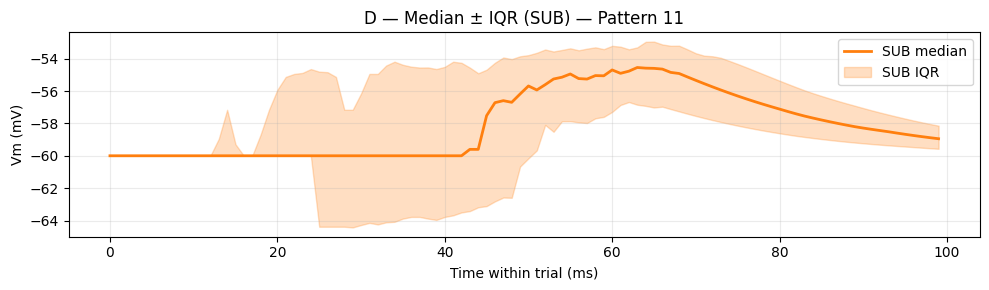

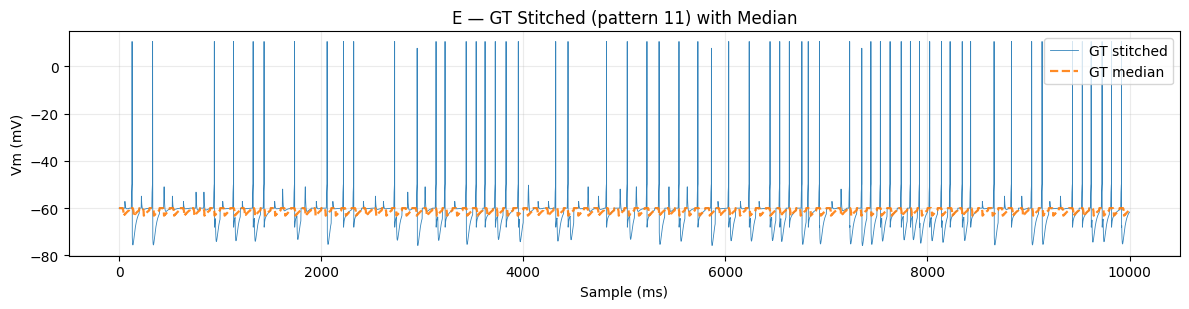

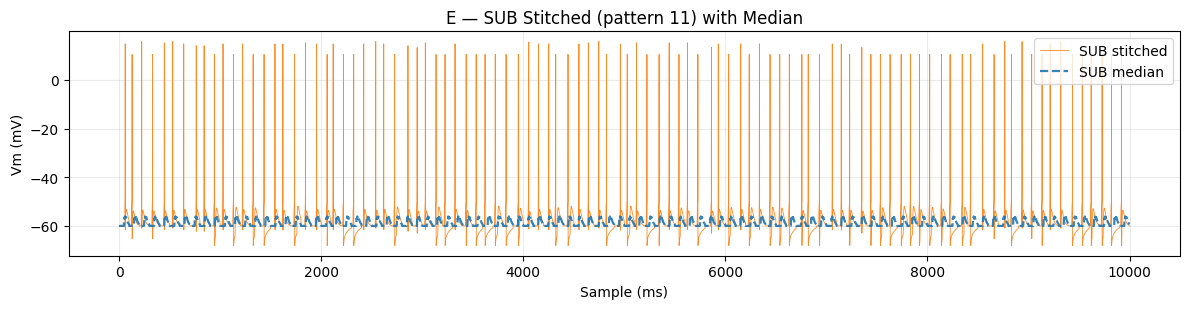

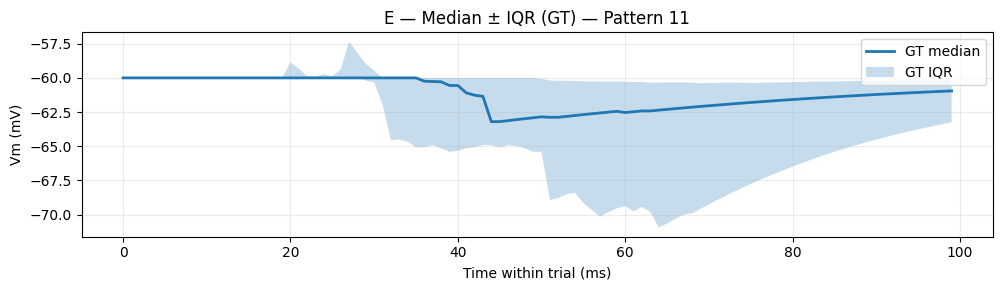

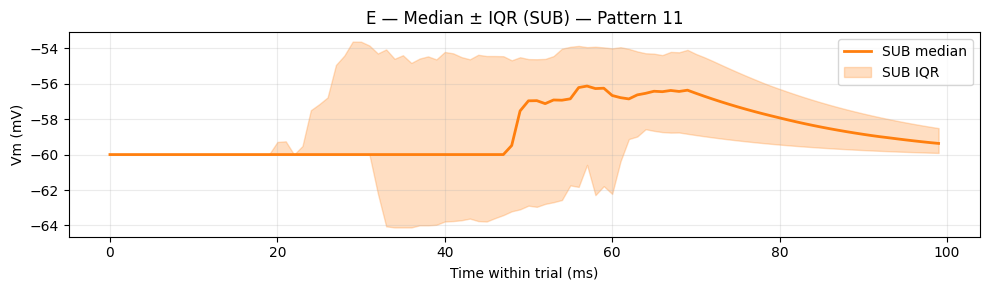

In [7]:
# Membrane Potential Visualization - Stitched Traces and Statistical Views
import numpy as np
import matplotlib.pyplot as plt

# Load preprocessed data
V = METRIC_VARS_NEW
GT_trials = V["gt"]["trials"]
SB_trials = V["sub"]["trials"]
GT_meta = V["gt"]["meta"]
SB_meta = V["sub"]["meta"]
VM_COLS = V["vm_cols"]  # Membrane potential columns
TRIAL_LEN = len(GT_trials[0]) if GT_trials else 100
PATTERNS = ("00", "01", "10", "11")

# Maximum trials to show in stitched view (None = all)
MAX_TRIALS_PER_PATTERN_STITCH = None

def _trial_ids(meta, patt):
    """Get trial indices for specified pattern."""
    return [i for i, m in enumerate(meta) if m.get("pattern") == patt]

def _common_trial_ids(patt):
    """Get trial indices present in both GT and SUB."""
    g = set(_trial_ids(GT_meta, patt))
    s = set(_trial_ids(SB_meta, patt))
    return sorted(g.intersection(s))

def _median_iqr_over_trials(trials, idxs, col):
    """
    Compute per-sample median and IQR across trials.
    Returns: (median, q25, q75) arrays of length TRIAL_LEN
    """
    if not idxs:
        return None, None, None

    mat = []
    for i in idxs:
        if i >= len(trials):
            continue
        vec = trials[i][col].to_numpy(float)
        if len(vec) >= TRIAL_LEN:
            mat.append(vec[:TRIAL_LEN])

    if not mat:
        return None, None, None

    M = np.vstack(mat)
    med = np.nanmedian(M, axis=0)
    q25 = np.nanpercentile(M, 25, axis=0)
    q75 = np.nanpercentile(M, 75, axis=0)
    return med, q25, q75

def _stitch_series(trials, idxs, col, max_trials=None):
    """
    Concatenate trials end-to-end.
    Returns: (stitched_y, time_axis)
    """
    if not idxs:
        return np.array([]), np.array([])

    use = idxs if (max_trials is None) else idxs[:max_trials]
    chunks = []
    for i in use:
        vec = trials[i][col].to_numpy(float)[:TRIAL_LEN]
        chunks.append(vec)

    if not chunks:
        return np.array([]), np.array([])

    y = np.concatenate(chunks)
    t = np.arange(y.size, dtype=float)
    return y, t

def _neuron_label(col):
    """Extract neuron name from column."""
    return col.replace("_membrane_potential", "")

# Generate visualizations for each pattern and neuron
for patt in PATTERNS:
    common_ids = _common_trial_ids(patt)

    for col in VM_COLS:
        neuron = _neuron_label(col)

        # Compute statistics
        med_gt, q25_gt, q75_gt = _median_iqr_over_trials(GT_trials, common_ids, col)
        med_sub, q25_sub, q75_sub = _median_iqr_over_trials(SB_trials, common_ids, col)

        # Figure 1: GT stitched with median overlay
        y_gt, t_gt = _stitch_series(GT_trials, common_ids, col, MAX_TRIALS_PER_PATTERN_STITCH)
        fig, ax = plt.subplots(figsize=(12, 3.2))

        if y_gt.size:
            ax.plot(t_gt, y_gt, lw=0.6, label="GT stitched", alpha=0.9)

        if med_gt is not None:
            reps = int(np.ceil(max(1, y_gt.size) / TRIAL_LEN))
            med_tile = np.tile(med_gt, reps)[:max(1, y_gt.size)]
            ax.plot(np.arange(med_tile.size), med_tile, lw=1.6, linestyle="--",
                   label="GT median", alpha=0.9)

        ax.set_title(f"{neuron} — GT Stitched (pattern {patt}) with Median")
        ax.set_xlabel("Sample (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        # Figure 2: SUB stitched with median overlay
        y_sub, t_sub = _stitch_series(SB_trials, common_ids, col, MAX_TRIALS_PER_PATTERN_STITCH)
        fig, ax = plt.subplots(figsize=(12, 3.2))

        if y_sub.size:
            ax.plot(t_sub, y_sub, lw=0.6, color="tab:orange", label="SUB stitched", alpha=0.9)

        if med_sub is not None:
            reps = int(np.ceil(max(1, y_sub.size) / TRIAL_LEN))
            med_tile = np.tile(med_sub, reps)[:max(1, y_sub.size)]
            ax.plot(np.arange(med_tile.size), med_tile, lw=1.6, linestyle="--",
                   color="tab:blue", label="SUB median", alpha=0.9)

        ax.set_title(f"{neuron} — SUB Stitched (pattern {patt}) with Median")
        ax.set_xlabel("Sample (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        # Figure 3: GT Median ± IQR
        x = np.arange(TRIAL_LEN)
        fig, ax = plt.subplots(figsize=(10, 3.0))

        if med_gt is not None:
            ax.plot(x, med_gt, lw=2.0, label="GT median")
            if (q25_gt is not None) and (q75_gt is not None):
                ax.fill_between(x, q25_gt, q75_gt, alpha=0.25, label="GT IQR")

        ax.set_title(f"{neuron} — Median ± IQR (GT) — Pattern {patt}")
        ax.set_xlabel("Time within trial (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        # Figure 4: SUB Median ± IQR
        fig, ax = plt.subplots(figsize=(10, 3.0))

        if med_sub is not None:
            ax.plot(x, med_sub, lw=2.0, color="tab:orange", label="SUB median")
            if (q25_sub is not None) and (q75_sub is not None):
                ax.fill_between(x, q25_sub, q75_sub, alpha=0.25, color="tab:orange", label="SUB IQR")

        ax.set_title(f"{neuron} — Median ± IQR (SUB) — Pattern {patt}")
        ax.set_xlabel("Time within trial (ms)")
        ax.set_ylabel("Vm (mV)")
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

## PSP

In [8]:
# PSP Counts Metric - Peak detection in membrane potentials
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# Load preprocessed data
V = METRIC_VARS_NEW
GT_trials = V["gt"]["trials"]
SB_trials = V["sub"]["trials"]
GT_meta = V["gt"]["meta"]
SB_meta = V["sub"]["meta"]
VM_COLS = V["vm_cols"]
TRIAL_LEN = len(GT_trials[0]) if GT_trials else 100
PATTERNS = ("00", "01", "10", "11")
RESP_LO_MS = int(V["behavior_params"]["RESP_WINDOW_LO_MS"])
RESP_HI_MS = int(V["behavior_params"]["RESP_WINDOW_HI_MS"])

# Detection parameters
PEAK_PROMINENCE = 0.5        # mV threshold for PSP detection
MIN_PEAK_DISTANCE_MS = 2     # Minimum distance between peaks
BASELINE_PRE_MS = 10         # Baseline window before input
CLIP_TO_RESP_WINDOW = True   # Count only within response window

def _earliest_anchor(m):
    """Get earliest input time."""
    a, b = m.get("a_time"), m.get("b_time")
    if a is None and b is None:
        return None
    return min([t for t in (a, b) if t is not None])

def _resp_window_safe(m):
    """Get response window with fallbacks."""
    rw = m.get("response_window")
    if (rw is None) or (rw[1] < rw[0]):
        anc = _earliest_anchor(m)
        if anc is None:
            return 0, TRIAL_LEN - 1
        return max(0, anc + RESP_LO_MS), min(TRIAL_LEN - 1, anc + RESP_HI_MS)
    lo, hi = int(rw[0]), int(rw[1])
    return max(0, lo), min(TRIAL_LEN - 1, hi)

def _baseline_subtracted(vec, m, pre_ms=BASELINE_PRE_MS):
    """Subtract baseline from membrane potential."""
    v = np.asarray(vec, float)
    anc = _earliest_anchor(m)
    if anc is None:
        s, e = 0, min(TRIAL_LEN - 1, pre_ms)
    else:
        s, e = max(0, int(anc - pre_ms)), max(0, int(anc - 1))

    if e <= s:
        base = float(np.nanmedian(v[:max(1, pre_ms)]))
    else:
        base = float(np.nanmedian(v[s:e+1]))
    return v - base

def _detect_psp_counts(v0, lo, hi):
    """Detect EPSP and IPSP peaks in window."""
    v = np.asarray(v0, float)
    use_lo = int(max(0, lo)) if CLIP_TO_RESP_WINDOW else 0
    use_hi = int(min(len(v)-1, hi)) if CLIP_TO_RESP_WINDOW else len(v)-1

    if use_hi < use_lo:
        return 0, 0

    seg = v[use_lo:use_hi+1]
    p_up, _ = find_peaks(seg, prominence=PEAK_PROMINENCE, distance=max(1, int(MIN_PEAK_DISTANCE_MS)))
    p_down, _ = find_peaks(-seg, prominence=PEAK_PROMINENCE, distance=max(1, int(MIN_PEAK_DISTANCE_MS)))

    return int(p_up.size), int(p_down.size)

def _ids_by_pattern(meta, patt):
    """Get trial indices for pattern."""
    return [i for i, m in enumerate(meta) if m.get("pattern") == patt]

def _common_ids(patt):
    """Get trial indices present in both GT and SUB."""
    return sorted(set(_ids_by_pattern(GT_meta, patt)).intersection(_ids_by_pattern(SB_meta, patt)))

# Build counts table
rows_counts = []
for patt in PATTERNS:
    ids = _common_ids(patt)
    if not ids:
        continue

    for col in VM_COLS:
        epsp_gt = ipsp_gt = epsp_sb = ipsp_sb = 0

        for i in ids:
            # GT
            m = GT_meta[i]
            lo, hi = _resp_window_safe(m)
            vbs = _baseline_subtracted(GT_trials[i][col].to_numpy(float), m)
            n_up, n_dn = _detect_psp_counts(vbs, lo, hi)
            epsp_gt += n_up
            ipsp_gt += n_dn

            # SUB
            m2 = SB_meta[i]
            lo2, hi2 = _resp_window_safe(m2)
            vbs2 = _baseline_subtracted(SB_trials[i][col].to_numpy(float), m2)
            n_up2, n_dn2 = _detect_psp_counts(vbs2, lo2, hi2)
            epsp_sb += n_up2
            ipsp_sb += n_dn2

        rows_counts.append(dict(
            pattern=patt,
            neuron=col.replace("_membrane_potential", ""),
            n_trials=len(ids),
            EPSP_GT=epsp_gt, EPSP_SUB=epsp_sb,
            IPSP_GT=ipsp_gt, IPSP_SUB=ipsp_sb
        ))

PSP_COUNTS = pd.DataFrame(rows_counts).sort_values(["pattern", "neuron"]).reset_index(drop=True)

# Print formatted table
def print_psp_counts_by_pattern(df):
    """Display PSP counts with pattern separators."""
    df = df.sort_values(["pattern", "neuron", "n_trials"]).reset_index(drop=True)
    pat_groups = list(df.groupby("pattern", sort=False))

    header_cols = ["pattern", "neuron", "n_trials", "EPSP_GT", "EPSP_SUB", "IPSP_GT", "IPSP_SUB"]
    header = " ".join(f"{c:>12}" if c != "neuron" else f"{c:>8}" for c in header_cols)
    sep = "-" * max(88, len(header))

    print("\n=== PSP — Counts (GT vs SUB, per pattern × neuron) ===")
    print(header)
    print(sep)

    for idx, (patt, g) in enumerate(pat_groups):
        for _, r in g[header_cols].iterrows():
            print(f"{str(r['pattern']):>12} "
                  f"{str(r['neuron']):>8} "
                  f"{int(r['n_trials']):>12d} "
                  f"{int(r['EPSP_GT']):>12d} {int(r['EPSP_SUB']):>11d} "
                  f"{int(r['IPSP_GT']):>12d} {int(r['IPSP_SUB']):>11d}")
        if idx < len(pat_groups) - 1:
            print(sep)

print_psp_counts_by_pattern(PSP_COUNTS)

# Bundle results
PSP_RESULTS_COUNTS_ONLY = dict(
    counts=PSP_COUNTS.copy(),
    config=dict(
        PEAK_PROMINENCE=PEAK_PROMINENCE,
        MIN_PEAK_DISTANCE_MS=MIN_PEAK_DISTANCE_MS,
        BASELINE_PRE_MS=BASELINE_PRE_MS,
        CLIP_TO_RESP_WINDOW=CLIP_TO_RESP_WINDOW,
        RESP_LO_MS=RESP_LO_MS,
        RESP_HI_MS=RESP_HI_MS
    )
)


=== PSP — Counts (GT vs SUB, per pattern × neuron) ===
     pattern   neuron     n_trials      EPSP_GT     EPSP_SUB      IPSP_GT     IPSP_SUB
----------------------------------------------------------------------------------------
          00        A          100            0           0            0           0
          00        B          100            0           0            0           0
          00        C          100            0           0            0           0
          00        D          100            0           0            0           0
          00        E          100            0           0            0           0
----------------------------------------------------------------------------------------
          01        A          100            0           0            0           0
          01        B          100            0           0            0           0
          01        C          100          100         100            0           0

## Mempot zoom

=== Membrane Potential — Mismatch (Pattern Worst Trial) ===
pattern  trial_id    Neuron_VM (worst)  Best RMS Δ (mV)  Peak |Δ| (mV) Window (ms)
     11       397 E_membrane_potential          10.3083        21.3994    0.0–99.0

=== Membrane Potential — Mismatch (Best Across Trials per Neuron) ===
           Neuron_VM  Best RMS Δ (mV)  Peak |Δ| (mV) pattern  trial_id Window (ms)
A_membrane_potential           0.0000         0.0000    None       NaN            
B_membrane_potential           0.0000         0.0000    None       NaN            
C_membrane_potential           0.0000         0.0000    None       NaN            
D_membrane_potential           0.0000         0.0000    None       NaN            
E_membrane_potential          10.3083        21.3994      11     397.0    0.0–99.0

[vm-plot] pattern 11: plotting 1 table-selected trial(s)


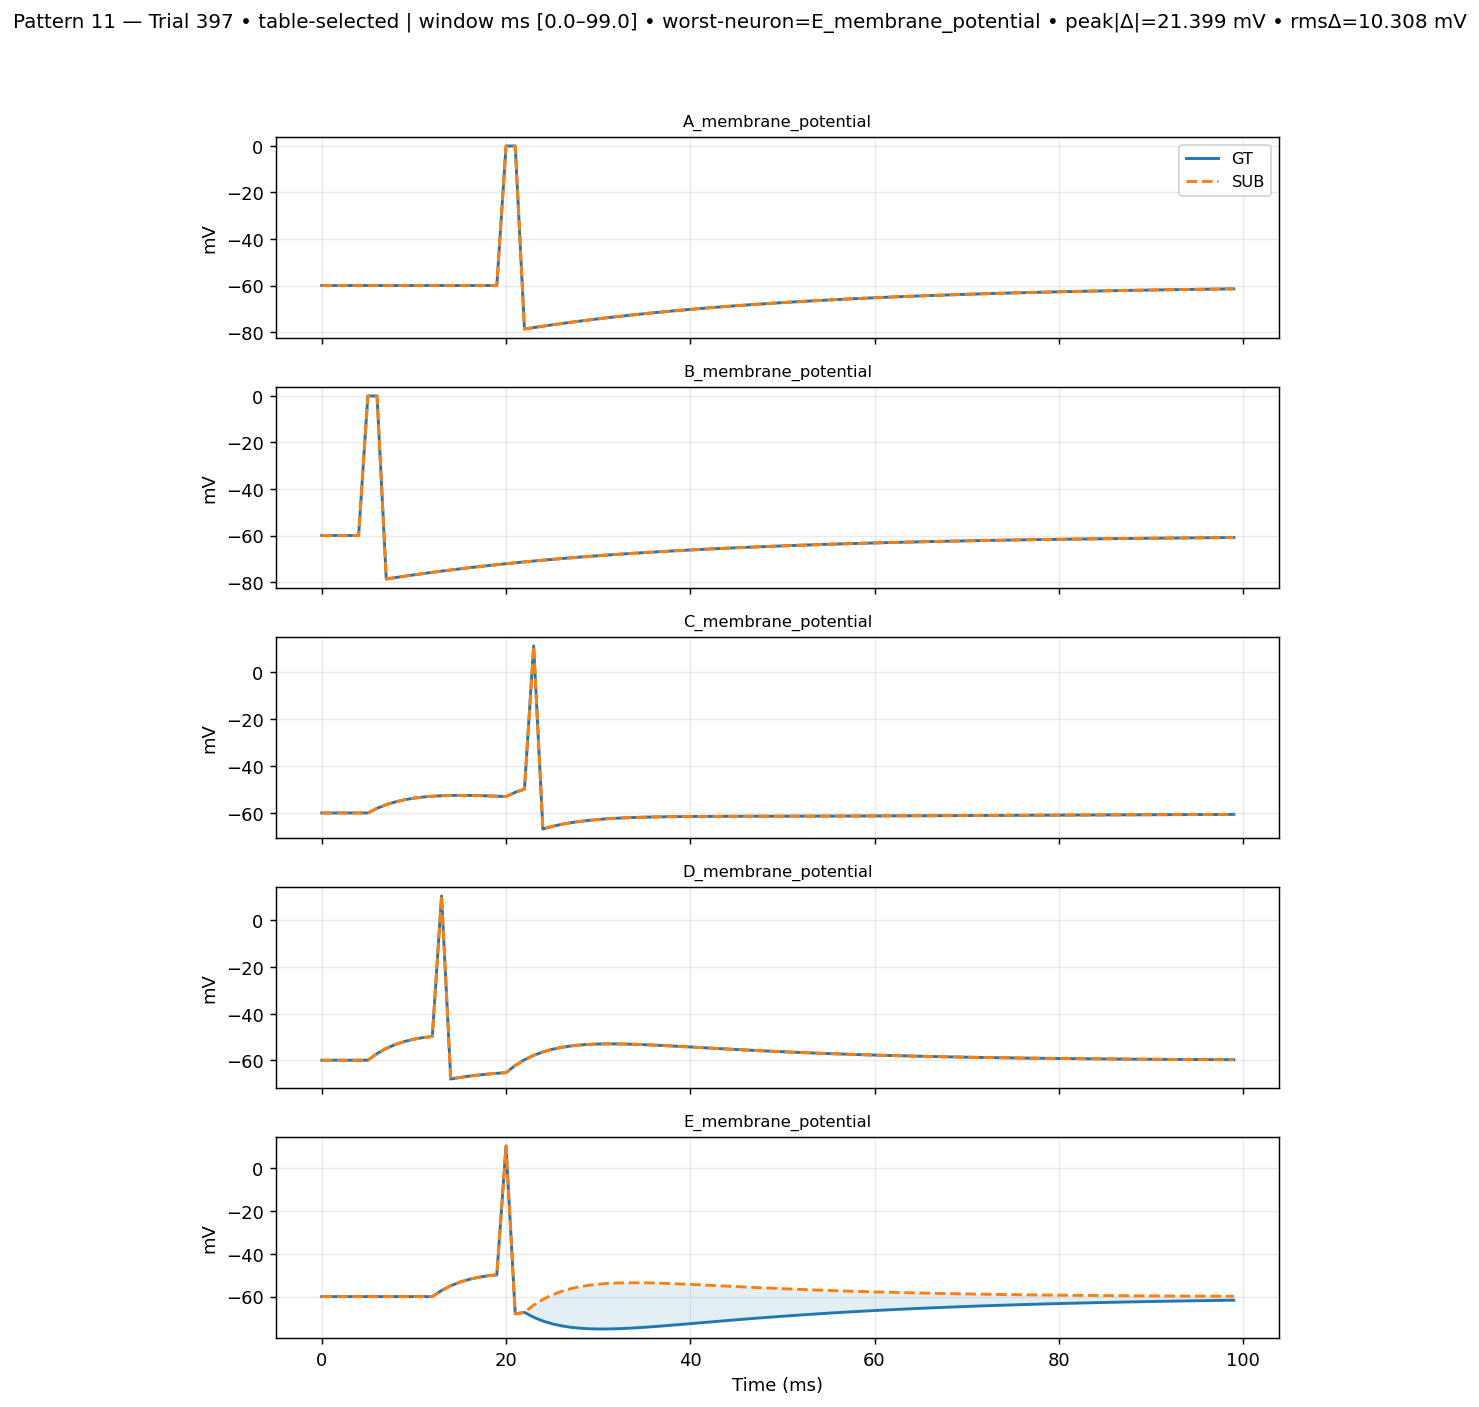

In [9]:
# VM Mismatch Metric - Membrane potential comparison and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_tables_then_plot(V, dpi=130, verbose=True):
    """Compute mismatch metrics and plot worst trials."""
    GT_TRIALS = V["gt"]["trials"]
    SB_TRIALS = V["sub"]["trials"]
    GT_META = V["gt"]["meta"]
    SB_META = V["sub"]["meta"]
    VM_COLS = list(V["vm_cols"])
    PATTERNS = ("00", "01", "10", "11")

    if len(GT_TRIALS) != len(SB_TRIALS):
        raise ValueError("GT_TRIALS and SB_TRIALS must have the same length.")
    N = len(GT_TRIALS)
    if not N:
        raise ValueError("No trials provided.")

    # Infer sampling rate
    def _infer_fs_hz():
        if "fs_hz" in V and V["fs_hz"]:
            return float(V["fs_hz"])
        if GT_TRIALS and ("time" in GT_TRIALS[0].columns):
            t = GT_TRIALS[0]["time"].to_numpy(dtype=float)
            if t.size >= 2:
                dt = float(np.median(np.diff(t)))
                if 0.2 <= dt <= 5.0:  # time in ms
                    return 1000.0 / dt
                return 1.0 / dt if dt > 0 else 1000.0
        return 1000.0

    FS_HZ = _infer_fs_hz()
    MS_PER_SAMPLE = 1000.0 / FS_HZ

    def _common_ids_for_pattern(patt):
        """Get common trial indices for pattern."""
        gt_ids = {i for i, m in enumerate(GT_META) if str(m.get("pattern")) == patt}
        sb_ids = {i for i, m in enumerate(SB_META) if str(m.get("pattern")) == patt}
        return sorted(gt_ids.intersection(sb_ids))

    def _trial_full_stats(gt_df, sb_df, vm_cols):
        """Compute full-trial mismatch statistics."""
        n = min(len(gt_df), len(sb_df))
        if n == 0:
            return {"neuron_col": None, "rms": 0.0, "peak": 0.0, "win_str": ""}

        if "time" in gt_df.columns:
            t = gt_df["time"].to_numpy(dtype=float)[:n]
            win_str = f"{t[0]:.1f}–{t[-1]:.1f}"
        else:
            win_str = f"0.0–{(n-1)*MS_PER_SAMPLE:.1f}"

        best_col, best_rms, best_peak = None, 0.0, 0.0
        for col in vm_cols:
            if (col not in gt_df.columns) or (col not in sb_df.columns):
                continue
            g = gt_df[col].to_numpy(dtype=float)[:n]
            s = sb_df[col].to_numpy(dtype=float)[:n]
            d = g - s
            if d.size == 0:
                continue
            rms = float(np.sqrt(np.nanmean(d * d)))
            peak = float(np.nanmax(np.abs(d)))
            if rms > best_rms:
                best_rms = rms
                best_peak = peak
                best_col = col

        return {"neuron_col": best_col, "rms": best_rms, "peak": best_peak, "win_str": win_str}

    def _pattern_of_trial(idx):
        """Get pattern for trial index."""
        p = GT_META[idx].get("pattern", None)
        if p is None:
            p = SB_META[idx].get("pattern", None)
        return str(p) if p is not None else None

    # Table 1: Worst trial per pattern
    p_rows = []
    for patt in PATTERNS:
        ids = _common_ids_for_pattern(patt)
        if not ids:
            continue
        scored = []
        for i in ids:
            s = _trial_full_stats(GT_TRIALS[i], SB_TRIALS[i], VM_COLS)
            if s["neuron_col"] is None:
                continue
            scored.append((i, s))
        if not scored:
            continue
        trial_id, stat = max(scored, key=lambda x: x[1]["rms"])
        p_rows.append({
            "pattern": patt,
            "trial_id": int(trial_id),
            "Neuron_VM (worst)": stat["neuron_col"],
            "Best RMS Δ (mV)": float(stat["rms"]),
            "Peak |Δ| (mV)": float(stat["peak"]),
            "Window (ms)": stat["win_str"],
        })

    pattern_worst_table = pd.DataFrame(p_rows, columns=[
        "pattern", "trial_id", "Neuron_VM (worst)", "Best RMS Δ (mV)", "Peak |Δ| (mV)", "Window (ms)"
    ])

    # Table 2: Worst trial per neuron across all trials
    n_rows = []
    for col in VM_COLS:
        best = {"trial": None, "patt": None, "rms": 0.0, "peak": 0.0, "win": ""}
        for i in range(N):
            gt_df, sb_df = GT_TRIALS[i], SB_TRIALS[i]
            if (col not in gt_df.columns) or (col not in sb_df.columns):
                continue
            stat = _trial_full_stats(gt_df, sb_df, [col])
            if stat["neuron_col"] is None:
                continue
            if stat["rms"] > best["rms"]:
                best.update({
                    "trial": i,
                    "patt": _pattern_of_trial(i),
                    "rms": float(stat["rms"]),
                    "peak": float(stat["peak"]),
                    "win": stat["win_str"]
                })

        if best["trial"] is None:
            n_rows.append({
                "Neuron_VM": col, "Best RMS Δ (mV)": 0.0, "Peak |Δ| (mV)": 0.0,
                "pattern": None, "trial_id": np.nan, "Window (ms)": ""
            })
        else:
            n_rows.append({
                "Neuron_VM": col, "Best RMS Δ (mV)": best["rms"], "Peak |Δ| (mV)": best["peak"],
                "pattern": best["patt"], "trial_id": int(best["trial"]), "Window (ms)": best["win"]
            })

    neuron_best_table = pd.DataFrame(n_rows, columns=[
        "Neuron_VM", "Best RMS Δ (mV)", "Peak |Δ| (mV)", "pattern", "trial_id", "Window (ms)"
    ])

    # Format floats
    def _fmt_float(x, nd=6):
        try:
            return float(f"{float(x):.{nd}g}")
        except:
            return x

    if not pattern_worst_table.empty:
        pattern_worst_table["Best RMS Δ (mV)"] = pattern_worst_table["Best RMS Δ (mV)"].map(lambda v: _fmt_float(v, 6))
        pattern_worst_table["Peak |Δ| (mV)"] = pattern_worst_table["Peak |Δ| (mV)"].map(lambda v: _fmt_float(v, 6))
        pattern_worst_table = pattern_worst_table.sort_values(["pattern"]).reset_index(drop=True)

    if not neuron_best_table.empty:
        neuron_best_table["Best RMS Δ (mV)"] = neuron_best_table["Best RMS Δ (mV)"].map(lambda v: _fmt_float(v, 6))
        neuron_best_table["Peak |Δ| (mV)"] = neuron_best_table["Peak |Δ| (mV)"].map(lambda v: _fmt_float(v, 6))
        neuron_best_table = neuron_best_table.sort_values(["Neuron_VM"]).reset_index(drop=True)

    # Print tables
    print("=== Membrane Potential — Mismatch (Pattern Worst Trial) ===")
    if pattern_worst_table.empty:
        print("(none)")
    else:
        print(pattern_worst_table.to_string(index=False))

    print("\n=== Membrane Potential — Mismatch (Best Across Trials per Neuron) ===")
    if neuron_best_table.empty:
        print("(none)")
    else:
        print(neuron_best_table.to_string(index=False))

    # Plot referenced trials
    def _plot_trial_fullstack(gt_df, sb_df, patt, trial_id, title_note, vm_cols, dpi=130):
        """Plot all VM traces for a trial."""
        n = min(len(gt_df), len(sb_df))
        if n == 0:
            return

        if "time" in gt_df.columns:
            tt = gt_df["time"].to_numpy(dtype=float)[:n]
            ms0, ms1 = float(tt[0]), float(tt[-1])
            xlab = "Time (ms)"
        else:
            tt = np.arange(n, dtype=float) * MS_PER_SAMPLE
            ms0, ms1 = 0.0, (n - 1) * MS_PER_SAMPLE
            xlab = "Time (ms, inferred)"

        rows = len(vm_cols)
        fig_h = max(2.2 * rows, 3.2)
        fig, axs = plt.subplots(rows, 1, figsize=(8.6, fig_h), sharex=True, dpi=dpi)
        if rows == 1:
            axs = [axs]

        for ax, c in zip(axs, vm_cols):
            if (c not in gt_df.columns) or (c not in sb_df.columns):
                ax.axis("off")
                continue
            g = gt_df[c].to_numpy(dtype=float)[:n]
            s = sb_df[c].to_numpy(dtype=float)[:n]
            ax.plot(tt, g, lw=1.6, label="GT")
            ax.plot(tt, s, lw=1.6, ls="--", label="SUB")
            ax.fill_between(tt, g, s, alpha=0.12)
            ax.set_ylabel("mV")
            ax.set_title(c, fontsize=9)
            ax.grid(alpha=0.25)

        axs[-1].set_xlabel(xlab)
        fig.suptitle(
            f"Pattern {patt} — Trial {trial_id} • table-selected | window ms [{ms0:.1f}–{ms1:.1f}] • {title_note}",
            fontsize=11
        )
        axs[0].legend(loc="upper right", fontsize=9)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # Collect unique trials to plot
    to_plot = set()
    for df in (pattern_worst_table, neuron_best_table):
        if not df.empty:
            for _, r in df.iterrows():
                patt = r.get("pattern", None)
                tid = r.get("trial_id", None)
                if pd.notna(patt) and pd.notna(tid):
                    to_plot.add((str(patt), int(tid)))

    def _ids_for_pattern(patt):
        return set(_common_ids_for_pattern(patt))

    if not to_plot and verbose:
        print("\n[vm-plot] No valid trials in tables — nothing to plot.")
    else:
        grouped = {}
        for patt, tid in to_plot:
            grouped.setdefault(patt, set()).add(tid)

        for patt, tids in sorted(grouped.items()):
            common = _ids_for_pattern(patt)
            valid_ids = [tid for tid in sorted(tids) if tid in common]
            if not valid_ids:
                if verbose:
                    print(f"\n[vm-plot] pattern {patt}: no valid table-selected trials — skipped.")
                continue

            if verbose:
                print(f"\n[vm-plot] pattern {patt}: plotting {len(valid_ids)} table-selected trial(s)")
            for tid in valid_ids:
                stat = _trial_full_stats(GT_TRIALS[tid], SB_TRIALS[tid], VM_COLS)
                note = f"worst-neuron={stat['neuron_col']} • peak|Δ|={stat['peak']:.3f} mV • rmsΔ={stat['rms']:.3f} mV"
                _plot_trial_fullstack(GT_TRIALS[tid], SB_TRIALS[tid], patt, tid, note, VM_COLS, dpi=dpi)

    return {"pattern_worst_table": pattern_worst_table, "neuron_best_table": neuron_best_table}

# Execute
out = build_tables_then_plot(METRIC_VARS_NEW, dpi=130, verbose=True)

## Cross corr


=== CCG (old-report style) — Mean zero-lag summary ===
Pattern  MeanZeroLag_GT  MeanZeroLag_SUB  Delta_SUB_minus_GT
     00        0.000000         0.000000                 0.0
     01        0.000000         0.000000                 0.0
     10        0.000000         0.000000                 0.0
     11        0.000316         0.000316                 0.0


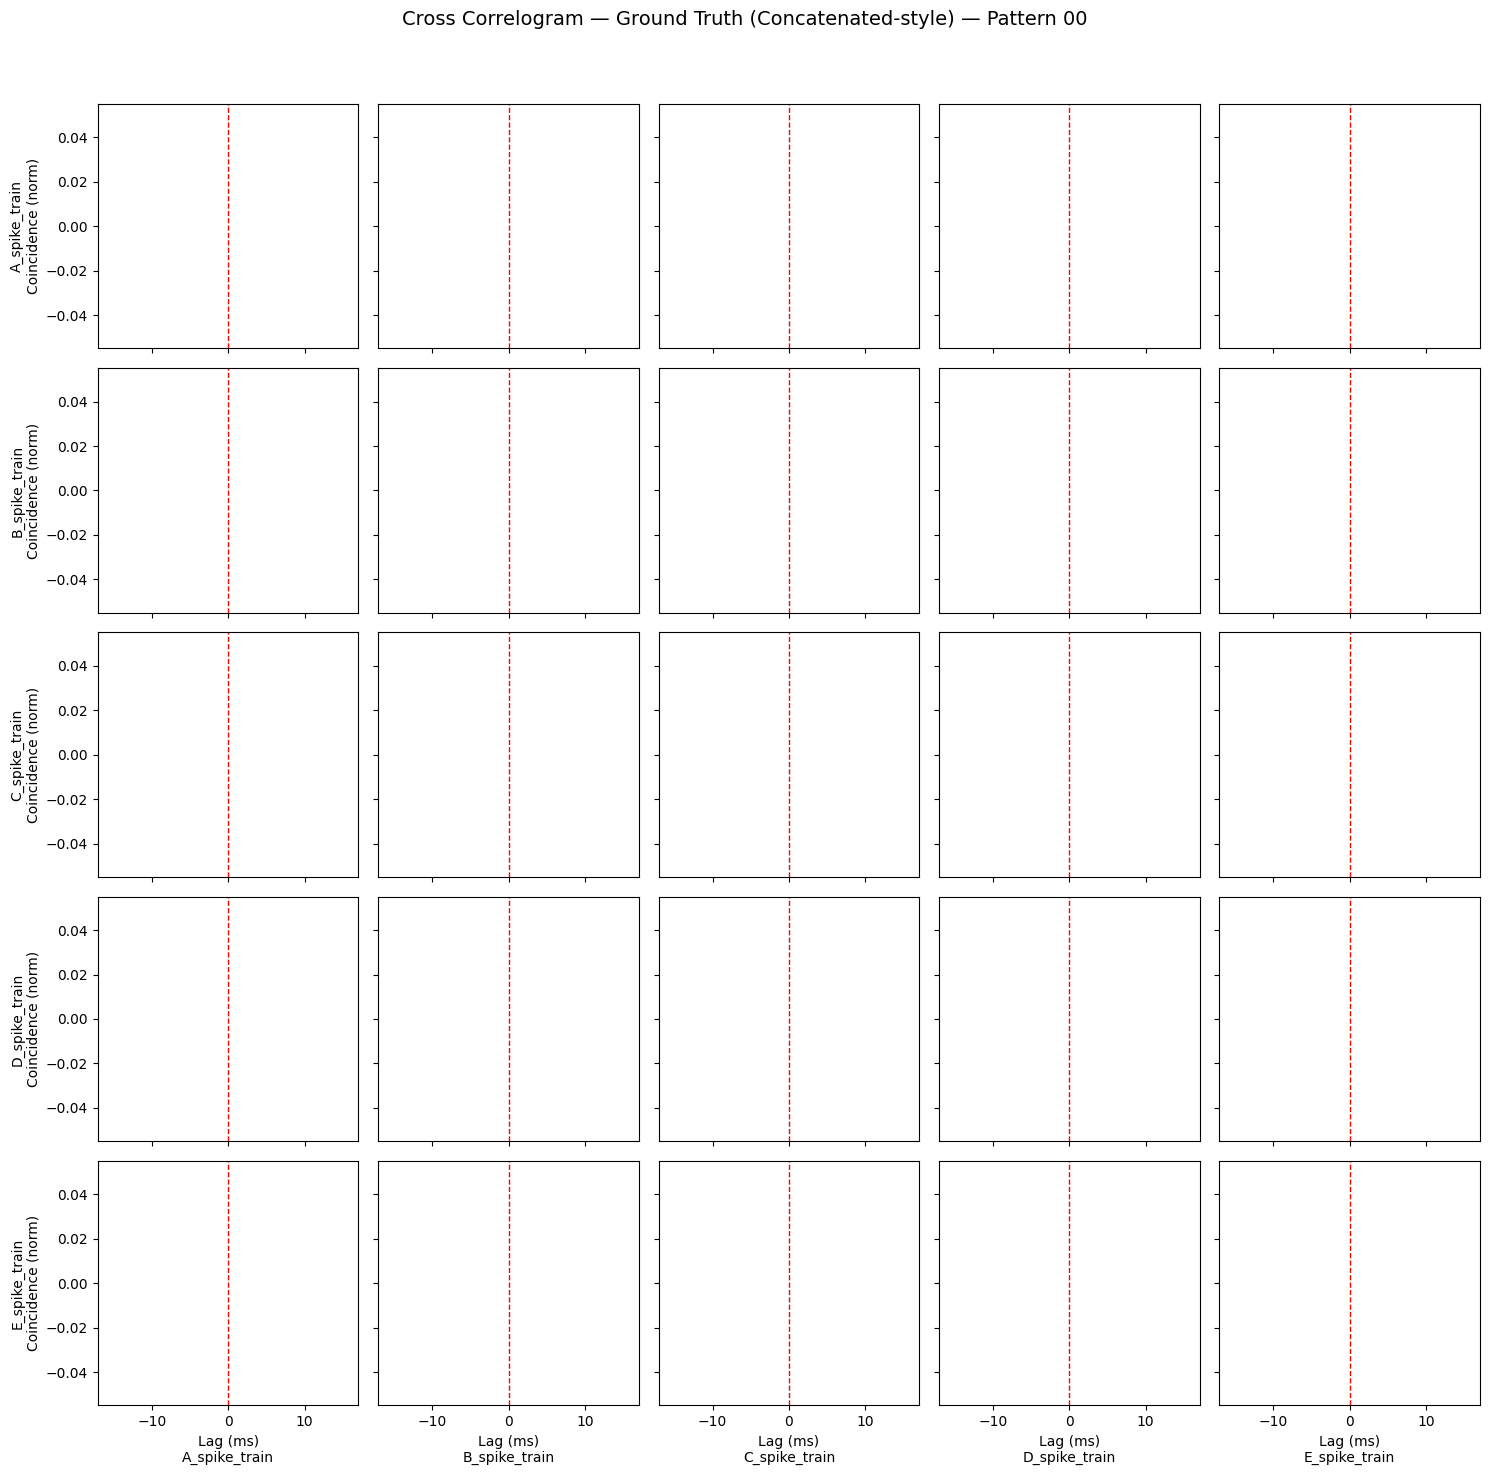

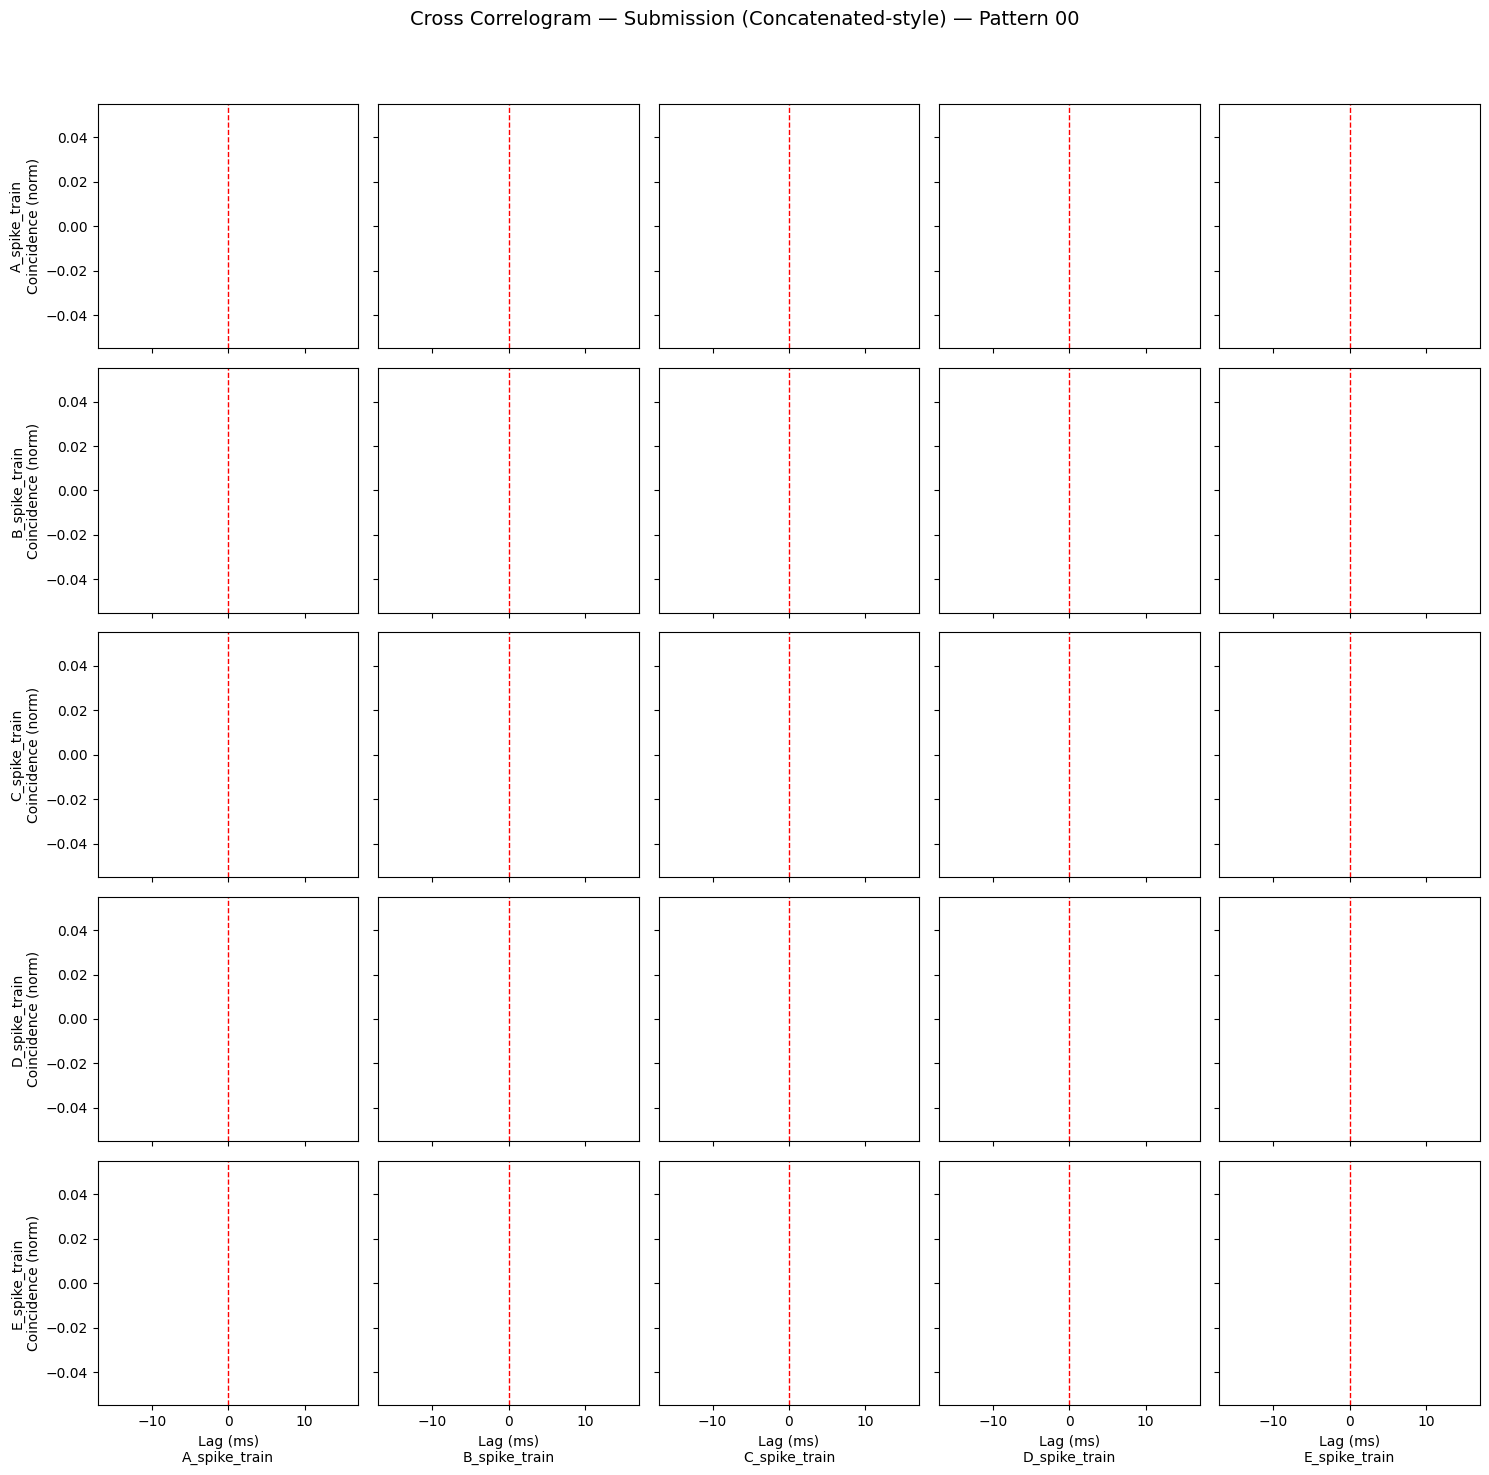

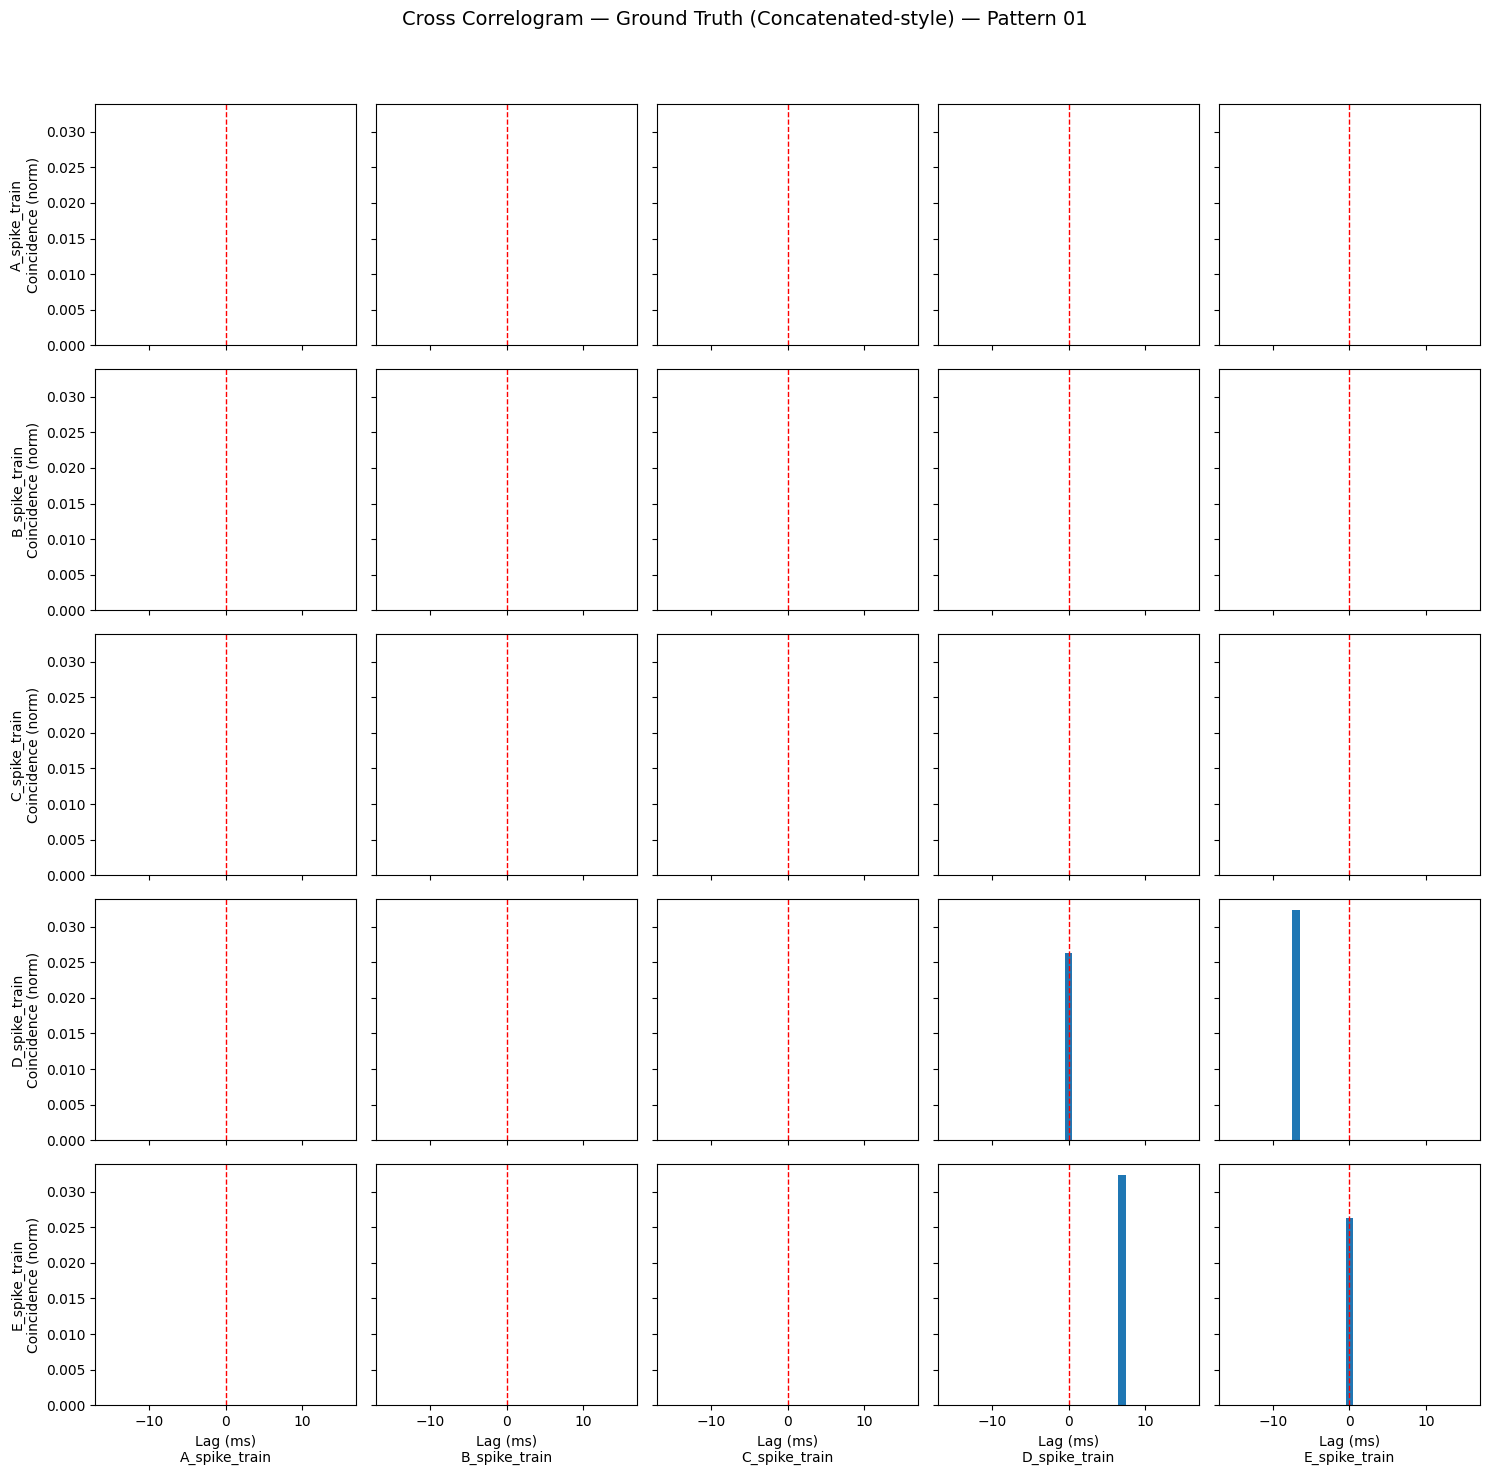

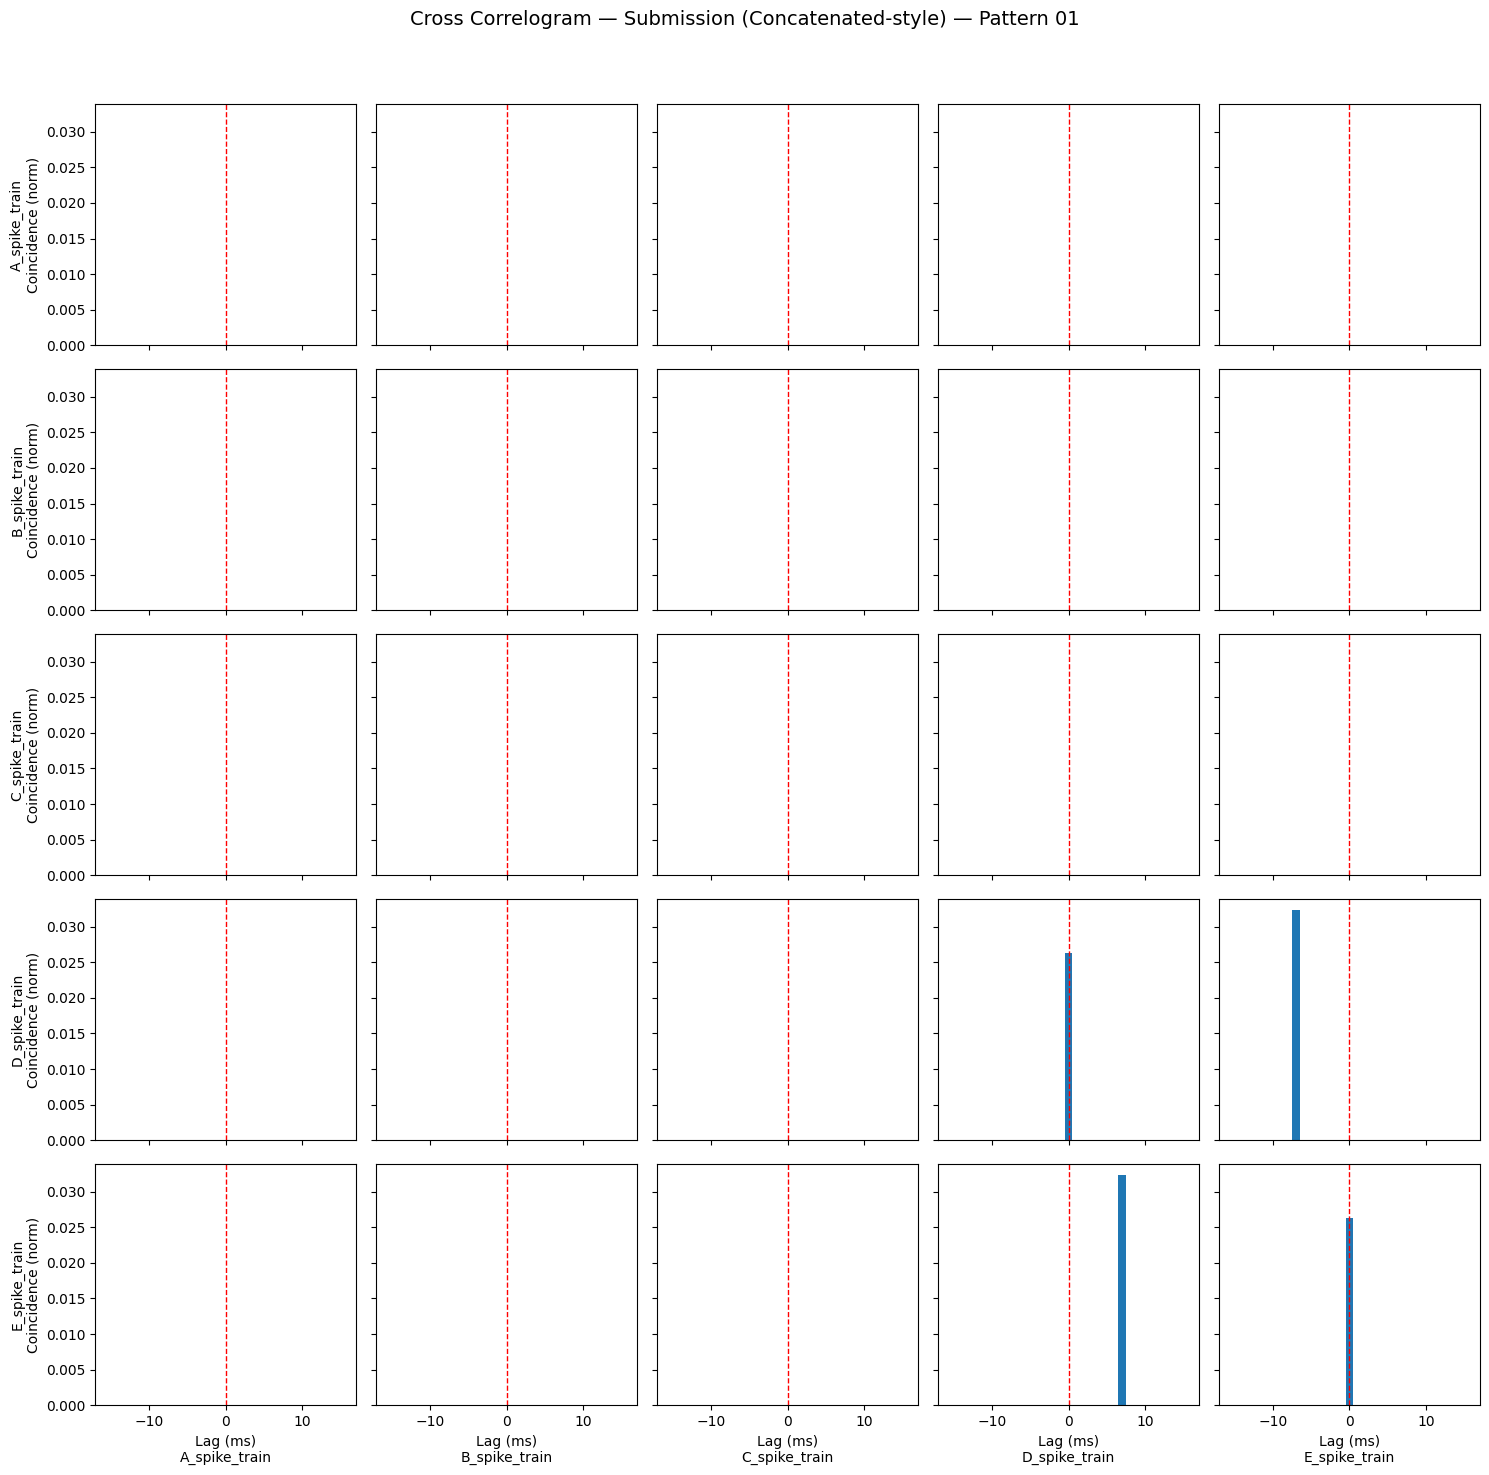

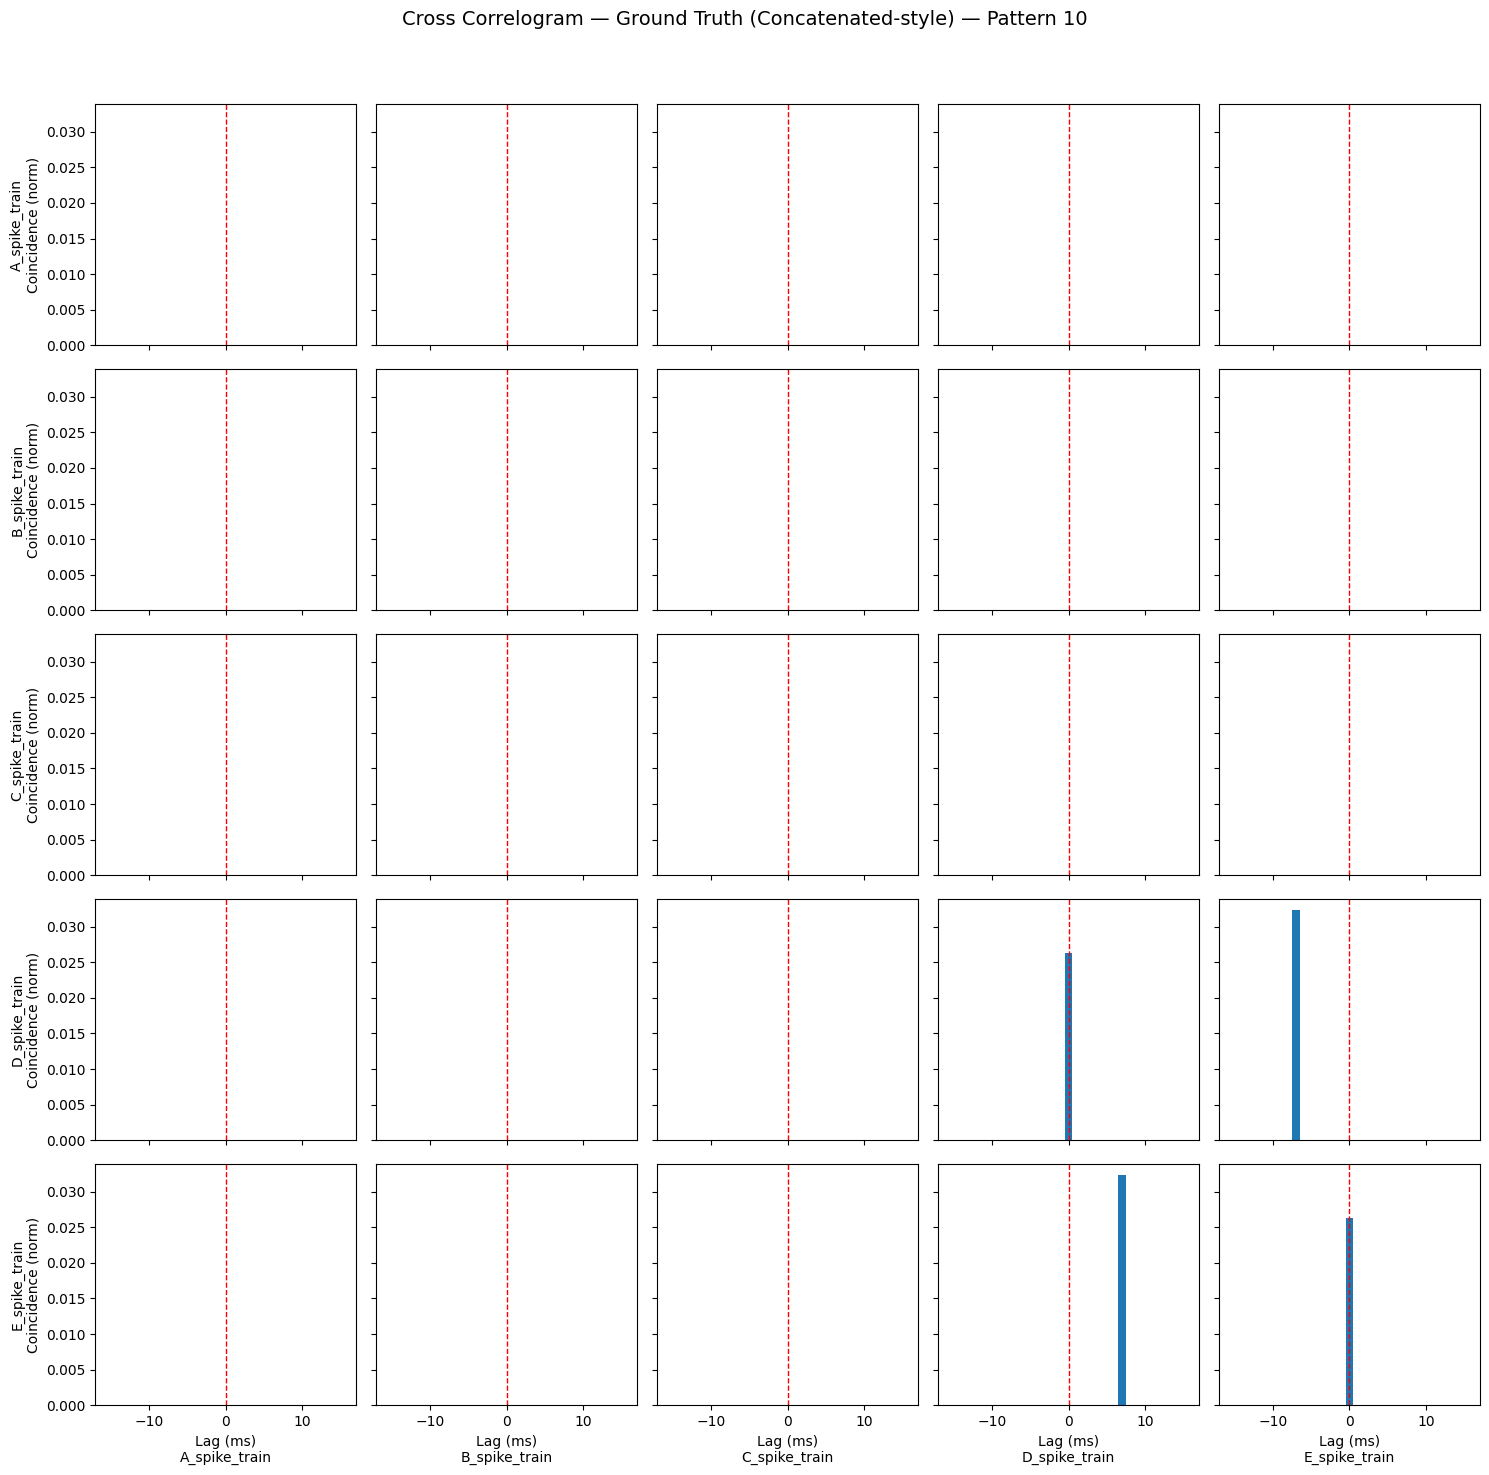

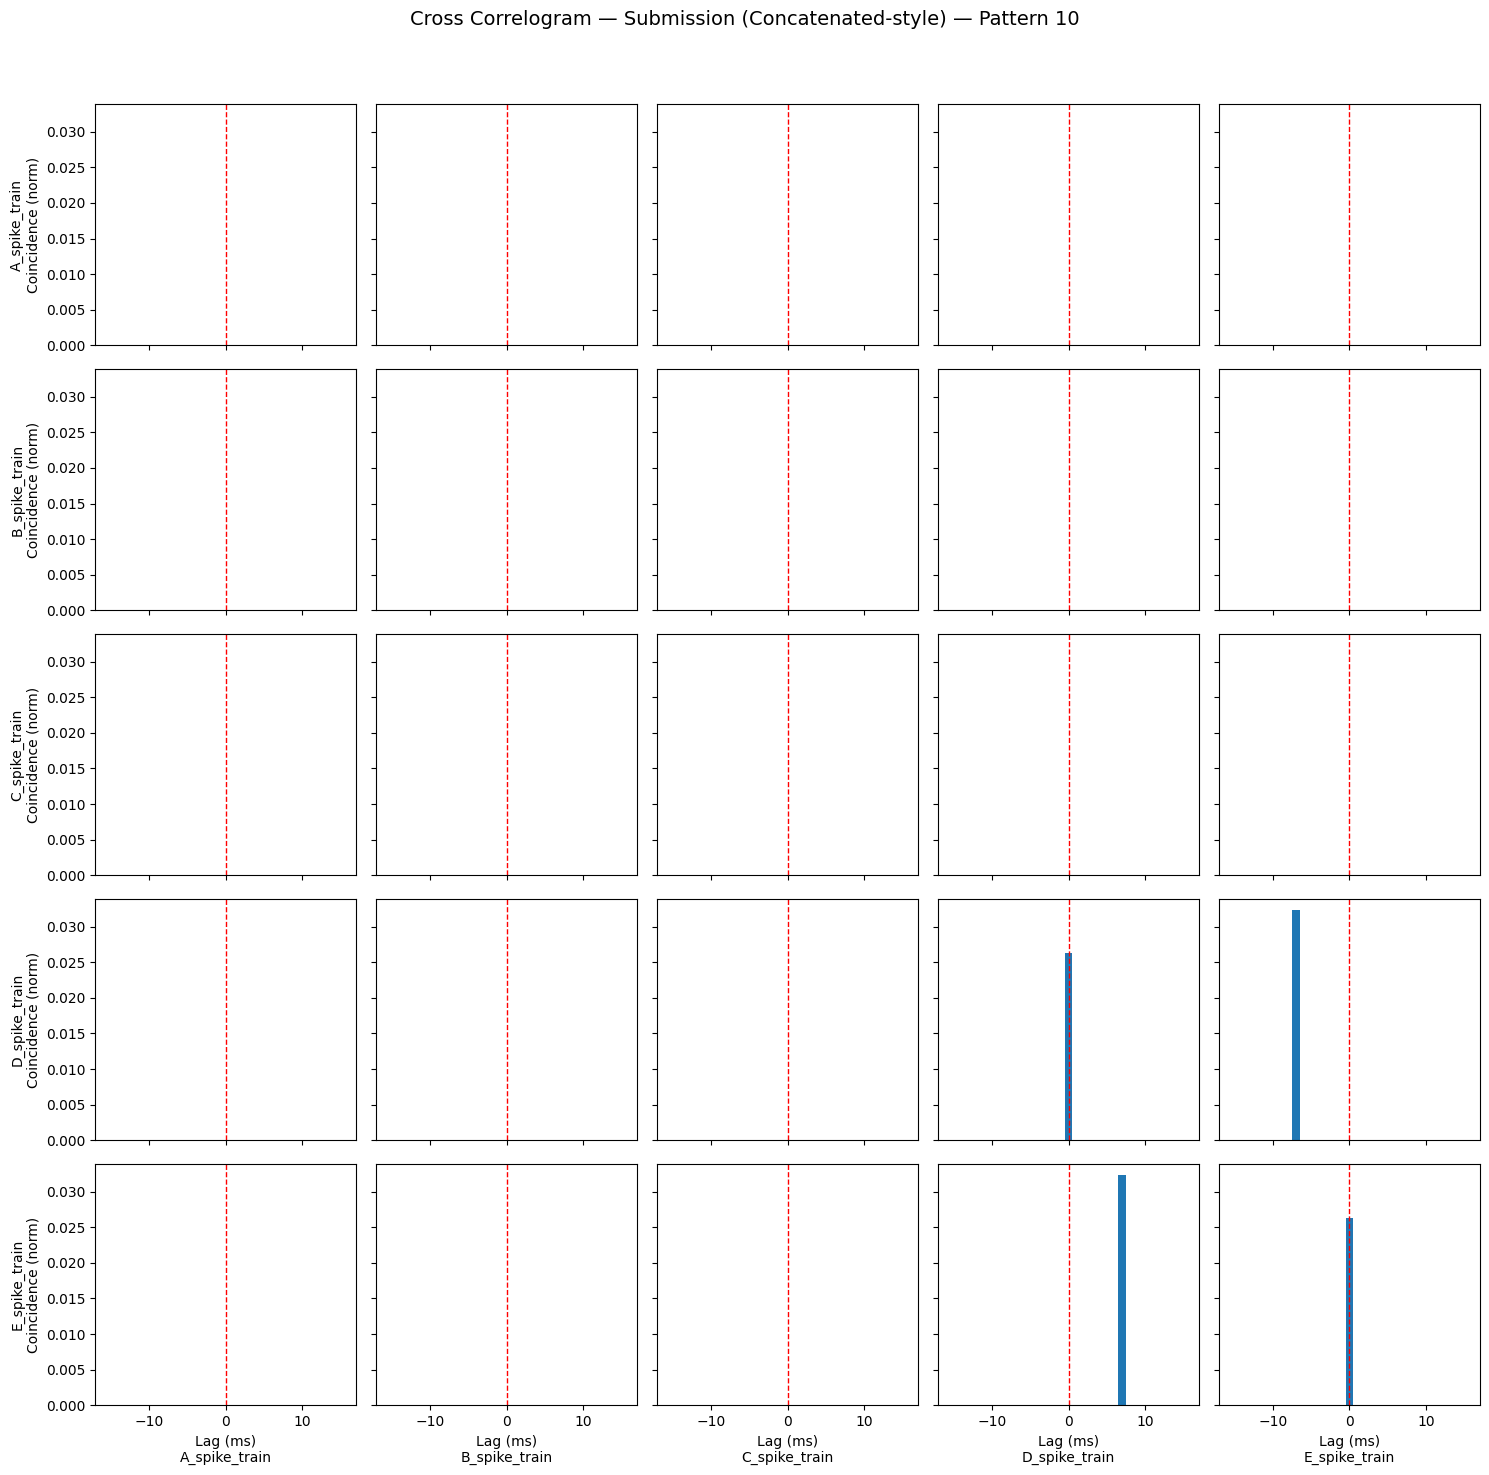

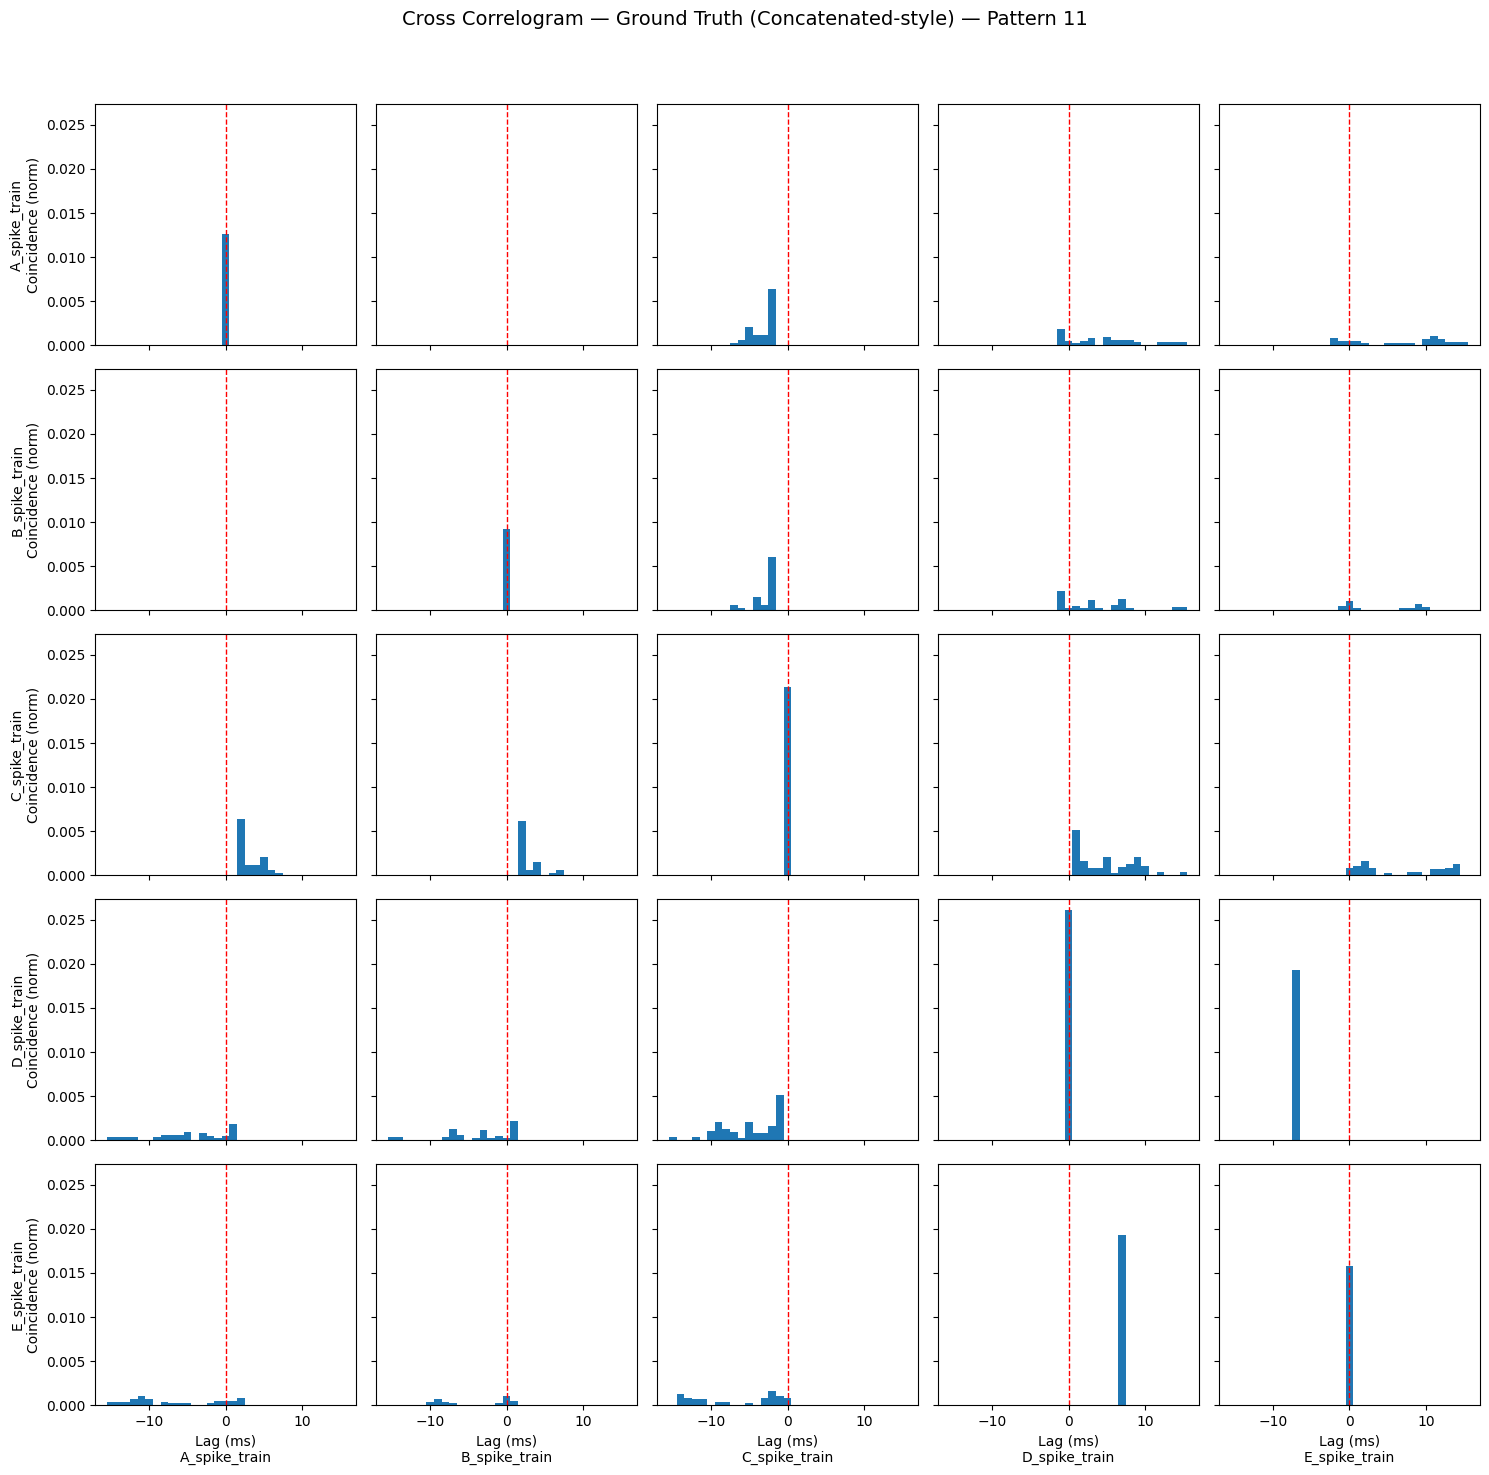

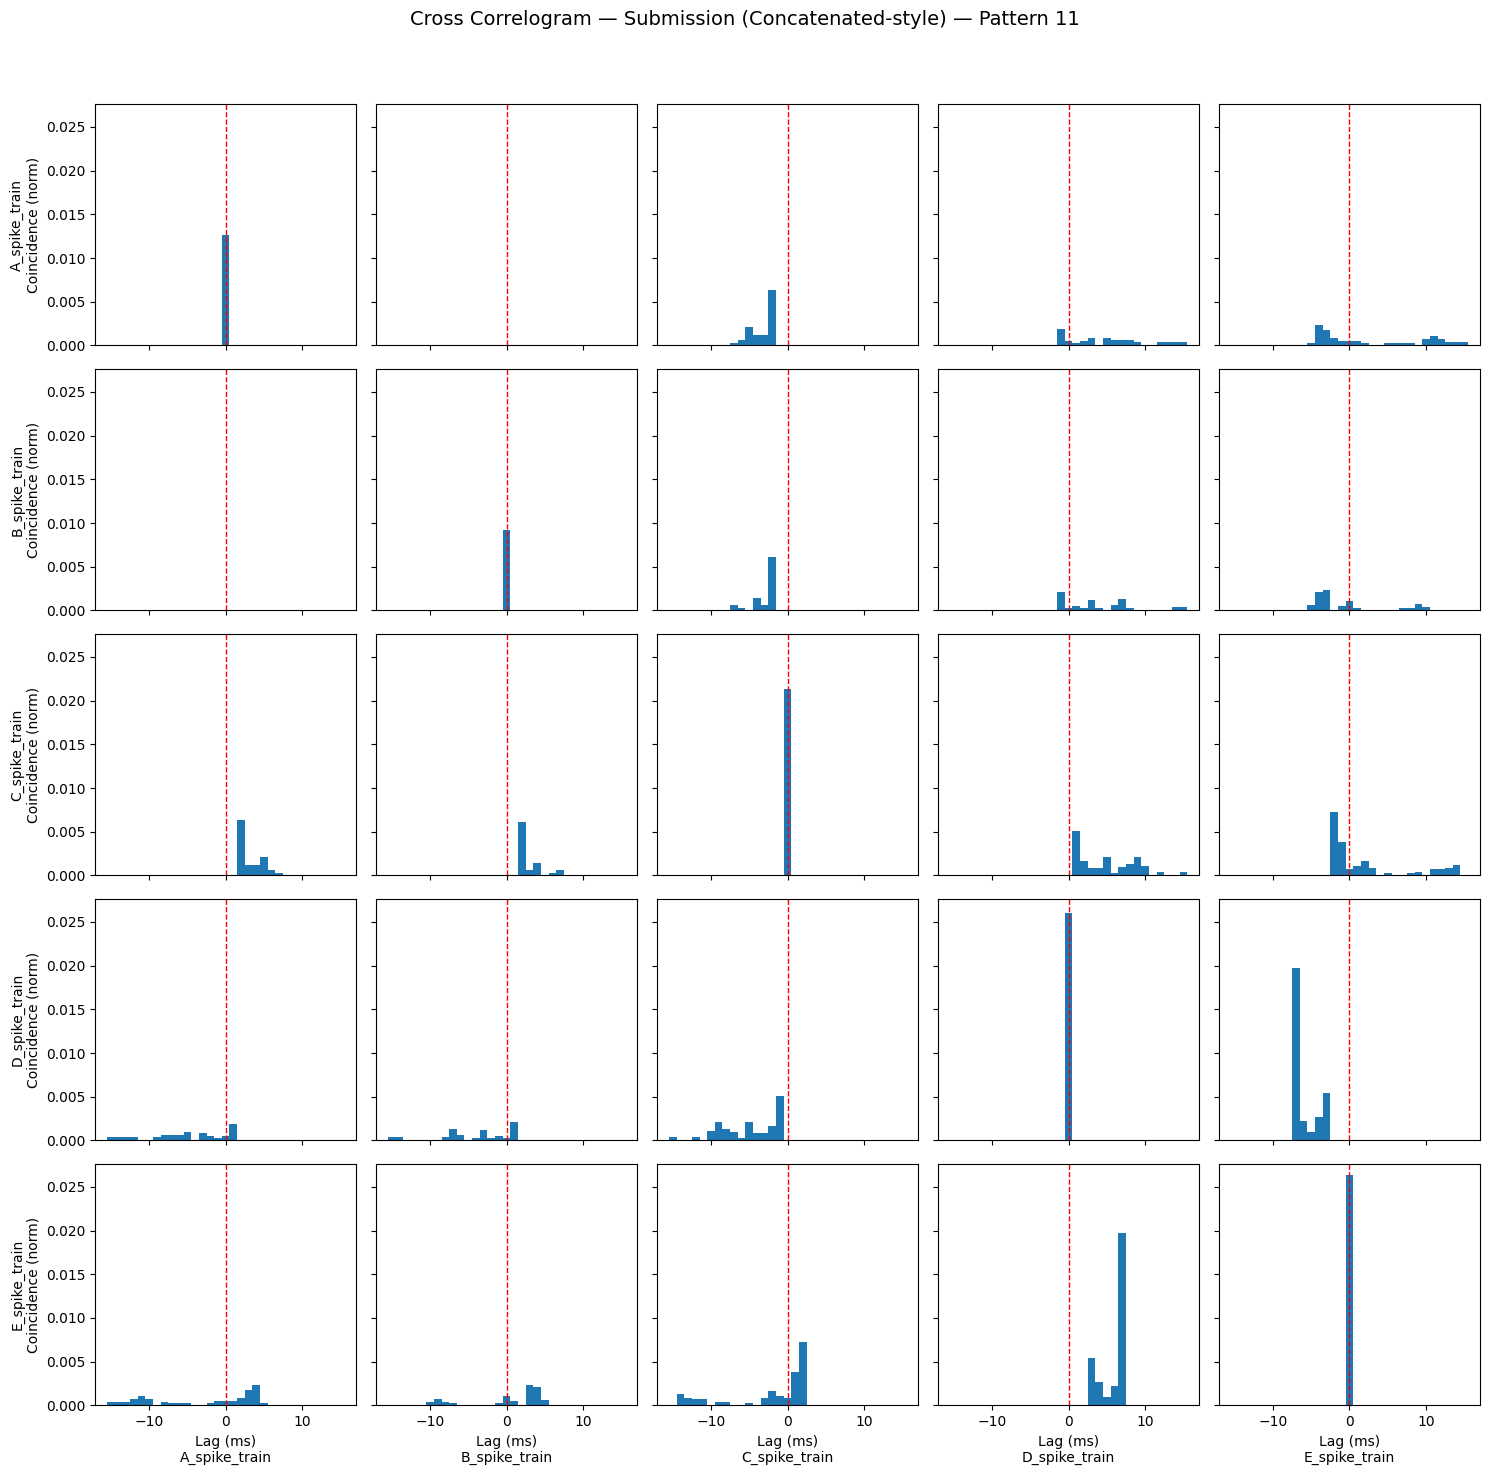

In [10]:
# Cross Correlogram Metric - Binary cross-correlation analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Load preprocessed data
V = METRIC_VARS_NEW
GT_TRIALS = V["gt"]["trials"]
SB_TRIALS = V["sub"]["trials"]
GT_META = V["gt"]["meta"]
SB_META = V["sub"]["meta"]
SPIKE_COLS = list(V["spike_cols"])
PATTERNS = ("00", "01", "10", "11")

RESP_LO_MS = int(V["behavior_params"]["RESP_WINDOW_LO_MS"])
RESP_HI_MS = int(V["behavior_params"]["RESP_WINDOW_HI_MS"])
MAX_LAG_MS = 15  # Maximum lag for micro-scale analysis

def _ids_by_pattern(meta, patt):
    """Get trial indices for pattern."""
    return [i for i, m in enumerate(meta) if m.get("pattern") == patt]

def _common_ids(patt):
    """Get common trial indices between GT and SUB."""
    return sorted(set(_ids_by_pattern(GT_META, patt)).intersection(_ids_by_pattern(SB_META, patt)))

def _resp_window_ms(meta_row):
    """Get response window in ms."""
    rw = meta_row.get("response_window")
    if rw is None:
        return int(RESP_LO_MS), int(RESP_HI_MS)
    lo, hi = int(rw[0]), int(rw[1])
    return max(0, lo), max(lo + 1, hi)

def _resp_window_idx(df, meta_row):
    """Convert response window from ms to sample indices."""
    lo_ms, hi_ms = _resp_window_ms(meta_row)
    n = len(df)
    if n == 0:
        return 0, 0

    if "time" in df.columns:
        t = df["time"].to_numpy(float)
        lo_idx = int(np.searchsorted(t, lo_ms, side="left"))
        hi_idx = int(np.searchsorted(t, hi_ms, side="right"))
    else:
        lo_idx, hi_idx = lo_ms, hi_ms

    lo_idx = max(0, min(lo_idx, n))
    hi_idx = max(lo_idx + 1, min(hi_idx, n))
    return lo_idx, hi_idx

def _seg_bin(df, col, lo_idx, hi_idx):
    """Extract binary segment from column."""
    if (col not in df.columns) or lo_idx >= hi_idx:
        return np.zeros(0, dtype=np.int8)
    arr = df[col].to_numpy(int, copy=False)
    hi_idx = min(hi_idx, len(arr))
    return arr[lo_idx:hi_idx].astype(np.int8, copy=False)

def _xcorr_norm(a, b, max_lag):
    """Normalized binary cross-correlation."""
    if a.size == 0 or b.size == 0:
        lags = np.arange(-max_lag, max_lag + 1, dtype=int)
        return lags, np.zeros(lags.size, dtype=float)

    W = int(min(a.size, b.size))
    if W <= 1:
        lags = np.arange(-max_lag, max_lag + 1, dtype=int)
        return lags, np.zeros_like(lags, dtype=float)

    L = int(min(max_lag, W - 1))
    full = np.correlate(a.astype(float), b.astype(float), mode="full")
    l_full = np.arange(-(W - 1), (W - 1) + 1, dtype=int)
    sel = (l_full >= -L) & (l_full <= L)
    lags = l_full[sel]
    counts = full[sel].astype(float)
    eff = (W - np.abs(lags)).astype(float)
    eff[eff <= 0] = np.nan
    cc = counts / eff
    cc = np.where(np.isfinite(cc), cc, 0.0)
    return lags, cc

def _avg_ccg_trials(trials_i, trials_j, meta, col_i, col_j, max_lag):
    """Average CCG across trials."""
    curves = []
    for df_i, df_j, m in zip(trials_i, trials_j, meta):
        lo, hi = _resp_window_idx(df_i, m)
        ai = _seg_bin(df_i, col_i, lo, hi)
        bj = _seg_bin(df_j, col_j, lo, hi)
        lags, cc = _xcorr_norm(ai, bj, max_lag)
        curves.append(cc)

    if not curves:
        lags = np.arange(-max_lag, max_lag + 1, dtype=int)
        mean_cc = np.zeros_like(lags, dtype=float)
    else:
        mean_cc = np.nanmean(np.vstack(curves), axis=0)
    return lags, mean_cc

def _ccg_matrix_for_pattern(trials_block, meta_block, spike_cols, title, max_lag=MAX_LAG_MS):
    """Create CCG matrix plot for pattern."""
    n = len(spike_cols)
    if n == 0 or not trials_block:
        return None, np.nan

    lags = np.arange(-max_lag, max_lag + 1, dtype=int)
    fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n), sharex=True, sharey=True)
    if n == 1:
        axes = np.array([[axes]])

    zero_vals = []
    for i, ci in enumerate(spike_cols):
        for j, cj in enumerate(spike_cols):
            _, cc = _avg_ccg_trials(trials_block, trials_block, meta_block, ci, cj, max_lag)
            ax = axes[i, j]
            ax.bar(lags, cc, width=1)
            ax.axvline(0, color="red", ls="--", lw=1)
            if i == n - 1:
                ax.set_xlabel(f"Lag (ms)\n{cj}")
            if j == 0:
                ax.set_ylabel(f"{ci}\nCoincidence (norm)")
            if i != j:
                zero_vals.append(cc[max_lag])

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    mean_zero = float(np.nan) if not zero_vals else float(np.nanmean(zero_vals))
    return fig, mean_zero

def _intersect_spike_cols(spike_cols, trials_a, trials_b):
    """Filter spike columns to those present in both datasets."""
    if not trials_a or not trials_b or not spike_cols:
        return []
    cols_a = set(trials_a[0].columns)
    cols_b = set(trials_b[0].columns)
    return [c for c in spike_cols if (c in cols_a and c in cols_b)]

def render_ccg_grids_like_old():
    """Generate CCG matrices and summary statistics."""
    spike_cols = _intersect_spike_cols(SPIKE_COLS, GT_TRIALS, SB_TRIALS)
    rows, figs = [], []

    for patt in PATTERNS:
        ids = _common_ids(patt)
        if not ids:
            continue

        gt_trials_p = [GT_TRIALS[i] for i in ids]
        sb_trials_p = [SB_TRIALS[i] for i in ids]
        gt_meta_p = [GT_META[i] for i in ids]
        sb_meta_p = [SB_META[i] for i in ids] if SB_META else gt_meta_p

        fig_gt, mean0_gt = _ccg_matrix_for_pattern(
            gt_trials_p, gt_meta_p, spike_cols,
            title=f"Cross Correlogram — Ground Truth (Concatenated-style) — Pattern {patt}",
            max_lag=MAX_LAG_MS
        )
        fig_sb, mean0_sb = _ccg_matrix_for_pattern(
            sb_trials_p, sb_meta_p, spike_cols,
            title=f"Cross Correlogram — Submission (Concatenated-style) — Pattern {patt}",
            max_lag=MAX_LAG_MS
        )

        if fig_gt is not None:
            figs.append(fig_gt)
        if fig_sb is not None:
            figs.append(fig_sb)

        rows.append(dict(
            Pattern=patt,
            MeanZeroLag_GT=mean0_gt,
            MeanZeroLag_SUB=mean0_sb,
            Delta_SUB_minus_GT=(mean0_sb - mean0_gt) if (np.isfinite(mean0_gt) and np.isfinite(mean0_sb)) else np.nan
        ))

    return pd.DataFrame(rows, columns=["Pattern", "MeanZeroLag_GT", "MeanZeroLag_SUB", "Delta_SUB_minus_GT"]), figs

# Run and display results
ccg_summary_like_old, ccg_figs_like_old = render_ccg_grids_like_old()

# Print summary table
print("\n=== CCG (old-report style) — Mean zero-lag summary ===")
if not ccg_summary_like_old.empty:
    print(ccg_summary_like_old.to_string(index=False))
else:
    print("(no patterns)")

# Display figures
for f in ccg_figs_like_old:
    display(f)
    plt.close(f)

## Van Rossum

In [11]:
# Van Rossum Distance Metric - Spike train comparison with exponential kernel
import numpy as np
import pandas as pd

# Load preprocessed data
V = METRIC_VARS_NEW
GT_TRIALS = V["gt"]["trials"]
SB_TRIALS = V["sub"]["trials"]
GT_META = V["gt"]["meta"]
SB_META = V["sub"]["meta"]
PATTERNS = ("00", "01", "10", "11")

RESP_LO_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_LO_MS", 0))
RESP_HI_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_HI_MS", 100))
FS_HZ = float(V.get("fs_hz", 1000.0))
MS_PER_SAMPLE = 1000.0 / FS_HZ if FS_HZ > 0 else 1.0

# Infer spike columns
def _candidate_spike_cols(trial_df):
    """Find columns containing spike data."""
    if trial_df is None or trial_df.empty:
        return []
    cols = list(trial_df.columns)
    by_name = [c for c in cols if "spike" in c.lower()]
    if by_name:
        return by_name
    # Fallback: binary columns
    cands = []
    for c in cols:
        if c.lower() == "time":
            continue
        v = trial_df[c].dropna().values
        if v.size == 0:
            continue
        uniq = np.unique(v.astype(int))
        if np.all(np.isin(uniq, [0, 1])):
            cands.append(c)
    return cands

if "spike_cols" in V and V["spike_cols"]:
    SPIKE_COLS = list(V["spike_cols"])
else:
    SPIKE_COLS = _candidate_spike_cols(GT_TRIALS[0]) if GT_TRIALS else []

def _ids_by_pattern(meta, patt):
    """Get trial indices for pattern."""
    return [i for i, m in enumerate(meta) if m.get("pattern") == patt]

def _common_ids(patt):
    """Get common trial indices between GT and SUB."""
    return sorted(set(_ids_by_pattern(GT_META, patt)).intersection(_ids_by_pattern(SB_META, patt)))

def _resp_window(meta_row):
    """Get response window."""
    rw = meta_row.get("response_window")
    if rw is None:
        return RESP_LO_MS, RESP_HI_MS
    lo, hi = int(rw[0]), int(rw[1])
    return max(0, lo), max(lo + 1, hi)

def _spike_times_in_window(df, col, lo_ms, hi_ms):
    """Extract spike times within window."""
    if df is None or df.empty or (col not in df.columns):
        return np.empty(0, dtype=float)

    arr = df[col].to_numpy(dtype=int)
    n = arr.size

    if "time" in df.columns:
        t = df["time"].to_numpy(dtype=float)
        mask = (t >= lo_ms) & (t < hi_ms)
        idx = np.where((arr == 1) & mask)[0]
        return t[idx]
    else:
        lo = int(max(0, np.floor(lo_ms / MS_PER_SAMPLE)))
        hi = int(min(n, np.ceil(hi_ms / MS_PER_SAMPLE)))
        if lo >= hi:
            return np.empty(0, dtype=float)
        seg = arr[lo:hi]
        rel_idx = np.where(seg == 1)[0]
        return (lo + rel_idx).astype(float) * MS_PER_SAMPLE

def _vr_distance(spike_t_x, spike_t_y, tau_ms):
    """Compute Van Rossum distance with exponential kernel."""
    Nx = spike_t_x.size
    Ny = spike_t_y.size

    if Nx == 0 and Ny == 0:
        return 0.0
    if Nx == 0 or Ny == 0:
        return np.sqrt((Nx + Ny) / (2.0 * tau_ms))

    diffs = np.abs(spike_t_x[:, None] - spike_t_y[None, :])
    sxy = np.exp(-diffs / float(tau_ms)).sum()
    d2 = (Nx + Ny - 2.0 * sxy) / (2.0 * float(tau_ms))
    return float(np.sqrt(max(d2, 0.0)))

def run_vr_metric(tau_ms=20.0, min_trials_per_pattern=1):
    """Compute Van Rossum distance per trial and neuron."""
    if not GT_TRIALS or not SB_TRIALS:
        empty_cols = ["pattern", "trial_id", "neuron", "VR", "GT_spikes", "SUB_spikes", "tau_ms", "win_lo_ms", "win_hi_ms"]
        return (pd.DataFrame(columns=empty_cols),
                pd.DataFrame(columns=["pattern", "n_trials", "rows", "VR_mean", "VR_median"]),
                pd.DataFrame(columns=["neuron", "rows", "VR_mean", "VR_median"]))

    if not SPIKE_COLS:
        empty_cols = ["pattern", "trial_id", "neuron", "VR", "GT_spikes", "SUB_spikes", "tau_ms", "win_lo_ms", "win_hi_ms"]
        return (pd.DataFrame(columns=empty_cols),
                pd.DataFrame(columns=["pattern", "n_trials", "rows", "VR_mean", "VR_median"]),
                pd.DataFrame(columns=["neuron", "rows", "VR_mean", "VR_median"]))

    records = []
    for patt in PATTERNS:
        ids = _common_ids(patt)
        if not ids or len(ids) < min_trials_per_pattern:
            continue

        for i in ids:
            gt_df, sb_df = GT_TRIALS[i], SB_TRIALS[i]
            meta = GT_META[i] if i < len(GT_META) else {}
            lo_ms, hi_ms = _resp_window(meta)

            for neuron in SPIKE_COLS:
                tx = _spike_times_in_window(gt_df, neuron, lo_ms, hi_ms)
                ty = _spike_times_in_window(sb_df, neuron, lo_ms, hi_ms)
                vr = _vr_distance(tx, ty, tau_ms=float(tau_ms))
                records.append({
                    "pattern": patt,
                    "trial_id": i,
                    "neuron": neuron,
                    "VR": vr,
                    "GT_spikes": int(tx.size),
                    "SUB_spikes": int(ty.size),
                    "tau_ms": float(tau_ms),
                    "win_lo_ms": int(lo_ms),
                    "win_hi_ms": int(hi_ms),
                })

    trial_level_df = pd.DataFrame.from_records(records)

    if trial_level_df.empty:
        trial_level_df = pd.DataFrame(columns=["pattern", "trial_id", "neuron", "VR", "GT_spikes", "SUB_spikes", "tau_ms", "win_lo_ms", "win_hi_ms"])

    # Compute summaries
    if not trial_level_df.empty:
        pattern_summary = (
            trial_level_df
            .groupby("pattern", as_index=False)
            .agg(n_trials=("trial_id", lambda x: len(np.unique(x))),
                 rows=("VR", "size"),
                 VR_mean=("VR", "mean"),
                 VR_median=("VR", "median"))
            .sort_values("pattern")
            .reset_index(drop=True)
        )

        neuron_summary = (
            trial_level_df
            .groupby("neuron", as_index=False)
            .agg(rows=("VR", "size"),
                 VR_mean=("VR", "mean"),
                 VR_median=("VR", "median"))
            .sort_values("neuron")
            .reset_index(drop=True)
        )
    else:
        pattern_summary = pd.DataFrame(columns=["pattern", "n_trials", "rows", "VR_mean", "VR_median"])
        neuron_summary = pd.DataFrame(columns=["neuron", "rows", "VR_mean", "VR_median"])

    return trial_level_df, pattern_summary, neuron_summary

# Run metric
vr_trials, vr_by_pattern, vr_by_neuron = run_vr_metric(tau_ms=20.0)

# Print summaries
if not vr_by_pattern.empty:
    print("\n=== Van Rossum — Pattern Summary (τ=20 ms) ===")
    print(vr_by_pattern.to_string(index=False))

if not vr_by_neuron.empty:
    print("\n=== Van Rossum — Neuron Summary (τ=20 ms) ===")
    print(vr_by_neuron.to_string(index=False))

# trial-level table if want the worsts:
# vr_trials.sort_values('VR', ascending=False).head(10)


=== Van Rossum — Pattern Summary (τ=20 ms) ===
pattern  n_trials  rows  VR_mean  VR_median
     00       100   500 0.000000        0.0
     01       100   500 0.000000        0.0
     10       100   500 0.000000        0.0
     11       100   500 0.012649        0.0

=== Van Rossum — Neuron Summary (τ=20 ms) ===
       neuron  rows  VR_mean  VR_median
A_spike_train   400 0.000000        0.0
B_spike_train   400 0.000000        0.0
C_spike_train   400 0.000000        0.0
D_spike_train   400 0.000000        0.0
E_spike_train   400 0.015811        0.0


## Multi Scale Corr

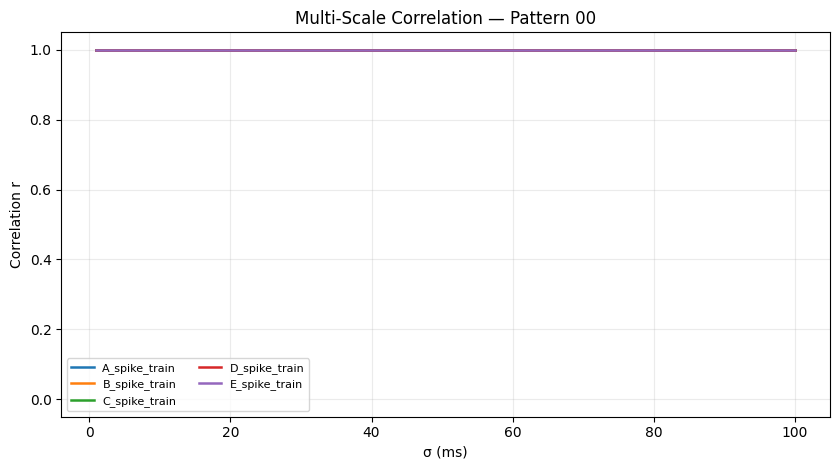

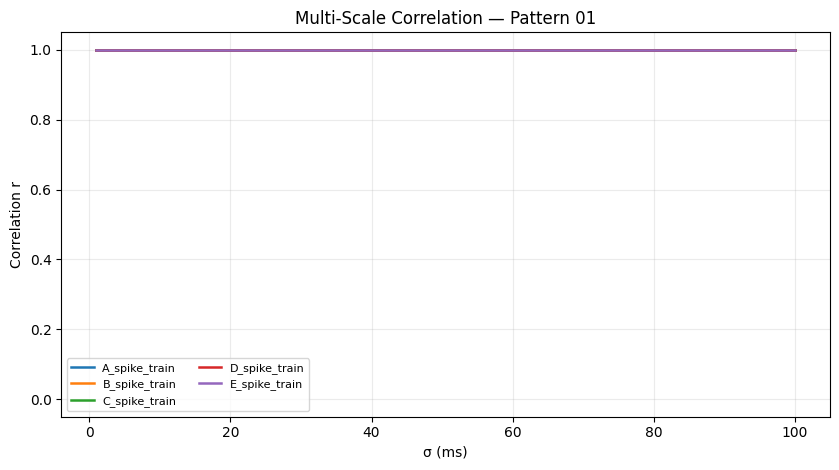

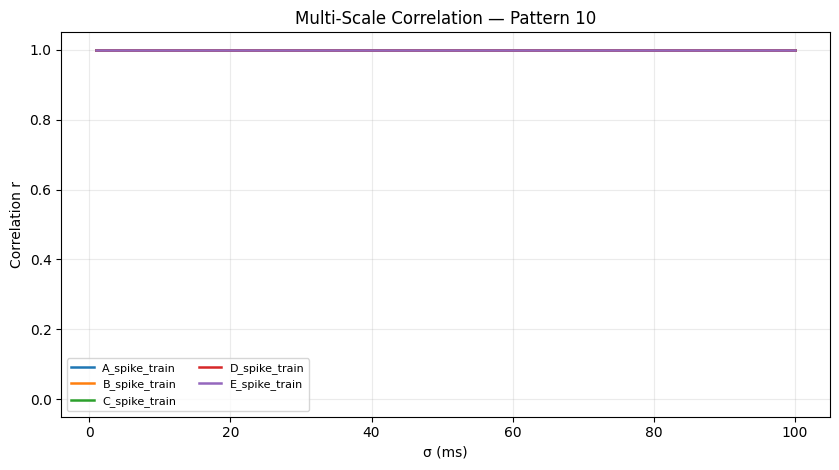

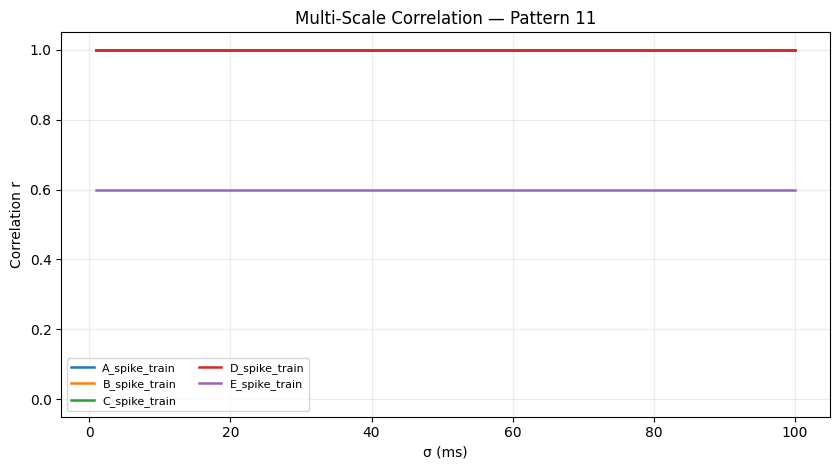


=== Multi-Scale Correlation — Pattern Summary (across trials × neurons × σ) ===
pattern  n_trials  rows  r_mean  r_median  both_silent_pct  one_silent_pct
     00       100 50000    1.00       1.0            100.0             0.0
     01       100 50000    1.00       1.0             60.0             0.0
     10       100 50000    1.00       1.0             60.0             0.0
     11       100 50000    0.92       1.0             27.6             8.0

=== Multi-Scale Correlation — Neuron Summary (pooled across patterns & σ) ===
       neuron  rows  r_mean  r_median  both_silent_pct  one_silent_pct
A_spike_train 40000     1.0       1.0            88.25             0.0
B_spike_train 40000     1.0       1.0            91.25             0.0
C_spike_train 40000     1.0       1.0            79.75             0.0
D_spike_train 40000     1.0       1.0            25.25             0.0
E_spike_train 40000     0.9       1.0            25.00            10.0


In [12]:
# Multi-Scale Correlation Metric - Correlation across time scales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# Load preprocessed data
V = METRIC_VARS_NEW
GT_TRIALS = V["gt"]["trials"]
SB_TRIALS = V["sub"]["trials"]
GT_META = V["gt"]["meta"]
SB_META = V["sub"]["meta"]
PATTERNS = ("00", "01", "10", "11")

RESP_LO_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_LO_MS", 0))
RESP_HI_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_HI_MS", 100))

# Infer sampling rate
def _infer_fs_hz():
    """Infer sampling frequency from data."""
    if "fs_hz" in V and V["fs_hz"]:
        return float(V["fs_hz"])
    if GT_TRIALS and ("time" in GT_TRIALS[0].columns):
        t = GT_TRIALS[0]["time"].to_numpy(float)
        if t.size >= 2:
            dt_ms = float(np.median(np.diff(t)))
            if dt_ms > 0:
                return 1000.0 / dt_ms
    return 1000.0

FS_HZ = _infer_fs_hz()
MS_PER_SAMPLE = 1000.0 / FS_HZ if FS_HZ > 0 else 1.0

# Infer spike columns
def _candidate_spike_cols(trial_df):
    """Find columns containing spike data."""
    if trial_df is None or trial_df.empty:
        return []
    cols = list(trial_df.columns)
    by_name = [c for c in cols if "spike" in c.lower()]
    if by_name:
        return by_name
    cands = []
    for c in cols:
        if c.lower() == "time":
            continue
        v = trial_df[c].dropna().values
        if v.size == 0:
            continue
        uniq = np.unique(v.astype(int))
        if np.all(np.isin(uniq, [0, 1])):
            cands.append(c)
    return cands

if "spike_cols" in V and V["spike_cols"]:
    SPIKE_COLS = list(V["spike_cols"])
else:
    SPIKE_COLS = _candidate_spike_cols(GT_TRIALS[0]) if GT_TRIALS else []

def _ids_by_pattern(meta, patt):
    """Get trial indices for pattern."""
    return [i for i, m in enumerate(meta) if m.get("pattern") == patt]

def _common_ids(patt):
    """Get common trial indices between GT and SUB."""
    return sorted(set(_ids_by_pattern(GT_META, patt)).intersection(_ids_by_pattern(SB_META, patt)))

def _resp_window(meta_row):
    """Get response window."""
    rw = meta_row.get("response_window")
    if rw is None:
        return RESP_LO_MS, RESP_HI_MS
    lo, hi = int(rw[0]), int(rw[1])
    return max(0, lo), max(lo + 1, hi)

def _window_indices(df, lo_ms, hi_ms):
    """Convert window from ms to sample indices."""
    n = len(df)
    if n == 0:
        return 0, 0
    if "time" in df.columns:
        t = df["time"].to_numpy(float)
        lo = int(np.searchsorted(t, lo_ms, side="left"))
        hi = int(np.searchsorted(t, hi_ms, side="left"))
        lo = max(0, min(lo, n))
        hi = max(0, min(hi, n))
        return lo, hi
    lo = int(max(0, math.floor(lo_ms / MS_PER_SAMPLE)))
    hi = int(min(n, math.ceil(hi_ms / MS_PER_SAMPLE)))
    return lo, hi

def _get_bin_window(df, col, lo_idx, hi_idx):
    """Extract binary vector for window."""
    if df is None or df.empty or (col not in df.columns):
        return np.zeros(0, dtype=float)
    arr = df[col].to_numpy(int)
    hi_idx = min(hi_idx, len(arr))
    if lo_idx >= hi_idx:
        return np.zeros(0, dtype=float)
    return arr[lo_idx:hi_idx].astype(float)

def _gauss_kernel_sigma_samp(sig_samp):
    """Create Gaussian kernel."""
    ksz = max(3, int(round(6.0 * sig_samp)))
    if ksz % 2 == 0:
        ksz += 1
    x = np.linspace(-3.0 * sig_samp, 3.0 * sig_samp, ksz)
    g = np.exp(-(x**2) / 2.0)
    g /= g.sum()
    return g

def _pearson_r_safe(a, b):
    """Compute correlation with degenerate case handling."""
    va = float(np.var(a))
    vb = float(np.var(b))
    if va == 0.0 and vb == 0.0:
        return 1.0  # Both constant
    if va == 0.0 or vb == 0.0:
        return 0.0  # One constant
    ca = a - float(np.mean(a))
    cb = b - float(np.mean(b))
    denom = math.sqrt(float(np.sum(ca*ca)) * float(np.sum(cb*cb)))
    if denom == 0.0:
        return 0.0
    return float(np.sum(ca*cb) / denom)

def _msc_curve_for_trial_neuron(gt_df, sb_df, neuron, lo_ms, hi_ms, sigma_vals_ms, dt_ms):
    """Compute correlation curve across scales for single trial/neuron."""
    lo_idx, hi_idx = _window_indices(gt_df, lo_ms, hi_ms)
    a = _get_bin_window(gt_df, neuron, lo_idx, hi_idx)
    b = _get_bin_window(sb_df, neuron, lo_idx, hi_idx)

    # Handle degenerate cases
    sa = int(a.sum())
    sb = int(b.sum())
    if sa == 0 and sb == 0:
        return np.ones_like(sigma_vals_ms, dtype=float), True, False
    if (sa == 0 and sb > 0) or (sa > 0 and sb == 0):
        return np.zeros_like(sigma_vals_ms, dtype=float), False, True

    # Compute correlations at each scale
    r = np.zeros_like(sigma_vals_ms, dtype=float)
    for k, sigma_ms in enumerate(sigma_vals_ms):
        sig_samp = max(1e-6, float(sigma_ms / dt_ms))
        g = _gauss_kernel_sigma_samp(sig_samp)
        ca = np.convolve(a, g, mode="same")
        cb = np.convolve(b, g, mode="same")
        r[k] = _pearson_r_safe(ca, cb)
    return r, False, False

def run_multi_scale_correlation(sigma_ms=(np.arange(1, 101)), per_pattern_plots=True, show=True):
    """Compute multi-scale correlation analysis."""
    if (not GT_TRIALS) or (not SB_TRIALS) or (not SPIKE_COLS):
        print("[msc] Missing trials or spike columns.")
        return (pd.DataFrame(columns=["pattern", "n_trials", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"]),
                pd.DataFrame(columns=["neuron", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"]),
                {})

    sigma_vals_ms = np.asarray(sigma_ms, dtype=float)
    dt_ms = MS_PER_SAMPLE

    # Storage structures
    per_pattern_per_neuron_curves = {p: {n: [] for n in SPIKE_COLS} for p in PATTERNS}
    all_records_neu = {n: [] for n in SPIKE_COLS}
    silent_both = {p: {n: 0 for n in SPIKE_COLS} for p in PATTERNS}
    silent_one = {p: {n: 0 for n in SPIKE_COLS} for p in PATTERNS}
    counts_trials = {p: 0 for p in PATTERNS}
    neuron_tot_trials = {n: 0 for n in SPIKE_COLS}
    neuron_both_silent = {n: 0 for n in SPIKE_COLS}
    neuron_one_silent = {n: 0 for n in SPIKE_COLS}

    # Process each pattern
    for patt in PATTERNS:
        ids = _common_ids(patt)
        if not ids:
            continue
        counts_trials[patt] = len(ids)

        for i in ids:
            gt_df = GT_TRIALS[i]
            sb_df = SB_TRIALS[i]
            meta = GT_META[i] if i < len(GT_META) else {}
            lo_ms, hi_ms = _resp_window(meta)

            for neu in SPIKE_COLS:
                neuron_tot_trials[neu] += 1
                r_vec, is_both_silent, is_one_silent = _msc_curve_for_trial_neuron(
                    gt_df, sb_df, neu, lo_ms, hi_ms, sigma_vals_ms, dt_ms
                )

                per_pattern_per_neuron_curves[patt][neu].append(r_vec)
                all_records_neu[neu].extend(r_vec.tolist())

                if is_both_silent:
                    silent_both[patt][neu] += 1
                    neuron_both_silent[neu] += 1
                if is_one_silent:
                    silent_one[patt][neu] += 1
                    neuron_one_silent[neu] += 1

    # Generate summaries
    rows_patt = []
    for patt in PATTERNS:
        vals = []
        bs = os_ = 0
        tot_trials_for_pattern = counts_trials[patt] * len(SPIKE_COLS) if counts_trials[patt] > 0 else 0
        if counts_trials[patt] > 0:
            for neu in SPIKE_COLS:
                curves = per_pattern_per_neuron_curves[patt][neu]
                if curves:
                    vals.extend(np.concatenate(curves).tolist())
                    bs += silent_both[patt][neu]
                    os_ += silent_one[patt][neu]

        if vals:
            arr = np.asarray(vals, dtype=float)
            rows_patt.append({
                "pattern": patt,
                "n_trials": counts_trials[patt],
                "rows": int(arr.size),
                "r_mean": float(np.mean(arr)),
                "r_median": float(np.median(arr)),
                "both_silent_pct": float(100.0 * (bs / tot_trials_for_pattern)) if tot_trials_for_pattern > 0 else np.nan,
                "one_silent_pct": float(100.0 * (os_ / tot_trials_for_pattern)) if tot_trials_for_pattern > 0 else np.nan
            })
    pattern_summary = pd.DataFrame(rows_patt, columns=["pattern", "n_trials", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"])

    rows_neu = []
    for neu in SPIKE_COLS:
        vals = np.asarray(all_records_neu[neu], dtype=float)
        tot_trials = neuron_tot_trials[neu]
        if vals.size > 0 and tot_trials > 0:
            rows_neu.append({
                "neuron": neu,
                "rows": int(vals.size),
                "r_mean": float(np.mean(vals)),
                "r_median": float(np.median(vals)),
                "both_silent_pct": float(100.0 * neuron_both_silent[neu] / tot_trials),
                "one_silent_pct": float(100.0 * neuron_one_silent[neu] / tot_trials),
            })
    neuron_summary = pd.DataFrame(rows_neu, columns=["neuron", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"])

    # Generate plots
    curves_by_pattern = {}
    for patt in PATTERNS:
        ids = _common_ids(patt)
        if not ids:
            continue

        plt.figure(figsize=(8.5, 4.8))
        for neu in SPIKE_COLS:
            curves = per_pattern_per_neuron_curves[patt][neu]
            if not curves:
                continue
            C = np.vstack(curves)
            mean_curve = np.mean(C, axis=0)
            plt.plot(sigma_vals_ms, mean_curve, lw=1.8, label=neu)
            curves_by_pattern.setdefault(patt, {})[neu] = mean_curve

        plt.title(f"Multi-Scale Correlation — Pattern {patt}")
        plt.xlabel("σ (ms)")
        plt.ylabel("Correlation r")
        plt.ylim(-0.05, 1.05)
        plt.legend(loc="best", ncol=2 if len(SPIKE_COLS) > 4 else 1, fontsize=8)
        plt.grid(alpha=0.25)
        plt.tight_layout()
        if show:
            plt.show()

    # Print summaries
    if not pattern_summary.empty:
        print("\n=== Multi-Scale Correlation — Pattern Summary (across trials × neurons × σ) ===")
        print(pattern_summary.to_string(index=False))
    else:
        print("\n=== Multi-Scale Correlation — Pattern Summary (across trials × neurons × σ) ===")
        print("(no patterns)")

    if not neuron_summary.empty:
        print("\n=== Multi-Scale Correlation — Neuron Summary (pooled across patterns & σ) ===")
        print(neuron_summary.to_string(index=False))
    else:
        print("\n=== Multi-Scale Correlation — Neuron Summary (pooled across patterns & σ) ===")
        print("(no neurons)")

    return pattern_summary, neuron_summary, curves_by_pattern

# Run analysis
msc_pattern_summary, msc_neuron_summary, msc_curves = run_multi_scale_correlation(
    sigma_ms=np.arange(1, 101),
    per_pattern_plots=True,
    show=True
)

## Schreiber Similarity


=== Schreiber Similarity — Pattern Summary (σ=10 ms) ===
pattern  n_trials  rows  r_mean  r_median  masked_pct
     00       100   500     NaN       NaN       100.0
     01       100   500     1.0       1.0        60.0
     10       100   500     1.0       1.0        60.0
     11       100   500     1.0       1.0        35.6

=== Schreiber Similarity — Neuron Summary (pooled across patterns) ===
       neuron  rows  r_mean  r_median  both_silent_pct  one_silent_pct
A_spike_train   400     1.0       1.0            88.25             0.0
B_spike_train   400     1.0       1.0            91.25             0.0
C_spike_train   400     1.0       1.0            79.75             0.0
D_spike_train   400     1.0       1.0            25.25             0.0
E_spike_train   400     1.0       1.0            25.00            10.0


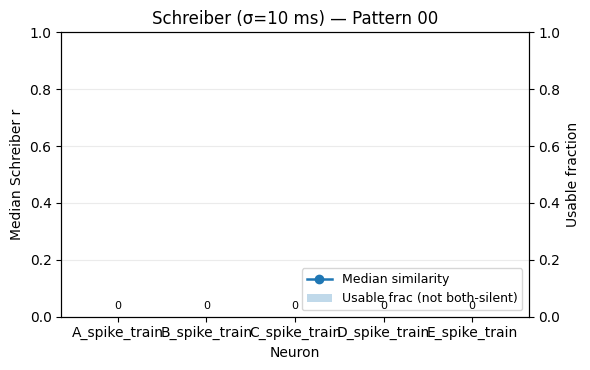

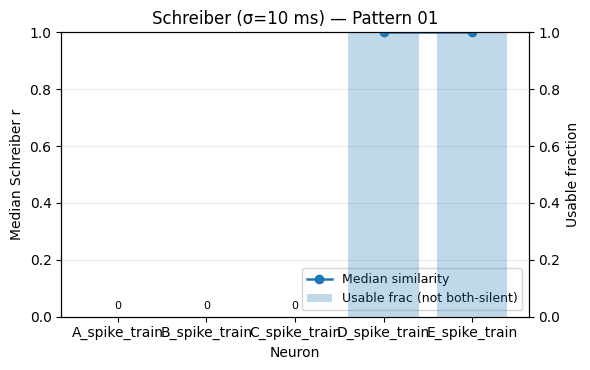

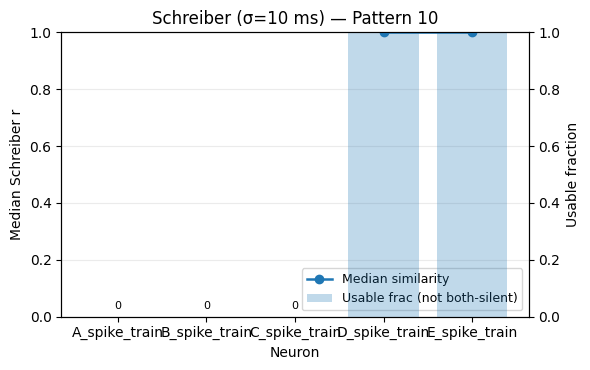

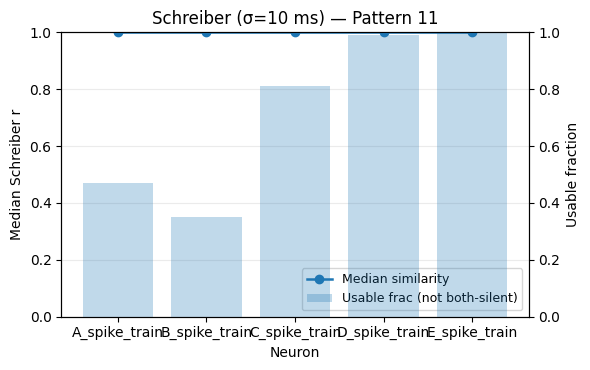

In [13]:
# Schreiber Similarity Metric - Gaussian-smoothed spike trains
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load preprocessed data
V = METRIC_VARS_NEW
GT_TRIALS = V["gt"]["trials"]
SB_TRIALS = V["sub"]["trials"]
GT_META = V["gt"]["meta"]
SB_META = V["sub"]["meta"]
PATTERNS = ("00", "01", "10", "11")

RESP_LO_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_LO_MS", 0))
RESP_HI_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_HI_MS", 100))
FS_HZ = float(V.get("fs_hz", 1000.0))
MS_PER_SAMPLE = 1000.0 / FS_HZ if FS_HZ > 0 else 1.0

# Infer spike columns
def _candidate_spike_cols(trial_df):
    """Find columns containing spike data."""
    if trial_df is None or trial_df.empty:
        return []
    cols = list(trial_df.columns)
    by_name = [c for c in cols if "spike" in c.lower()]
    if by_name:
        return by_name
    cands = []
    for c in cols:
        if c.lower() == "time":
            continue
        v = trial_df[c].dropna().values
        if v.size == 0:
            continue
        uniq = np.unique(v.astype(int))
        if np.all(np.isin(uniq, [0, 1])):
            cands.append(c)
    return cands

if "spike_cols" in V and V["spike_cols"]:
    SPIKE_COLS = list(V["spike_cols"])
else:
    SPIKE_COLS = _candidate_spike_cols(GT_TRIALS[0]) if GT_TRIALS else []

def _ids_by_pattern(meta, patt):
    """Get trial indices for pattern."""
    return [i for i, m in enumerate(meta) if m.get("pattern") == patt]

def _common_ids(patt):
    """Get common trial indices between GT and SUB."""
    return sorted(set(_ids_by_pattern(GT_META, patt)).intersection(_ids_by_pattern(SB_META, patt)))

def _resp_window(meta_row):
    """Get response window."""
    rw = meta_row.get("response_window")
    if rw is None:
        return RESP_LO_MS, RESP_HI_MS
    lo, hi = int(rw[0]), int(rw[1])
    return max(0, lo), max(lo + 1, hi)

def _binary_segment_in_window(df, col, lo_ms, hi_ms):
    """Extract binary spike segment for window."""
    if df is None or df.empty or (col not in df.columns):
        return np.zeros(0, dtype=np.float32)

    x = df[col].to_numpy(dtype=np.float32)
    n = x.size

    if "time" in df.columns:
        t = df["time"].to_numpy(dtype=float)
        mask = (t >= lo_ms) & (t < hi_ms)
        if not np.any(mask):
            return np.zeros(0, dtype=np.float32)
        return x[mask]
    else:
        lo = int(max(0, np.floor(lo_ms / MS_PER_SAMPLE)))
        hi = int(min(n, np.ceil(hi_ms / MS_PER_SAMPLE)))
        if lo >= hi:
            return np.zeros(0, dtype=np.float32)
        return x[lo:hi]

def _gaussian_kernel(sigma_ms, fs_hz):
    """Build Gaussian kernel for smoothing."""
    dt = 1000.0 / float(fs_hz)
    sigma = float(sigma_ms)
    if sigma <= 0:
        return np.array([1.0], dtype=np.float32)
    ksz = max(3, int(round(6.0 * sigma / dt)))
    if ksz % 2 == 0:
        ksz += 1
    half = ksz // 2
    t = (np.arange(ksz) - half) * dt
    g = np.exp(-0.5 * (t / sigma) ** 2).astype(np.float32)
    s = float(g.sum())
    if s > 0:
        g /= s
    return g

def _schreiber_similarity(a_bin, b_bin, kernel):
    """Compute Schreiber similarity between smoothed spike trains."""
    na = int(a_bin.sum() > 0)
    nb = int(b_bin.sum() > 0)
    both_silent = (na == 0 and nb == 0)
    one_silent = ((na == 0) ^ (nb == 0))

    if a_bin.size == 0 or b_bin.size == 0:
        return np.nan, both_silent, one_silent

    ca = np.convolve(a_bin, kernel, mode="same")
    cb = np.convolve(b_bin, kernel, mode="same")
    num = float(np.dot(ca, cb))
    den = float(np.sqrt(np.dot(ca, ca) * np.dot(cb, cb)))
    if den == 0.0:
        return np.nan, both_silent, one_silent
    r = num / den
    r = max(-1.0, min(1.0, r))  # Clamp numerical drift
    return r, both_silent, one_silent

def run_schreiber_metric(sigma_ms=10.0, min_trials_per_pattern=1):
    """Compute Schreiber similarity per trial and neuron."""
    if (not GT_TRIALS) or (not SB_TRIALS) or (not SPIKE_COLS):
        empty_trials = ["pattern", "trial_id", "neuron", "r", "both_silent", "one_silent",
                       "win_lo_ms", "win_hi_ms", "sigma_ms"]
        return (pd.DataFrame(columns=empty_trials),
                pd.DataFrame(columns=["pattern", "n_trials", "rows", "r_mean", "r_median", "masked_pct"]),
                pd.DataFrame(columns=["neuron", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"]))

    kernel = _gaussian_kernel(sigma_ms=float(sigma_ms), fs_hz=FS_HZ)

    rows = []
    for patt in PATTERNS:
        ids = _common_ids(patt)
        if not ids or len(ids) < int(min_trials_per_pattern):
            continue

        for i in ids:
            gt_df = GT_TRIALS[i]
            sb_df = SB_TRIALS[i]
            meta = GT_META[i] if i < len(GT_META) else {}
            lo_ms, hi_ms = _resp_window(meta)

            for neuron in SPIKE_COLS:
                a = _binary_segment_in_window(gt_df, neuron, lo_ms, hi_ms)
                b = _binary_segment_in_window(sb_df, neuron, lo_ms, hi_ms)
                r, both_silent, one_silent = _schreiber_similarity(a, b, kernel)
                rows.append({
                    "pattern": patt,
                    "trial_id": i,
                    "neuron": neuron,
                    "r": float(r) if (r == r) else np.nan,
                    "both_silent": bool(both_silent),
                    "one_silent": bool(one_silent),
                    "win_lo_ms": int(lo_ms),
                    "win_hi_ms": int(hi_ms),
                    "sigma_ms": float(sigma_ms),
                })

    trial_level = pd.DataFrame.from_records(rows)

    # Compute summaries
    if trial_level.empty:
        pattern_summary = pd.DataFrame(columns=["pattern", "n_trials", "rows", "r_mean", "r_median", "masked_pct"])
        neuron_summary = pd.DataFrame(columns=["neuron", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"])
        return trial_level, pattern_summary, neuron_summary

    pattern_summary = (
        trial_level
        .groupby("pattern", as_index=False)
        .agg(
            n_trials=("trial_id", lambda x: len(np.unique(x))),
            rows=("r", "size"),
            r_mean=("r", "mean"),
            r_median=("r", "median"),
            masked_pct=("r", lambda x: float(np.mean(np.isnan(x))) * 100.0)
        )
        .sort_values("pattern")
        .reset_index(drop=True)
    )

    neuron_summary = (
        trial_level
        .groupby("neuron", as_index=False)
        .agg(
            rows=("r", "size"),
            r_mean=("r", "mean"),
            r_median=("r", "median"),
            both_silent_pct=("both_silent", lambda x: float(np.mean(x)) * 100.0),
            one_silent_pct=("one_silent", lambda x: float(np.mean(x)) * 100.0),
        )
        .sort_values("neuron")
        .reset_index(drop=True)
    )

    return trial_level, pattern_summary, neuron_summary

def plot_schreiber_per_pattern_lines_bars(trial_level_df, title_prefix="Schreiber (σ=10 ms) — Pattern"):
    """Plot similarity and usable fraction per pattern."""
    if trial_level_df.empty:
        return []
    figs = []

    for patt in PATTERNS:
        dfp = trial_level_df.loc[trial_level_df["pattern"] == patt]
        if dfp.empty:
            continue

        g = (dfp.groupby("neuron", as_index=False)
                .agg(r_median=("r", "median"),
                     usable_frac=("both_silent", lambda x: 1.0 - float(np.mean(x)) if len(x) else np.nan)))

        neuron_order = [n for n in SPIKE_COLS]
        g = g.set_index("neuron").reindex(neuron_order)
        no_data_mask = g["usable_frac"].isna() & g["r_median"].isna()
        g["usable_frac"] = g["usable_frac"].fillna(0.0)
        g = g.reset_index()
        x = np.arange(len(g))

        fig, ax1 = plt.subplots(figsize=(max(6, 1.5 + 0.7*len(g)), 3.8))
        ax2 = ax1.twinx()

        # Bars for usable fraction
        bars = ax2.bar(g["neuron"], g["usable_frac"].to_numpy(float), alpha=0.28, width=0.8,
                      label="Usable frac (not both-silent)", zorder=1)

        # Mark no-data neurons
        if no_data_mask.any():
            for xi in x[no_data_mask.to_numpy()]:
                ax2.bar(g["neuron"].iloc[xi], 0.02,
                       fill=False, hatch="///", edgecolor="k", linewidth=1.0, alpha=0.9,
                       label="_no_data_outline", zorder=3)

        ax2.set_ylim(0.0, 1.0)
        ax2.set_ylabel("Usable fraction")

        # Line for median similarity
        ax1.plot(g["neuron"], g["r_median"].to_numpy(float), marker="o", linewidth=1.8,
                label="Median similarity", zorder=4)
        ax1.set_ylim(0.0, 1.0)
        ax1.set_ylabel("Median Schreiber r")
        ax1.set_xlabel("Neuron")
        ax1.set_title(f"{title_prefix} {patt}")
        ax1.grid(alpha=0.25, axis="y")
        plt.xticks(rotation=45, ha="right")

        # Annotate zero bars
        for rect, val in zip(bars, g["usable_frac"].to_numpy(float)):
            if val == 0.0:
                ax2.text(rect.get_x() + rect.get_width()/2, 0.02, "0", ha="center", va="bottom", fontsize=8)

        # Combined legend
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        if no_data_mask.any():
            from matplotlib.patches import Patch
            h2.append(Patch(fill=False, hatch="///", edgecolor="k", linewidth=1.0))
            l2.append("No data (all NaN)")
        ax1.legend(h1+h2, l1+l2, loc="lower right", fontsize=9)

        plt.tight_layout()
        figs.append(fig)
    return figs

# Run Schreiber analysis
sch_trials, sch_by_pattern, sch_by_neuron = run_schreiber_metric(sigma_ms=10.0)

if not sch_by_pattern.empty:
    print("\n=== Schreiber Similarity — Pattern Summary (σ=10 ms) ===")
    print(sch_by_pattern.to_string(index=False))
if not sch_by_neuron.empty:
    print("\n=== Schreiber Similarity — Neuron Summary (pooled across patterns) ===")
    print(sch_by_neuron.to_string(index=False))

figs = plot_schreiber_per_pattern_lines_bars(sch_trials, title_prefix="Schreiber (σ=10 ms) — Pattern")
for f in figs:
    plt.show(f)

## Granger causality


=== Granger Causality — Pattern summary (q≤0.05) ===
pattern  edges_GT  edges_SUB  overlap  jaccard
     00         0          0        0      NaN
     01         2          2        2 1.000000
     10         2          2        2 1.000000
     11         8          9        8 0.888889


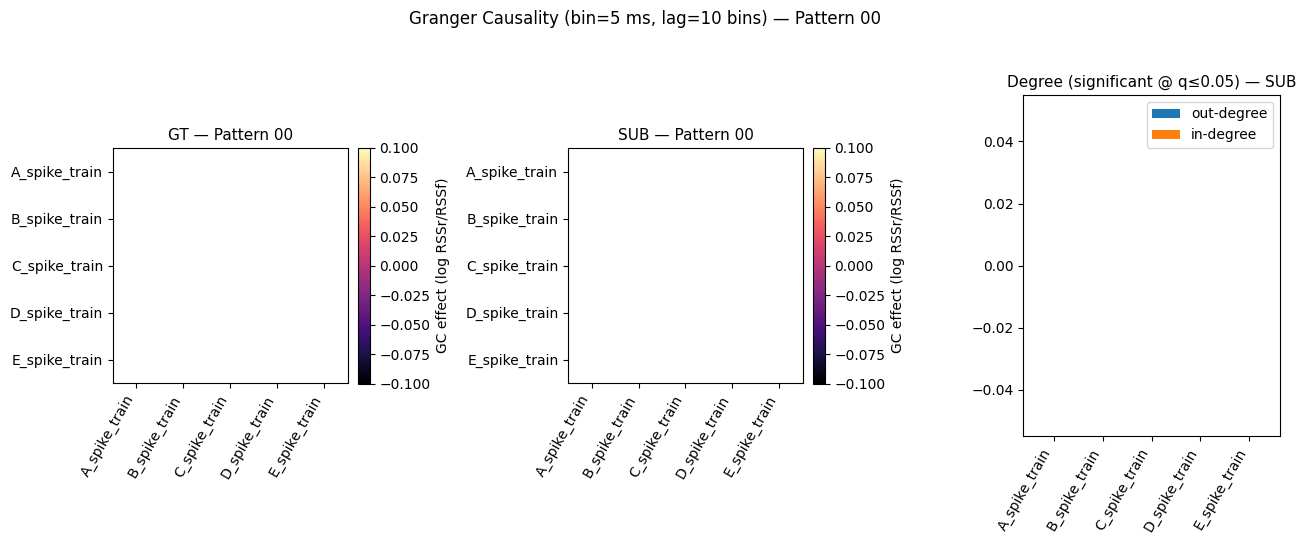

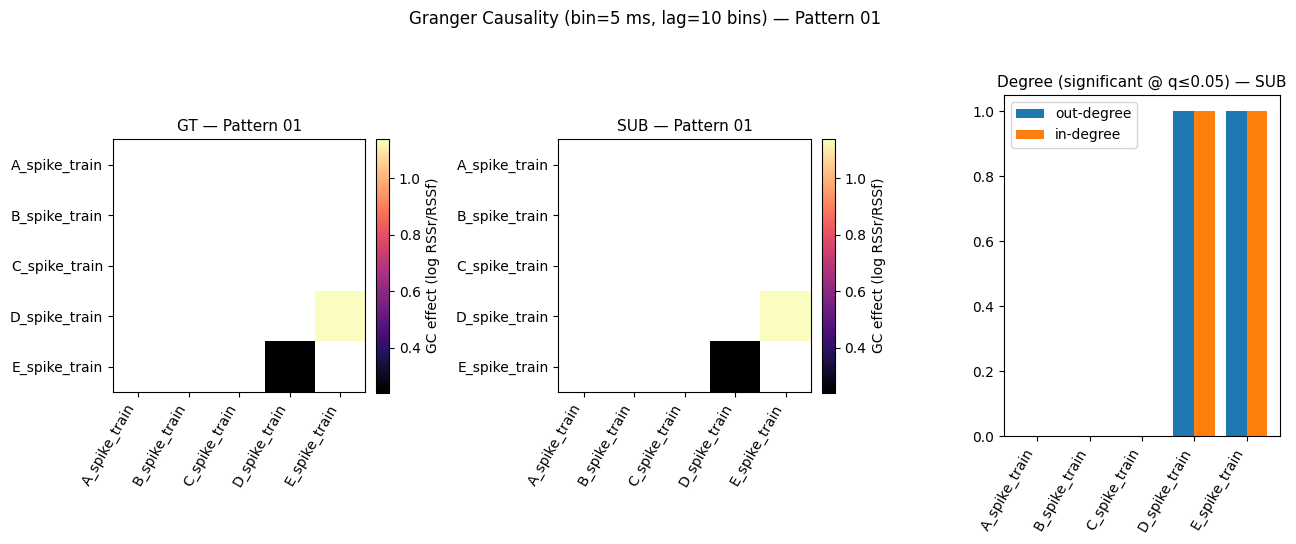

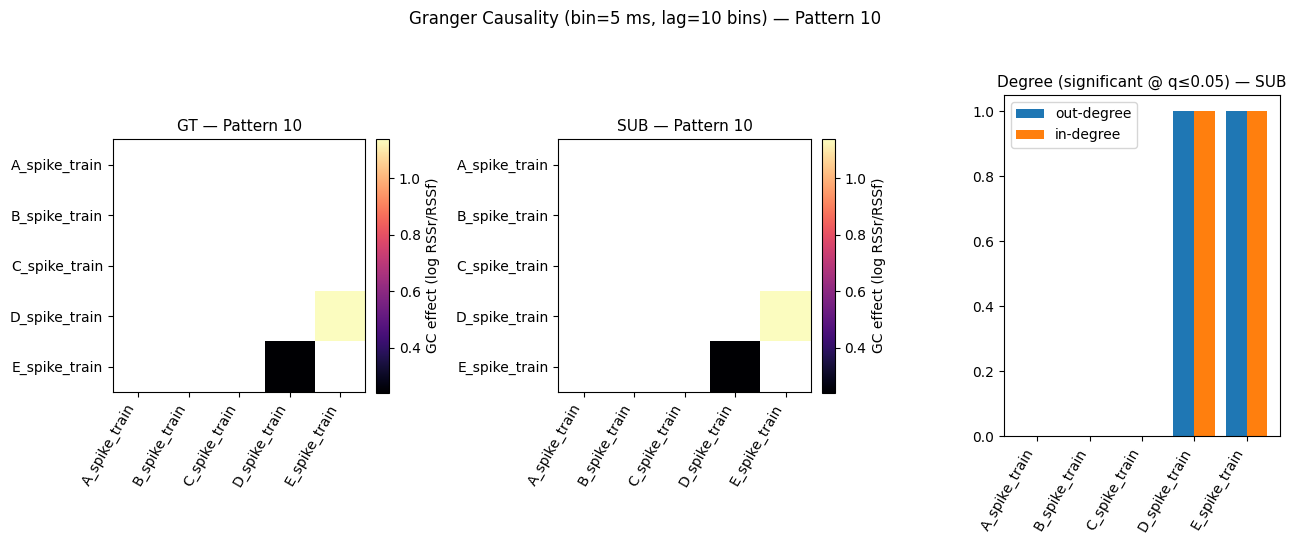

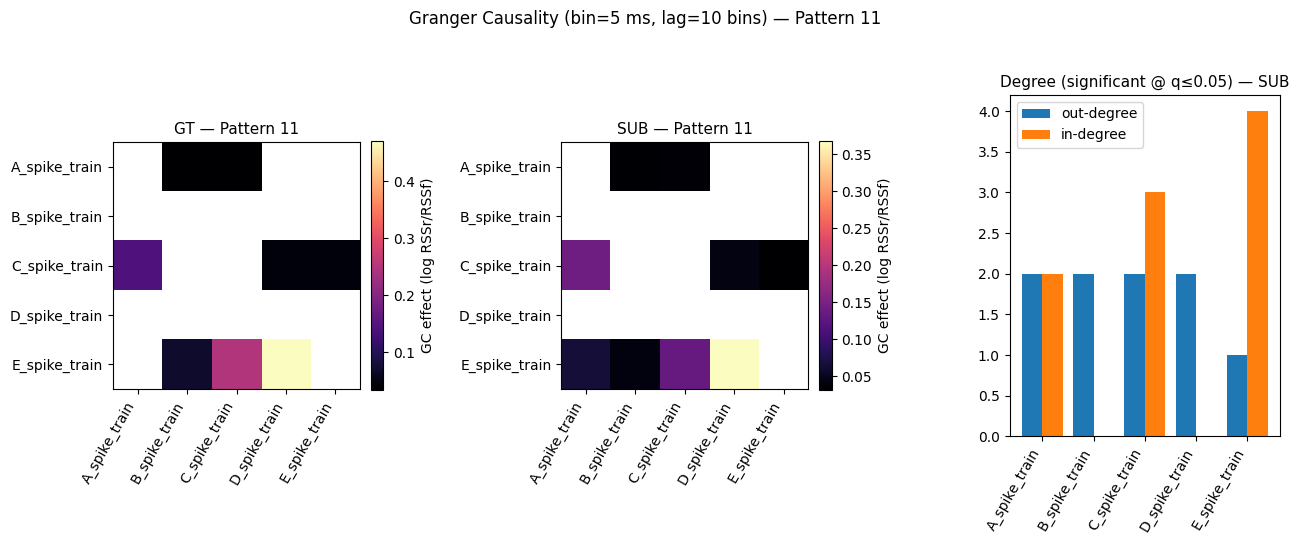

In [14]:
# Granger Causality Metric - Directional connectivity analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load preprocessed data
V = METRIC_VARS_NEW
GT_TRIALS = V["gt"]["trials"]
SB_TRIALS = V["sub"]["trials"]
GT_META = V["gt"]["meta"]
SB_META = V["sub"]["meta"]
PATTERNS = ("00", "01", "10", "11")

RESP_LO_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_LO_MS", 0))
RESP_HI_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_HI_MS", 100))
FS_HZ = float(V.get("fs_hz", 1000.0))
MS_PER_SAMPLE = 1000.0 / FS_HZ if FS_HZ > 0 else 1.0

# Check for SciPy (needed for p-values)
try:
    from scipy.stats import f as _f_dist
    _HAS_SCIPY = True
except:
    _HAS_SCIPY = False

# Infer spike columns
def _candidate_spike_cols(df):
    """Find columns containing spike data."""
    if df is None or df.empty:
        return []
    cols = list(df.columns)
    by_name = [c for c in cols if "spike" in c.lower()]
    if by_name:
        return by_name
    out = []
    for c in cols:
        if c.lower() == "time":
            continue
        v = df[c].dropna().values
        if v.size == 0:
            continue
        u = np.unique(v.astype(int))
        if np.all(np.isin(u, [0, 1])):
            out.append(c)
    return out

SPIKE_COLS = list(V["spike_cols"]) if V.get("spike_cols") else (_candidate_spike_cols(GT_TRIALS[0]) if GT_TRIALS else [])

def _ids_by_pattern(meta, patt):
    """Get trial indices for pattern."""
    return [i for i, m in enumerate(meta) if m.get("pattern") == patt]

def _common_ids(patt):
    """Get common trial indices between GT and SUB."""
    return sorted(set(_ids_by_pattern(GT_META, patt)).intersection(_ids_by_pattern(SB_META, patt)))

def _resp_window(meta_row):
    """Get response window."""
    rw = meta_row.get("response_window")
    if rw is None:
        return RESP_LO_MS, RESP_HI_MS
    lo, hi = int(rw[0]), int(rw[1])
    return max(0, lo), max(lo + 1, hi)

def _slice_window(df, lo_ms, hi_ms):
    """Get row mask for time window."""
    n = len(df)
    if "time" in df.columns:
        t = df["time"].to_numpy(float)
        return (t >= lo_ms) & (t < hi_ms)
    lo = int(max(0, np.floor(lo_ms / MS_PER_SAMPLE)))
    hi = int(min(n, np.ceil(hi_ms / MS_PER_SAMPLE)))
    mask = np.zeros(n, dtype=bool)
    if lo < hi:
        mask[lo:hi] = True
    return mask

def _bin_spikes_block(trials, metas, spike_cols, bin_ms=5):
    """Bin and concatenate spike counts across trials."""
    if not trials or not spike_cols:
        return np.zeros((0, 0)), np.array([])

    pieces = []
    for df, meta in zip(trials, metas):
        lo_ms, hi_ms = _resp_window(meta)
        mask = _slice_window(df, lo_ms, hi_ms)
        if not mask.any():
            continue
        block = df.loc[mask, spike_cols].to_numpy(int)

        # Bin the data
        W = block.shape[0]
        if "time" in df.columns:
            t = df.loc[mask, "time"].to_numpy(float)
            start = t[0]
            end = t[-1]
            edges = np.arange(start, end + 1e-6, bin_ms)
            idx = np.searchsorted(edges, t, side="right") - 1
            B = len(edges) - 1
            binned = np.zeros((B, block.shape[1]), dtype=float)
            for b in range(B):
                sel = (idx == b)
                if sel.any():
                    binned[b] = block[sel].sum(axis=0)
        else:
            step_ms = MS_PER_SAMPLE
            B = int(np.ceil(W * step_ms / bin_ms))
            binned = np.zeros((B, block.shape[1]), dtype=float)
            for b in range(B):
                lo = int(round((b * bin_ms) / step_ms))
                hi = int(round(((b+1) * bin_ms) / step_ms))
                hi = min(hi, W)
                if lo < hi:
                    binned[b] = block[lo:hi].sum(axis=0)
        pieces.append(binned)

    if not pieces:
        return np.zeros((0, len(spike_cols))), np.array([])
    X = np.vstack(pieces)
    edges_ms = np.arange(X.shape[0] + 1) * bin_ms
    return X, edges_ms

def _lag_design(y, X_lags, lag):
    """Build regression design matrices for Granger test."""
    T = y.shape[0]
    if T <= lag:
        return np.zeros(0), np.zeros((0, lag + 1)), np.zeros((0, 2*lag + 1))
    rows = T - lag
    Y = y[lag:]

    def _lags(v):
        return np.column_stack([v[lag - k - 1:T - k - 1] for k in range(lag)])

    Ylags = _lags(y)
    Xlags = _lags(X_lags)
    R = np.column_stack([np.ones(rows), Ylags])
    F = np.column_stack([R, Xlags])
    return Y, R, F

def _ols_rss(design, target):
    """Compute residual sum of squares."""
    if design.shape[0] == 0 or design.shape[1] == 0:
        return np.nan
    beta, *_ = np.linalg.lstsq(design, target, rcond=None)
    resid = target - design @ beta
    return float(np.dot(resid, resid))

def _granger_pair(y, x, lag):
    """Compute Granger causality effect and p-value."""
    Y, R, F = _lag_design(y, x, lag)
    if Y.size == 0:
        return dict(effect=np.nan, p=np.nan)

    rss_r = _ols_rss(R, Y)
    rss_f = _ols_rss(F, Y)
    if not np.isfinite(rss_r) or not np.isfinite(rss_f) or rss_f <= 0:
        return dict(effect=np.nan, p=np.nan)

    effect = np.log(rss_r / rss_f)

    if _HAS_SCIPY:
        df1 = F.shape[1] - R.shape[1]
        df2 = F.shape[0] - F.shape[1]
        if df1 > 0 and df2 > 0:
            Fstat = ((rss_r - rss_f) / df1) / (rss_f / df2)
            p = _f_dist.sf(Fstat, df1, df2)
        else:
            p = np.nan
    else:
        p = np.nan

    return dict(effect=float(effect), p=float(p) if np.isfinite(p) else np.nan)

def _bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction."""
    p = np.asarray(pvals, float)
    m = np.sum(np.isfinite(p))
    if m == 0:
        return np.full_like(p, np.nan)

    order = np.argsort(np.where(np.isfinite(p), p, np.inf))
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(p) + 1)
    q = np.full_like(p, np.nan)
    q_work = np.where(np.isfinite(p), p * m / ranks, np.nan)

    # Enforce monotonicity
    prev = np.inf
    for idx in order[::-1]:
        if np.isfinite(q_work[idx]):
            prev = min(prev, q_work[idx])
            q[idx] = prev
    return q

def _gc_for_dataset(trials, metas, spike_cols, bin_ms=5, lag_bins=10, alpha=0.05, min_bins=50, min_spike_sum=10):
    """Compute Granger causality adjacency matrix."""
    X, _ = _bin_spikes_block(trials, metas, spike_cols, bin_ms=bin_ms)
    N = len(spike_cols)
    if X.shape[0] < max(min_bins, lag_bins + 5):
        return (np.full((N, N), np.nan),) * 3 + (np.zeros((N, N), bool),)

    spike_sums = X.sum(axis=0)
    ok_neuron = spike_sums >= min_spike_sum

    # Z-score normalization
    Xz = X.copy().astype(float)
    for j in range(N):
        if ok_neuron[j]:
            mu = Xz[:, j].mean()
            sd = Xz[:, j].std(ddof=1)
            Xz[:, j] = (Xz[:, j] - mu) / (sd if sd > 0 else 1.0)
        else:
            Xz[:, j] = 0.0

    M_eff = np.full((N, N), np.nan)
    M_p = np.full((N, N), np.nan)

    for j in range(N):  # Target
        y = Xz[:, j]
        if not ok_neuron[j]:
            continue
        for i in range(N):  # Source
            if i == j or not ok_neuron[i]:
                continue
            res = _granger_pair(y, Xz[:, i], lag_bins)
            M_eff[j, i] = res["effect"]
            M_p[j, i] = res["p"]

    # FDR correction
    q = _bh_fdr(M_p.ravel(), alpha=alpha).reshape(M_p.shape)
    usable = np.isfinite(M_eff) & np.isfinite(q) & (q <= alpha)
    return M_eff, M_p, q, usable

def run_granger_per_pattern(bin_ms=5, lag_bins=10, alpha=0.05):
    """Run Granger causality analysis per pattern."""
    if not GT_TRIALS or not SB_TRIALS or not SPIKE_COLS:
        return pd.DataFrame(columns=["pattern", "edges_GT", "edges_SUB", "overlap", "jaccard"]), {}

    figs = {}
    rows = []

    for patt in PATTERNS:
        ids = _common_ids(patt)
        if not ids:
            continue

        gt_tr = [GT_TRIALS[i] for i in ids]
        sb_tr = [SB_TRIALS[i] for i in ids]
        gt_mt = [GT_META[i] for i in ids]
        sb_mt = [SB_META[i] for i in ids]

        eff_gt, p_gt, q_gt, use_gt = _gc_for_dataset(gt_tr, gt_mt, SPIKE_COLS, bin_ms=bin_ms, lag_bins=lag_bins, alpha=alpha)
        eff_sb, p_sb, q_sb, use_sb = _gc_for_dataset(sb_tr, sb_mt, SPIKE_COLS, bin_ms=bin_ms, lag_bins=lag_bins, alpha=alpha)

        # Edge statistics
        A = use_gt
        B = use_sb
        e_gt = int(A.sum() - np.trace(A))
        e_sb = int(B.sum() - np.trace(B))
        inter = int((A & B).sum() - np.trace(A & B))
        union = int((A | B).sum() - np.trace(A | B))
        jacc = (inter / union) if union > 0 else np.nan
        rows.append(dict(pattern=patt, edges_GT=e_gt, edges_SUB=e_sb, overlap=inter, jaccard=jacc))

        # Create figure
        def _plot_heat(ax, M, mask, title):
            im = ax.imshow(np.where(mask, M, np.nan), cmap="magma", aspect="equal")
            ax.set_title(title, fontsize=11)
            ax.set_xticks(np.arange(len(SPIKE_COLS)))
            ax.set_xticklabels(SPIKE_COLS, rotation=60, ha="right")
            ax.set_yticks(np.arange(len(SPIKE_COLS)))
            ax.set_yticklabels(SPIKE_COLS)
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cb.set_label("GC effect (log RSSr/RSSf)")

        def _plot_degree(ax, mask, title):
            outdeg = mask.sum(axis=0)
            indeg = mask.sum(axis=1)
            x = np.arange(len(SPIKE_COLS))
            ax.bar(x - 0.2, outdeg, width=0.4, label="out-degree")
            ax.bar(x + 0.2, indeg, width=0.4, label="in-degree")
            ax.set_xticks(x)
            ax.set_xticklabels(SPIKE_COLS, rotation=60, ha="right")
            ax.set_title(title, fontsize=11)
            ax.legend()

        fig = plt.figure(figsize=(13, 5.5))
        gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])
        ax1 = fig.add_subplot(gs[:, 0])
        ax2 = fig.add_subplot(gs[:, 1])
        ax3 = fig.add_subplot(gs[:, 2])

        _plot_heat(ax1, eff_gt, use_gt, f"GT — Pattern {patt}")
        _plot_heat(ax2, eff_sb, use_sb, f"SUB — Pattern {patt}")
        _plot_degree(ax3, use_sb, f"Degree (significant @ q≤{alpha}) — SUB")

        fig.suptitle(f"Granger Causality (bin={bin_ms} ms, lag={lag_bins} bins) — Pattern {patt}", fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        figs[patt] = fig

    summary = pd.DataFrame(rows, columns=["pattern", "edges_GT", "edges_SUB", "overlap", "jaccard"])
    return summary, figs

# Run Granger analysis
gc_summary, gc_figs = run_granger_per_pattern(bin_ms=5, lag_bins=10, alpha=0.05)

if not gc_summary.empty:
    print("\n=== Granger Causality — Pattern summary (q≤0.05) ===")
    print(gc_summary.to_string(index=False))
else:
    print("\n=== Granger Causality — Pattern summary (q≤0.05) ===\n(no patterns)")

for patt, fig in gc_figs.items():
    plt.show(fig)

## Behavioral Metric

In [15]:
# Behavioral Metric - XOR truth table evaluation
import numpy as np
import pandas as pd

# Load preprocessed data
V = METRIC_VARS_NEW
GT_TRIALS = V["gt"]["trials"]
SB_TRIALS = V["sub"]["trials"]
GT_META = V["gt"]["meta"]
SB_META = V["sub"]["meta"]
RESP_LO_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_LO_MS", 3))
RESP_HI_MS = int(V.get("behavior_params", {}).get("RESP_WINDOW_HI_MS", 40))
TRIAL_LEN = len(GT_TRIALS[0]) if GT_TRIALS else 100

# Output mapping
OUT_MAP = V.get("outputs_map", {"E": "E_spike_train"})
E_COL = OUT_MAP.get("E", "E_spike_train")

PATTERNS = ("00", "01", "10", "11")
XOR_E = {"00": 0, "01": 1, "10": 1, "11": 0}

NAME_BY_PAT = {
    "00": "Pattern 1 (A=0,B=0)",
    "10": "Pattern 2 (A=1,B=0)",
    "01": "Pattern 3 (A=0,B=1)",
    "11": "Pattern 4 (A=1,B=1)",
}

def _safe_window(meta_row, patt):
    """Get scoring window with fallbacks."""
    rw = meta_row.get("response_window")
    if (rw is None) or (rw[1] < rw[0]):
        if patt == "00":
            return 0, min(TRIAL_LEN - 1, RESP_HI_MS)
        return max(0, RESP_LO_MS), min(TRIAL_LEN - 1, RESP_HI_MS)
    lo, hi = int(rw[0]), int(rw[1])
    return max(0, lo), min(TRIAL_LEN - 1, hi)

def _any_spike_in_window(df, col, lo_ms, hi_ms):
    """Check if any spike occurs in window."""
    if (df is None) or (col not in df.columns):
        return False
    x = df[col].to_numpy(dtype=int)
    n = x.size

    if "time" in df.columns:
        t = df["time"].to_numpy(dtype=float)
        mask = (t >= lo_ms) & (t <= hi_ms)
        if not np.any(mask):
            return False
        return bool(np.any((x == 1) & mask))

    lo = int(max(0, lo_ms))
    hi = int(min(n - 1, hi_ms))
    if lo > hi:
        return False
    return bool(np.any(x[lo:hi + 1] == 1))

def _acc_row(tp, fn, tn, fp, name, events):
    """Create accuracy metrics row."""
    den = tp + fn + tn + fp
    return {
        "InputPattern": name,
        "TP": int(tp), "FN": int(fn), "TN": int(tn), "FP": int(fp),
        "Accuracy": (tp + tn) / den if den else 0.0,
        "Sensitivity": tp / (tp + fn) if (tp + fn) else 0.0,
        "Specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "Events": int(events)
    }

def _score_side(TRIALS, META):
    """Score behavioral performance."""
    agg = {p: {"TP": 0, "FN": 0, "TN": 0, "FP": 0, "events": 0} for p in PATTERNS}

    for df, m in zip(TRIALS, META):
        patt = str(m.get("pattern"))
        if patt not in PATTERNS:
            continue
        lo, hi = _safe_window(m, patt)
        want = int(XOR_E[patt])
        have = int(_any_spike_in_window(df, E_COL, lo, hi))

        if want == 1 and have == 1:
            agg[patt]["TP"] += 1
        elif want == 1 and have == 0:
            agg[patt]["FN"] += 1
        elif want == 0 and have == 0:
            agg[patt]["TN"] += 1
        else:
            agg[patt]["FP"] += 1
        agg[patt]["events"] += 1

    # Build results table
    rows = []
    for patt in ("00", "10", "01", "11"):  # Order for Pattern 1-4 labels
        a = agg[patt]
        rows.append(_acc_row(a["TP"], a["FN"], a["TN"], a["FP"], NAME_BY_PAT[patt], a["events"]))

    perf = pd.DataFrame(rows)
    tot = perf[["TP", "FN", "TN", "FP"]].sum()
    den = int(tot.sum())

    perf = pd.concat([perf, pd.DataFrame([{
        "InputPattern": "Total",
        "TP": int(tot.TP), "FN": int(tot.FN), "TN": int(tot.TN), "FP": int(tot.FP),
        "Accuracy": (tot.TP + tot.TN) / den if den else 0.0,
        "Sensitivity": tot.TP / (tot.TP + tot.FN) if (tot.TP + tot.FN) else 0.0,
        "Specificity": tot.TN / (tot.TN + tot.FP) if (tot.TN + tot.FP) else 0.0,
        "Events": int(perf["Events"].sum())
    }])], ignore_index=True)

    return perf

# Print truth table
truth_df = pd.DataFrame(
    [(0, 0, 0),
     (1, 0, 1),
     (0, 1, 1),
     (1, 1, 0)],
    columns=["Input A", "Input B", "Output E"]
)
print(truth_df.to_string(index=False))

# Score and print behavioral metrics
gt_perf = _score_side(GT_TRIALS, GT_META)
sub_perf = _score_side(SB_TRIALS, SB_META)

print(gt_perf.to_string(index=False))
print(sub_perf.to_string(index=False))

 Input A  Input B  Output E
       0        0         0
       1        0         1
       0        1         1
       1        1         0
       InputPattern  TP  FN  TN  FP  Accuracy  Sensitivity  Specificity  Events
Pattern 1 (A=0,B=0)   0   0 100   0      1.00          0.0          1.0     100
Pattern 2 (A=1,B=0) 100   0   0   0      1.00          1.0          0.0     100
Pattern 3 (A=0,B=1) 100   0   0   0      1.00          1.0          0.0     100
Pattern 4 (A=1,B=1)   0   0  40  60      0.40          0.0          0.4     100
              Total 200   0 140  60      0.85          1.0          0.7     400
       InputPattern  TP  FN  TN  FP  Accuracy  Sensitivity  Specificity  Events
Pattern 1 (A=0,B=0)   0   0 100   0      1.00          0.0          1.0     100
Pattern 2 (A=1,B=0) 100   0   0   0      1.00          1.0          0.0     100
Pattern 3 (A=0,B=1) 100   0   0   0      1.00          1.0          0.0     100
Pattern 4 (A=1,B=1)   0   0   0 100      0.00          0.0  